# Preamble

## Setup and Installations

In [ ]:
# Install required packages
!pip install pandas numpy matplotlib seaborn statsmodels --break-system-packages
print("Packages installed successfully")

Packages installed successfully


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')
import re

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from sklearn.neighbors import NearestNeighbors
from scipy import stats

from google.colab import files

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All libraries imported successfully")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


All libraries imported successfully


## Rutgers Color Palette

In [ ]:
# @title
# Primary Rutgers colors
RUTGERS_SCARLET = '#CC0033'
RUTGERS_BLACK = '#000000'
RUTGERS_WHITE = '#FFFFFF'

# Extended palette for visualizations
RUTGERS_PALETTE = {
    'scarlet': '#CC0033',
    'dark_scarlet': '#990027',
    'medium_scarlet': '#E63946',
    'light_scarlet': '#FF6B7A',
    'black': '#000000',
    'dark_grey': '#3D3D3D',
    'medium_grey': '#7D7D7D',
    'light_grey': '#CCCCCC'
}

# Sequential palettes (light to dark) for heatmaps
RUTGERS_SEQUENTIAL = [
    '#FFEBEE',  # Very light
    '#FF6B7A',  # Light scarlet
    '#E63946',  # Medium scarlet
    '#CC0033',  # Scarlet
    '#990027',  # Dark scarlet
    '#660018'   # Very dark scarlet
]

# Diverging palette (for showing contrasts)
RUTGERS_DIVERGING = [
    '#990027',  # Dark scarlet (negative/low)
    '#CC0033',  # Scarlet
    '#E63946',  # Medium scarlet
    '#FFFFFF',  # White (neutral)
    '#CCCCCC',  # Light grey
    '#7D7D7D',  # Medium grey
    '#000000'   # Black (positive/high)
]

# Categorical palette (for different categories/tiers)
RUTGERS_CATEGORICAL = [
    '#CC0033',  # Scarlet
    '#000000',  # Black
    '#E63946',  # Medium scarlet
    '#3D3D3D',  # Dark grey
    '#FF6B7A',  # Light scarlet
    '#7D7D7D',  # Medium grey
]

# ============================================================================
# SET GLOBAL MATPLOTLIB/SEABORN DEFAULTS
# ============================================================================

# Update matplotlib rcParams
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': RUTGERS_BLACK,
    'axes.labelcolor': RUTGERS_BLACK,
    'text.color': RUTGERS_BLACK,
    'xtick.color': RUTGERS_BLACK,
    'ytick.color': RUTGERS_BLACK,
    'grid.color': RUTGERS_PALETTE['light_grey'],
    'axes.prop_cycle': plt.cycler(color=RUTGERS_CATEGORICAL)
})

# Set seaborn palette
sns.set_palette(RUTGERS_CATEGORICAL)

# ============================================================================
# HELPER FUNCTIONS FOR SPECIFIC GRAPH TYPES
# ============================================================================

def get_rutgers_cmap(type='sequential'):
    """
    Get Rutgers-themed colormap for different visualization types

    Parameters:
    -----------
    type : str
        'sequential' - light to dark (for heatmaps, intensity)
        'diverging' - two-sided scale (for showing +/- or contrasts)
        'categorical' - distinct colors (for different groups)
    """
    from matplotlib.colors import LinearSegmentedColormap

    if type == 'sequential':
        return LinearSegmentedColormap.from_list('rutgers_seq', RUTGERS_SEQUENTIAL)
    elif type == 'diverging':
        return LinearSegmentedColormap.from_list('rutgers_div', RUTGERS_DIVERGING)
    elif type == 'categorical':
        return RUTGERS_CATEGORICAL
    else:
        return LinearSegmentedColormap.from_list('rutgers_seq', RUTGERS_SEQUENTIAL)

def rutgers_heatmap_colors(significant=True):
    """
    Colors for Granger causality heatmaps

    Parameters:
    -----------
    significant : bool
        If True, emphasize significant relationships (p < 0.05)
    """
    if significant:
        # Inverted scale: darker = more significant (lower p-value)
        return get_rutgers_cmap('sequential')
    else:
        # Standard scale
        return get_rutgers_cmap('sequential')

def rutgers_network_colors():
    """
    Colors for network/cascade visualizations
    """
    return {
        'significant': RUTGERS_SCARLET,      # p < 0.05
        'marginal': RUTGERS_PALETTE['medium_scarlet'],  # 0.05 <= p < 0.10
        'non_significant': RUTGERS_PALETTE['light_grey'],  # p >= 0.10
        'node': RUTGERS_SCARLET,
        'node_border': RUTGERS_BLACK
    }

def rutgers_sentiment_colors():
    """
    Colors for sentiment analysis visualizations
    """
    return {
        'Positive': RUTGERS_PALETTE['light_scarlet'],
        'Negative': RUTGERS_SCARLET,
        'Well-being': RUTGERS_PALETTE['medium_scarlet'],
        'Risk': RUTGERS_PALETTE['dark_scarlet'],
        'Neutral': RUTGERS_PALETTE['medium_grey']
    }

def rutgers_tier_colors():
    """
    Colors for tier-based visualizations
    """
    return {
        'Tier 1': RUTGERS_SCARLET,
        'Tier 2': RUTGERS_PALETTE['medium_scarlet'],
        'Tier 3': RUTGERS_PALETTE['light_scarlet'],
        'Tier 4': RUTGERS_PALETTE['dark_grey']
    }

def rutgers_amplification_colors():
    """
    Colors for amplification/suppression analysis
    """
    return {
        'amplified': RUTGERS_SCARLET,
        'suppressed': RUTGERS_BLACK,
        'neutral': RUTGERS_PALETTE['medium_grey']
    }

## Download Dataset

Write `dataset_A_news_full_10500.csv` file with full-file download to avoid drive dependencies.

In [ ]:
# @title
!gdown -O "dataset_A_news_full_10500.csv" 1dCrIJ7v9Iz8kkwetRwaYbFVVBLC7j0Mw

Downloading...
From: https://drive.google.com/uc?id=1dCrIJ7v9Iz8kkwetRwaYbFVVBLC7j0Mw
To: /content/dataset_A_news_full_10500.csv
100% 4.98M/4.98M [00:00<00:00, 72.4MB/s]


In [ ]:
# @title
dataset = pd.read_csv('dataset_A_news_full_10500.csv')

print(f"Loaded {len(dataset):,} headlines")
print(f"Columns: {list(dataset.columns)}")

Loaded 10,500 headlines
Columns: ['title', 'link', 'date', 'source', 'number_of_characters_title', 'number_of_words_title', 'day_of_week', 'month', 'year', 'quarter', 'is_weekend', 'classes_str']


# Causal Evidence

Investigating Media Cascade Effects in AI Coverage

### Methodology

1. **Vector Autoregression (VAR)** - Captures multi-directional temporal relationships between media tiers, testing whether sentiment changes in one tier predict changes in others while controlling for all variables simultaneously.

2. **Convergent Cross Mapping (CCM)** - Detects nonlinear causal relationships in dynamical systems, revealing bidirectional coupling strength between media tiers that traditional linear methods may miss.

3. **Granger Causality Tests** - Determines statistical causality and directionality by testing whether past values of elite media significantly improve prediction of public sentiment beyond the public's own history.

### Implementation

**VAR Models**: Lag optimization via AIC/BIC criteria, tested 1-10 day windows  
**Granger Causality**: All 16 tier-pair combinations, multiple lag specifications (1d/2d/5d/7d), significance threshold p<0.05  
**CCM**: Library sizes 10-120 with embedding dimension E=3, time delay τ=1  

**Analyzed Dimensions**: Sentiment (positive/negative/neutral), well-being, risk, creativity, work displacement, human roles, social interaction

## Data Preprocessing

In [ ]:
# Load dataset
df = dataset.copy()
df['date'] = pd.to_datetime(df['date'])

print(f"Loaded {len(df):,} headlines")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Unique sources: {df['source'].nunique():,}")
print(f"Columns: {list(df.columns)}")

Loaded 10,500 headlines
Date range: 2025-06-14 to 2025-09-11
Unique sources: 3,125
Columns: ['title', 'link', 'date', 'source', 'number_of_characters_title', 'number_of_words_title', 'day_of_week', 'month', 'year', 'quarter', 'is_weekend', 'classes_str']


### Filter Academic Sources

Academic journals and databases operate differently from news media and should be excluded from cascade analysis.

In [ ]:
# Define academic source keywords
academic_keywords = [
    'nature', 'science direct', 'sciencedirect', 'frontiers',
    'researchgate', 'arxiv', 'plos', 'springer', 'elsevier',
    'wiley', 'sage', 'taylor & francis', 'ieee', 'acm',
    'pubmed', 'biorxiv', 'medrxiv', 'mdpi', 'hindawi'
]

def is_academic(source):
    """Check if source is academic."""
    source_lower = str(source).lower()
    return any(kw in source_lower for kw in academic_keywords)

# Filter dataset
original_count = len(df)
df = df[~df['source'].apply(is_academic)].copy()
filtered_count = original_count - len(df)

print(f"Academic Source Filtering:")
print(f"  Original headlines: {original_count:,}")
print(f"  Academic sources removed: {filtered_count:,}")
print(f"  Remaining headlines: {len(df):,}")

Academic Source Filtering:
  Original headlines: 10,500
  Academic sources removed: 603
  Remaining headlines: 9,897


### Source Tier Classification

Classify media sources into 4 tiers based on reach and influence:
- **Tier 1**: Elite tech media (TechCrunch, Wired, etc.)
- **Tier 2**: Major news outlets (NYT, WSJ, BBC, etc.)
- **Tier 3**: Industry/trade publications
- **Tier 4**: General/other sources

In [ ]:
# Define tier classification keywords
tier_1_keywords = [
    'techcrunch', 'wired', 'the verge', 'verge',
    'ars technica', 'arstechnica', 'venturebeat',
    'gizmodo', 'engadget', 'recode', 'techmeme'
]

tier_2_keywords = [
    'new york times', 'nytimes', 'ny times', 'nyt',
    'wall street journal', 'wsj',
    'washington post', 'wapo',
    'financial times', 'ft.com',
    'the guardian', 'guardian',
    'the economist', 'economist',
    'bbc', 'cnn', 'reuters', 'bloomberg',
    'forbes', 'fortune', 'businessweek'
]

tier_3_keywords = [
    'yahoo finance', 'marketwatch', 'seeking alpha',
    'business insider', 'insider',
    'healthcare dive', 'retail dive', 'marketing dive',
    'zdnet', 'computerworld', 'cio.com'
]

def classify_source(source):
    """Classify source into tiers 1-4."""
    source_lower = str(source).lower()

    if any(kw in source_lower for kw in tier_1_keywords):
        return 1
    elif any(kw in source_lower for kw in tier_2_keywords):
        return 2
    elif any(kw in source_lower for kw in tier_3_keywords):
        return 3
    else:
        return 4

df['source_tier'] = df['source'].apply(classify_source)

print("Source Tier Distribution:")
for tier in range(1, 5):
    count = (df['source_tier'] == tier).sum()
    pct = count / len(df) * 100
    print(f"  Tier {tier}: {count:5,} headlines ({pct:5.1f}%)")

print("\nSample Sources by Tier:")
for tier in range(1, 5):
    tier_sources = df[df['source_tier'] == tier]['source'].value_counts().head(3)
    print(f"\n  Tier {tier}:")
    for source, count in tier_sources.items():
        source_display = source if len(source) <= 50 else source[:47] + "..."
        print(f"    - {source_display} ({count} headlines)")

Source Tier Distribution:
  Tier 1:   174 headlines (  1.8%)
  Tier 2:   792 headlines (  8.0%)
  Tier 3:   266 headlines (  2.7%)
  Tier 4: 8,665 headlines ( 87.6%)

Sample Sources by Tier:

  Tier 1:
    - TechCrunch (61 headlines)
    - WIRED (35 headlines)
    - The Verge (26 headlines)

  Tier 2:
    - Forbes (190 headlines)
    - Fortune (100 headlines)
    - The Guardian (92 headlines)

  Tier 3:
    - Yahoo Finance (99 headlines)
    - Business Insider (76 headlines)
    - cio.com (31 headlines)

  Tier 4:
    - AFR (68 headlines)
    - The Motley Fool (64 headlines)
    - The Conversation (62 headlines)


### Sentiment Extraction

Extract sentiment indicators from the `classes_str` column using keyword matching.

In [ ]:
# Initialize sentiment columns
df['has_positive_sentiment'] = False
df['has_negative_sentiment'] = False
df['has_wellbeing'] = False
df['has_risk'] = False

# Define sentiment keywords
positive_keywords = ['positive', 'optimism', 'trust', 'confidence', 'innovation', 'breakthrough']
negative_keywords = ['negative', 'fear', 'anxiety', 'disruption', 'bias', 'risk', 'threat', 'danger']
wellbeing_keywords = ['well-being', 'wellbeing', 'emotion', 'motivation', 'mental health']
risk_keywords = ['risk', 'safety', 'health', 'danger', 'harm']

# Extract sentiment indicators
for idx, row in df.iterrows():
    if pd.notna(row['classes_str']):
        classes_lower = row['classes_str'].lower()

        if any(kw in classes_lower for kw in positive_keywords):
            df.at[idx, 'has_positive_sentiment'] = True
        if any(kw in classes_lower for kw in negative_keywords):
            df.at[idx, 'has_negative_sentiment'] = True
        if any(kw in classes_lower for kw in wellbeing_keywords):
            df.at[idx, 'has_wellbeing'] = True
        if any(kw in classes_lower for kw in risk_keywords):
            df.at[idx, 'has_risk'] = True

print("Sentiment Indicators:")
print(f"  Positive: {df['has_positive_sentiment'].sum():5,} ({df['has_positive_sentiment'].sum()/len(df)*100:.1f}%)")
print(f"  Negative: {df['has_negative_sentiment'].sum():5,} ({df['has_negative_sentiment'].sum()/len(df)*100:.1f}%)")
print(f"  Well-being: {df['has_wellbeing'].sum():5,} ({df['has_wellbeing'].sum()/len(df)*100:.1f}%)")
print(f"  Risk: {df['has_risk'].sum():5,} ({df['has_risk'].sum()/len(df)*100:.1f}%)")

Sentiment Indicators:
  Positive: 1,359 (13.7%)
  Negative: 2,134 (21.6%)
  Well-being:   519 (5.2%)
  Risk: 1,097 (11.1%)


### Time Series Aggregation

Aggregate headline data to daily time series for causal analysis.

In [ ]:
# Create daily aggregations
daily_stats = []

for date in sorted(df['date'].unique()):
    day_data = df[df['date'] == date]

    stats = {'date': date, 'total_headlines': len(day_data)}

    # Volume by tier
    for tier in range(1, 5):
        tier_count = len(day_data[day_data['source_tier'] == tier])
        stats[f'tier_{tier}_volume'] = tier_count
        stats[f'tier_{tier}_proportion'] = tier_count / len(day_data) if len(day_data) > 0 else 0

    # Sentiment proportions
    stats['positive_proportion'] = day_data['has_positive_sentiment'].sum() / len(day_data) if len(day_data) > 0 else 0
    stats['negative_proportion'] = day_data['has_negative_sentiment'].sum() / len(day_data) if len(day_data) > 0 else 0
    stats['wellbeing_proportion'] = day_data['has_wellbeing'].sum() / len(day_data) if len(day_data) > 0 else 0
    stats['risk_proportion'] = day_data['has_risk'].sum() / len(day_data) if len(day_data) > 0 else 0
    stats['net_sentiment'] = stats['positive_proportion'] - stats['negative_proportion']

    daily_stats.append(stats)

ts_df = pd.DataFrame(daily_stats).sort_values('date').reset_index(drop=True)

print(f"Time Series Created: {len(ts_df)} days")
print(f"\nSummary Statistics:")
print(ts_df[['total_headlines', 'tier_1_volume', 'tier_4_volume',
             'positive_proportion', 'negative_proportion']].describe().round(3))

Time Series Created: 90 days

Summary Statistics:
       total_headlines  tier_1_volume  tier_4_volume  positive_proportion  \
count           90.000         90.000         90.000               90.000   
mean           109.967          1.933         96.278                0.137   
std             50.954          1.549         46.674                0.044   
min              9.000          0.000          4.000                0.000   
25%             68.000          1.000         58.250                0.110   
50%            116.500          2.000        100.500                0.140   
75%            140.500          3.000        125.000                0.160   
max            254.000          6.000        233.000                0.300   

       negative_proportion  
count               90.000  
mean                 0.212  
std                  0.049  
min                  0.067  
25%                  0.182  
50%                  0.211  
75%                  0.243  
max                  0.3

### Test Stationarity

VAR and Granger causality require stationary time series. Use Augmented Dickey-Fuller (ADF) test.

In [ ]:
def test_stationarity(series, name):
    """Perform ADF test for stationarity."""
    result = adfuller(series.dropna(), autolag='AIC')

    print(f"\n  {name}:")
    print(f"    ADF Statistic: {result[0]:.4f}")
    print(f"    p-value: {result[1]:.4f}")

    if result[1] < 0.05:
        print(f"    Result: Stationary (p < 0.05)")
        return True
    else:
        print(f"    Result: Non-stationary (p >= 0.05)")
        return False

print("Stationarity Testing (Augmented Dickey-Fuller):")
stationarity_results = {}

for var_name, var_col in [
    ('Tier 1 Volume', 'tier_1_volume'),
    ('Tier 4 Volume', 'tier_4_volume'),
    ('Negative Sentiment', 'negative_proportion'),
    ('Net Sentiment', 'net_sentiment')
]:
    if var_col in ts_df.columns:
        stationarity_results[var_col] = test_stationarity(ts_df[var_col], var_name)

Stationarity Testing (Augmented Dickey-Fuller):

  Tier 1 Volume:
    ADF Statistic: -10.8898
    p-value: 0.0000
    Result: Stationary (p < 0.05)

  Tier 4 Volume:
    ADF Statistic: -2.0573
    p-value: 0.2620
    Result: Non-stationary (p >= 0.05)

  Negative Sentiment:
    ADF Statistic: -8.7769
    p-value: 0.0000
    Result: Stationary (p < 0.05)

  Net Sentiment:
    ADF Statistic: -8.3215
    p-value: 0.0000
    Result: Stationary (p < 0.05)


### Handle Non-Stationarity

If Tier 4 volume is non-stationary, apply first differencing.

In [ ]:
# Check if Tier 4 needs differencing
if not stationarity_results.get('tier_4_volume', True):
    print("\nApplying first differencing to Tier 4 volume...")
    ts_df['tier_4_volume_diff'] = ts_df['tier_4_volume'].diff()
    ts_df = ts_df.dropna()  # Remove first row with NaN

    # Verify now stationary
    result = adfuller(ts_df['tier_4_volume_diff'].dropna())
    print(f"Tier 4 (differenced) p-value: {result[1]:.4f}")

    if result[1] < 0.05:
        print("Tier 4 is now stationary")
        tier_4_var = 'tier_4_volume_diff'
    else:
        print("Warning: Tier 4 still non-stationary after differencing")
        tier_4_var = 'tier_4_volume_diff'
else:
    print("\nTier 4 volume is stationary, using original values")
    tier_4_var = 'tier_4_volume'


Applying first differencing to Tier 4 volume...
Tier 4 (differenced) p-value: 0.0008
Tier 4 is now stationary


## Convergent Cross Mapping (CCM)

CCM detects causality in non-linear, coupled dynamical systems.

### CCM Implementation

In [ ]:
class ConvergentCrossMapping:
    """Convergent Cross Mapping for non-linear causal discovery."""

    def __init__(self, embedding_dim=3, tau=1):
        self.embedding_dim = embedding_dim
        self.tau = tau

    def time_delay_embedding(self, x):
        """Create time-delay embedding (shadow manifold)."""
        x = np.array(x)
        N = len(x)
        M = self.embedding_dim
        tau = self.tau

        n_points = N - (M - 1) * tau

        if n_points <= 0:
            raise ValueError("Time series too short for embedding")

        embedded = np.zeros((n_points, M))
        for i in range(M):
            embedded[:, i] = x[i * tau : i * tau + n_points]

        return embedded

    def cross_map(self, x, y, lib_size=None):
        """Perform cross mapping: X cross-maps Y."""
        x = np.array(x)
        y = np.array(y)

        # Embed X
        x_embedded = self.time_delay_embedding(x)

        # Align y
        n_points = len(x_embedded)
        y_aligned = y[(self.embedding_dim - 1) * self.tau :
                     (self.embedding_dim - 1) * self.tau + n_points]

        if lib_size is None or lib_size > n_points:
            lib_size = n_points

        # Sample library
        indices = np.random.choice(n_points, size=lib_size, replace=False)
        library_x = x_embedded[indices]
        library_y = y_aligned[indices]

        # Find nearest neighbors and predict
        k = self.embedding_dim + 1
        nbrs = NearestNeighbors(n_neighbors=min(k, len(library_x)))
        nbrs.fit(library_x)

        y_pred = np.zeros(lib_size)

        for i in range(lib_size):
            distances, neighbor_indices = nbrs.kneighbors([library_x[i]])
            weights = 1.0 / (distances[0] + 1e-8)
            weights = weights / np.sum(weights)
            y_pred[i] = np.sum(weights * library_y[neighbor_indices[0]])

        correlation = np.corrcoef(library_y, y_pred)[0, 1]
        return correlation

    def test_causality(self, x, y, lib_sizes=None, n_iterations=20):
        """Test causality with increasing library sizes."""
        x = np.array(x)
        y = np.array(y)

        max_size = min(len(x), len(y)) - (self.embedding_dim - 1) * self.tau

        if lib_sizes is None:
            lib_sizes = np.linspace(
                max(10, max_size // 10),
                max_size,
                10
            ).astype(int)

        results = []

        for lib_size in lib_sizes:
            correlations = []

            for _ in range(n_iterations):
                try:
                    corr = self.cross_map(x, y, lib_size)
                    if not np.isnan(corr):
                        correlations.append(corr)
                except:
                    pass

            if correlations:
                results.append({
                    'lib_size': lib_size,
                    'mean_correlation': np.mean(correlations),
                    'std_correlation': np.std(correlations),
                    'n_samples': len(correlations)
                })

        return pd.DataFrame(results)

print("CCM class defined")

CCM class defined


### Perform CCM Analysis

In [ ]:
print("Initializing CCM analyzer...")
ccm = ConvergentCrossMapping(embedding_dim=3, tau=1)

all_ccm_results = {}

# Hypothesis 1: Elite Media -> Public Media
print("\nHYPOTHESIS 1: Elite Media -> General Media")
print("="*80)

print("Testing: tier_1_volume xmap tier_4_volume...")
ccm_forward = ccm.test_causality(
    ts_df['tier_1_volume'].values,
    ts_df['tier_4_volume'].values,
    n_iterations=15
)

print("Testing: tier_4_volume xmap tier_1_volume...")
ccm_backward = ccm.test_causality(
    ts_df['tier_4_volume'].values,
    ts_df['tier_1_volume'].values,
    n_iterations=15
)

all_ccm_results['elite_to_public_media'] = {
    'forward': ccm_forward,
    'backward': ccm_backward
}

# Interpret
if len(ccm_forward) > 0 and len(ccm_backward) > 0:
    slope_fwd = ccm_forward.iloc[-1]['mean_correlation'] - ccm_forward.iloc[0]['mean_correlation']
    slope_bwd = ccm_backward.iloc[-1]['mean_correlation'] - ccm_backward.iloc[0]['mean_correlation']

    print(f"\nResults:")
    print(f"  Forward (Tier 1 -> Tier 4) convergence: {slope_fwd:.4f}")
    print(f"  Backward (Tier 4 -> Tier 1) convergence: {slope_bwd:.4f}")

    if slope_fwd > 0.1 and slope_bwd < 0.1:
        print(f"  Result: UNIDIRECTIONAL (Elite Media -> General Media)")
    elif slope_fwd > 0.1 and slope_bwd > 0.1:
        print(f"  Result: BIDIRECTIONAL (feedback loop)")
    else:
        print(f"  Result: No clear causality detected")

# Hypothesis 2: Media Volume -> Negative Sentiment
print("\nHYPOTHESIS 2: Elite Media -> Negative Sentiment")
print("="*80)

print("Testing: tier_1_volume xmap negative_proportion...")
ccm_forward = ccm.test_causality(
    ts_df['tier_1_volume'].values,
    ts_df['negative_proportion'].values,
    n_iterations=15
)

print("Testing: negative_proportion xmap tier_1_volume...")
ccm_backward = ccm.test_causality(
    ts_df['negative_proportion'].values,
    ts_df['tier_1_volume'].values,
    n_iterations=15
)

all_ccm_results['media_to_sentiment'] = {
    'forward': ccm_forward,
    'backward': ccm_backward
}

if len(ccm_forward) > 0 and len(ccm_backward) > 0:
    slope_fwd = ccm_forward.iloc[-1]['mean_correlation'] - ccm_forward.iloc[0]['mean_correlation']
    slope_bwd = ccm_backward.iloc[-1]['mean_correlation'] - ccm_backward.iloc[0]['mean_correlation']

    print(f"\nResults:")
    print(f"  Forward (Media -> Sentiment) convergence: {slope_fwd:.4f}")
    print(f"  Backward (Sentiment -> Media) convergence: {slope_bwd:.4f}")

    if slope_fwd > 0.1 and slope_bwd < 0.1:
        print(f"  Result: UNIDIRECTIONAL (Media -> Sentiment)")
    elif slope_fwd > 0.1 and slope_bwd > 0.1:
        print(f"  Result: BIDIRECTIONAL (feedback loop)")

Initializing CCM analyzer...

HYPOTHESIS 1: Elite Media -> General Media
Testing: tier_1_volume xmap tier_4_volume...
Testing: tier_4_volume xmap tier_1_volume...

Results:
  Forward (Tier 1 -> Tier 4) convergence: -0.0964
  Backward (Tier 4 -> Tier 1) convergence: -0.0000
  Result: No clear causality detected

HYPOTHESIS 2: Elite Media -> Negative Sentiment
Testing: tier_1_volume xmap negative_proportion...
Testing: negative_proportion xmap tier_1_volume...

Results:
  Forward (Media -> Sentiment) convergence: -0.1005
  Backward (Sentiment -> Media) convergence: -0.0000


### Visualize CCM Results

Saved: 04_ccm_results.png


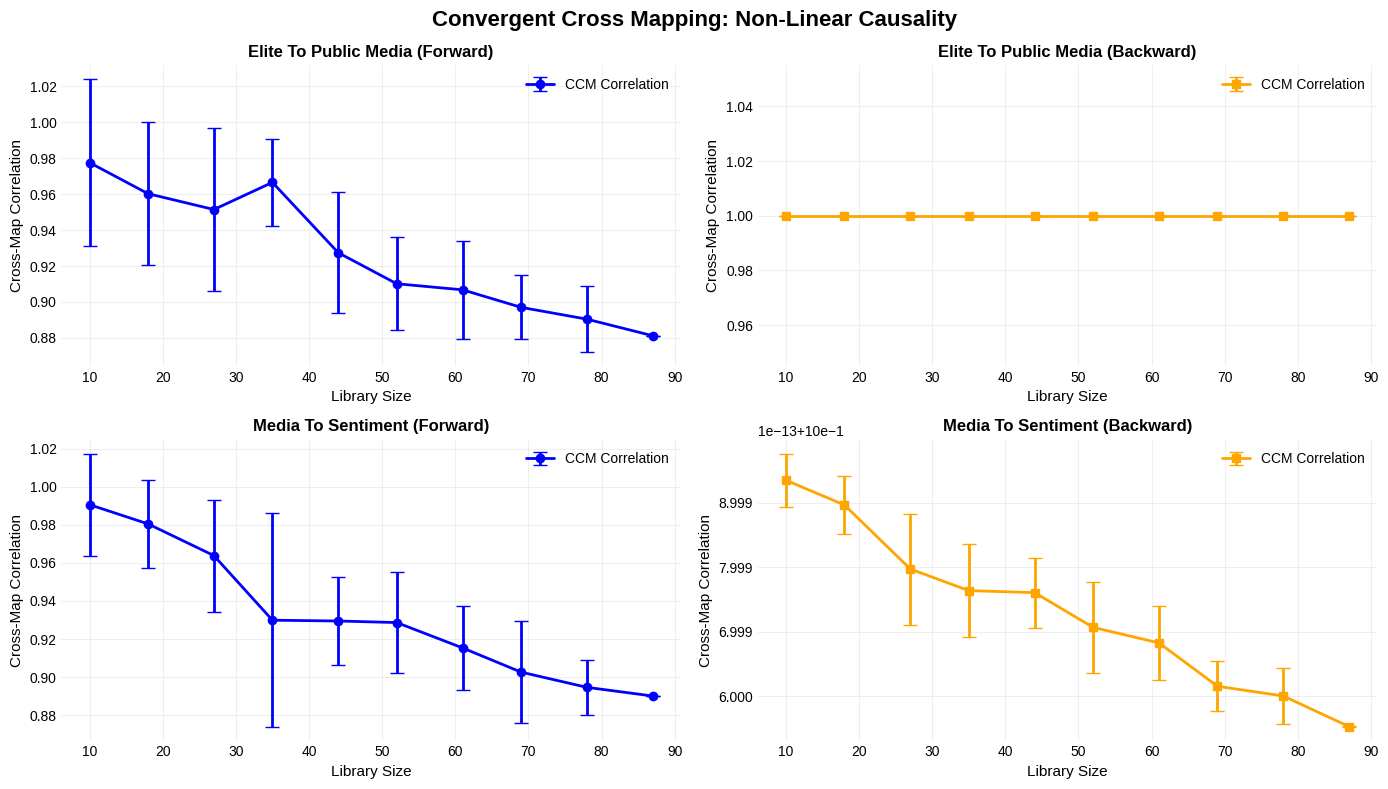


PART 3 COMPLETE


In [ ]:
n_hypotheses = len(all_ccm_results)
fig, axes = plt.subplots(n_hypotheses, 2, figsize=(14, 4 * n_hypotheses))

if n_hypotheses == 1:
    axes = axes.reshape(1, -1)

fig.suptitle('Convergent Cross Mapping: Non-Linear Causality', fontsize=16, fontweight='bold')

for idx, (hypothesis, results) in enumerate(all_ccm_results.items()):
    forward_df = results['forward']
    backward_df = results['backward']

    # Forward direction
    axes[idx, 0].errorbar(forward_df['lib_size'], forward_df['mean_correlation'],
               yerr=forward_df['std_correlation'], marker='o', linewidth=2,
               capsize=5, label='CCM Correlation', color='blue')
    axes[idx, 0].set_xlabel('Library Size', fontsize=11)
    axes[idx, 0].set_ylabel('Cross-Map Correlation', fontsize=11)
    axes[idx, 0].set_title(f'{hypothesis.replace("_", " ").title()} (Forward)', fontweight='bold')
    axes[idx, 0].grid(True, alpha=0.3)
    axes[idx, 0].legend()

    # Backward direction
    axes[idx, 1].errorbar(backward_df['lib_size'], backward_df['mean_correlation'],
               yerr=backward_df['std_correlation'], marker='s', linewidth=2,
               capsize=5, label='CCM Correlation', color='orange')
    axes[idx, 1].set_xlabel('Library Size', fontsize=11)
    axes[idx, 1].set_ylabel('Cross-Map Correlation', fontsize=11)
    axes[idx, 1].set_title(f'{hypothesis.replace("_", " ").title()} (Backward)', fontweight='bold')
    axes[idx, 1].grid(True, alpha=0.3)
    axes[idx, 1].legend()

plt.tight_layout()
plt.savefig('04_ccm_results.png', dpi=300, bbox_inches='tight')
print("Saved: 04_ccm_results.png")
plt.show()

print("\nPART 3 COMPLETE")

## Vector Autoregression (VAR)

VAR models the dynamic relationships between multiple time series variables.

In [ ]:
# Select variables for VAR
var_columns = [
    'tier_1_volume',
    tier_4_var,  # Use differenced version if needed
    'negative_proportion',
    'risk_proportion'
]

# Prepare VAR data
var_data = ts_df[var_columns].fillna(method='ffill').fillna(method='bfill')

if var_data.isnull().any().any():
    print("Warning: Dropping rows with missing values")
    var_data = var_data.dropna()

print(f"VAR variables: {var_columns}")
print(f"Observations: {len(var_data)}")

if len(var_data) >= 20:
    # Build VAR model
    model = VAR(var_data.values)

    # Select optimal lag
    max_lags = min(10, len(var_data) // 3)
    lag_order_results = model.select_order(maxlags=max_lags)
    optimal_lag = lag_order_results.aic

    if optimal_lag == 0:
        optimal_lag = 1
        print(f"Optimal lag was 0, using lag=1 instead")

    print(f"Optimal lag (AIC): {optimal_lag}")

    # Fit VAR model
    fitted_model = model.fit(optimal_lag)

    print(f"\nVAR({optimal_lag}) Model:")
    print(f"  Observations: {fitted_model.nobs}")
    print(f"  Variables: {fitted_model.neqs}")
    print(f"  Total parameters: {fitted_model.df_model}")
else:
    print("ERROR: Not enough data points for VAR analysis")
    fitted_model = None
    optimal_lag = None

VAR variables: ['tier_1_volume', 'tier_4_volume_diff', 'negative_proportion', 'risk_proportion']
Observations: 89
Optimal lag was 0, using lag=1 instead
Optimal lag (AIC): 1

VAR(1) Model:
  Observations: 88
  Variables: 4
  Total parameters: 5


## Granger Causality Tests

Test if past values of X help predict Y better than Y's own past.

In [ ]:
def perform_granger_test(data, cause_col, effect_col, max_lag=7):
    """Perform Granger causality test."""
    test_data = data[[cause_col, effect_col]].dropna()

    if len(test_data) < max_lag + 10:
        max_lag = min(3, len(test_data) // 4)
        print(f"  Reduced max_lag to {max_lag} due to limited data")

    if max_lag < 1:
        print(f"  Insufficient data for Granger test")
        return None

    try:
        gc_results = grangercausalitytests(
            test_data[[effect_col, cause_col]],
            maxlag=max_lag,
            verbose=False
        )
        return gc_results
    except Exception as e:
        print(f"  Error: {e}")
        return None

def interpret_granger(gc_results, cause_name, effect_name):
    """Interpret Granger causality results."""
    if gc_results is None:
        return None

    print(f"\n{'Lag':<5} {'F-stat':<10} {'p-value':<10} {'Significant':<15}")
    print("-" * 50)

    results = []
    for lag in sorted(gc_results.keys()):
        f_test = gc_results[lag][0]['ssr_ftest']
        f_stat = f_test[0]
        p_value = f_test[1]

        sig = ""
        if p_value < 0.01:
            sig = "*** (p<0.01)"
        elif p_value < 0.05:
            sig = "** (p<0.05)"
        elif p_value < 0.10:
            sig = "* (p<0.10)"

        print(f"{lag:<5} {f_stat:<10.4f} {p_value:<10.4f} {sig:<15}")

        results.append({
            'lag': lag,
            'f_stat': f_stat,
            'p_value': p_value,
            'significant': p_value < 0.05
        })

    # Find optimal lag
    sig_results = [r for r in results if r['significant']]
    if sig_results:
        optimal = min(sig_results, key=lambda x: x['p_value'])
        print(f"\nCAUSALITY DETECTED at lag {optimal['lag']} days (p={optimal['p_value']:.4f})")

        if optimal['lag'] == 3:
            print("3-DAY LAG HYPOTHESIS CONFIRMED")
        elif 3 in [r['lag'] for r in sig_results]:
            result_3 = [r for r in sig_results if r['lag'] == 3][0]
            print(f"CAUSALITY ALSO SIGNIFICANT AT 3-DAY LAG (p={result_3['p_value']:.4f})")
    else:
        print("\nNo significant causality at p < 0.05")
        weak_results = [r for r in results if r['p_value'] < 0.10]
        if weak_results:
            optimal = min(weak_results, key=lambda x: x['p_value'])
            print(f"Marginal significance at lag {optimal['lag']} (p={optimal['p_value']:.4f})")

    return pd.DataFrame(results)

In [ ]:
# Test hypotheses
all_granger_results = {}

print("="*80)
print("GRANGER CAUSALITY TESTS")
print("="*80)

# Hypothesis 1: Tier 1 -> Tier 4
print("\nHYPOTHESIS 1: Elite Media -> General Media Volume")
print("="*80)
gc1 = perform_granger_test(ts_df, 'tier_1_volume', tier_4_var, max_lag=7)
results1 = interpret_granger(gc1, 'Tier 1', 'Tier 4')
all_granger_results['tier1_to_tier4'] = results1

# Hypothesis 2: Tier 1 -> Negative sentiment
print("\nHYPOTHESIS 2: Elite Media Volume -> Negative Sentiment")
print("="*80)
gc2 = perform_granger_test(ts_df, 'tier_1_volume', 'negative_proportion', max_lag=7)
results2 = interpret_granger(gc2, 'Tier 1 Volume', 'Negative Sentiment')
all_granger_results['tier1_to_negative'] = results2

# Hypothesis 3: Negative -> Risk
print("\nHYPOTHESIS 3: Negative Sentiment -> Risk Perception")
print("="*80)
gc3 = perform_granger_test(ts_df, 'negative_proportion', 'risk_proportion', max_lag=7)
results3 = interpret_granger(gc3, 'Negative Sentiment', 'Risk Perception')
all_granger_results['negative_to_risk'] = results3

# Hypothesis 4: Total volume -> Negative
print("\nHYPOTHESIS 4: Total Coverage -> Negative Sentiment")
print("="*80)
gc4 = perform_granger_test(ts_df, 'total_headlines', 'negative_proportion', max_lag=7)
results4 = interpret_granger(gc4, 'Total Coverage', 'Negative Sentiment')
all_granger_results['volume_to_negative'] = results4

GRANGER CAUSALITY TESTS

HYPOTHESIS 1: Elite Media -> General Media Volume

Lag   F-stat     p-value    Significant    
--------------------------------------------------
1     8.1817     0.0053     *** (p<0.01)   
2     3.8049     0.0263     ** (p<0.05)    
3     2.1789     0.0971     * (p<0.10)     
4     1.6861     0.1619                    
5     0.9072     0.4812                    
6     0.4493     0.8431                    
7     0.3783     0.9119                    

CAUSALITY DETECTED at lag 1 days (p=0.0053)

HYPOTHESIS 2: Elite Media Volume -> Negative Sentiment

Lag   F-stat     p-value    Significant    
--------------------------------------------------
1     0.3560     0.5523                    
2     0.9395     0.3950                    
3     0.5426     0.6546                    
4     0.4045     0.8049                    
5     0.4597     0.8049                    
6     0.3647     0.8988                    
7     0.3795     0.9112                    

No significant 

## Event-Driven Causal Analysis + Sentiment Shifts

In [ ]:
# Define all major AI events in the dataset timeframe
all_major_events = {
    # JUNE (14-30)
    'UK MHRA AI Airlock': pd.Timestamp('2025-06-23'),
    'Gemini 2.5 GA': pd.Timestamp('2025-06-26'),
    'Claude Opus 3 Retirement Notice': pd.Timestamp('2025-06-30'),
    'Microsoft MAI-DxO': pd.Timestamp('2025-06-30'),

    # JULY
    'Senate AI Moratorium Vote': pd.Timestamp('2025-07-01'),
    'EU AI Act Pause Controversy': pd.Timestamp('2025-07-03'),
    'Grok Hitler Incident': pd.Timestamp('2025-07-06'),
    'Grok 4 Release': pd.Timestamp('2025-07-09'),
    'DoD $200M AI Contracts': pd.Timestamp('2025-07-14'),
    'Intel Layoffs Begin': pd.Timestamp('2025-07-15'),
    'Claude Opus 3 Retirement': pd.Timestamp('2025-07-21'),
    'White House AI Action Plan': pd.Timestamp('2025-07-23'),

    # AUGUST
    'EU AI Act Phase 2': pd.Timestamp('2025-08-02'),
    'Claude Opus 4.1 Release': pd.Timestamp('2025-08-05'),
    'Yahoo Manager Suicide': pd.Timestamp('2025-08-05'),
    'GPT-5 Release': pd.Timestamp('2025-08-07'),
    'GPT-5 Personality Update Notice': pd.Timestamp('2025-08-13'),
    'Claude Sonnet 3.5 Retirement Notice': pd.Timestamp('2025-08-13'),
    'GPT-5 Personality Rollout': pd.Timestamp('2025-08-15'),
    'Claude Code Ransomware': pd.Timestamp('2025-08-28'),
    'Microsoft MAI-Voice-1': pd.Timestamp('2025-08-29'),

    # SEPTEMBER (1-11)
    'China AI Labeling Rules': pd.Timestamp('2025-09-01'),
    'OpenAI Jobs Platform': pd.Timestamp('2025-09-05'),
    'South Korea AI Decree': pd.Timestamp('2025-09-08'),
    'Oracle $455B Cloud Contract': pd.Timestamp('2025-09-11'),
}

# Filter to events actually in dataset
all_major_events = {k: v for k, v in all_major_events.items()
                    if ts_df['date'].min() <= v <= ts_df['date'].max()}

print(f"Testing {len(all_major_events)} major AI events for causal impact")
print(f"Dataset range: {ts_df['date'].min().date()} to {ts_df['date'].max().date()}\n")

Testing 25 major AI events for causal impact
Dataset range: 2025-06-15 to 2025-09-11



In [ ]:
# Extract all sentiment classes from dataset
all_classes = set()
for classes_str in df['classes_str'].dropna():
    classes = [c.strip() for c in str(classes_str).split(';')]
    all_classes.update(classes)

sentiment_cols = sorted(list(all_classes))

# Create binary columns
for sent in sentiment_cols:
    df[f'has_{sent}'] = df['classes_str'].str.contains(sent, na=False, case=False, regex=False)

print(f"Found {len(sentiment_cols)} sentiment dimensions")
print("Sentiment columns found:")
for sent in sentiment_cols:
    total = df[f'has_{sent}'].sum()
    print(f"  {sent}: {total} headlines")

Found 12 sentiment dimensions
Sentiment columns found:
  Cognitive & Decision-Making: 676 headlines
  Creativity, Expression & Identity: 812 headlines
  Emotion, Motivation & Well-being: 519 headlines
  Health, Safety & Risk: 1097 headlines
  Human Roles: 1225 headlines
  Learning, Knowledge & Education: 1757 headlines
  Routine, Lifestyle & Behavior: 1407 headlines
  Sentiment (Positive / Negative Feelings): 1359 headlines
  Social Interaction & Relationships: 697 headlines
  Society, Ethics & Culture: 1536 headlines
  Technology & Interaction: 1629 headlines
  Work, Jobs & Economy: 2426 headlines


In [ ]:
# Create daily time series by tier + overall
if 'tier' not in df.columns:
    def classify_tier(source):
        source_lower = str(source).lower()
        tier_1 = ['techcrunch', 'wired', 'the verge', 'ars technica', 'venturebeat']
        tier_2 = ['new york times', 'wall street journal', 'washington post', 'bbc',
                  'cnn', 'reuters', 'bloomberg', 'forbes', 'fortune', 'the guardian']
        tier_3 = ['yahoo finance', 'business insider', 'marketwatch', 'cnbc',
                  'the information', 'cio.com', 'zdnet']

        if any(t in source_lower for t in tier_1):
            return 1
        elif any(t in source_lower for t in tier_2):
            return 2
        elif any(t in source_lower for t in tier_3):
            return 3
        else:
            return 4

    df['tier'] = df['source'].apply(classify_tier)
    print("✓ Created tier column")

tier_sent_ts = {}
for tier in range(1, 5):
    tier_data = df[df['tier'] == tier].groupby('date').agg({
        **{f'has_{s}': 'mean' for s in sentiment_cols}
    }).reset_index()
    tier_sent_ts[tier] = tier_data

overall_ts = df.groupby('date').agg({
    **{f'has_{s}': 'mean' for s in sentiment_cols}
}).reset_index()

print("✓ Time series created for all tiers + overall")

✓ Created tier column
✓ Time series created for all tiers + overall


In [ ]:
# Event-driven causal analysis: All tiers → Human sentiment
from statsmodels.tsa.stattools import grangercausalitytests
import warnings
warnings.filterwarnings('ignore')

event_causal_results = []

for event_name, event_date in sorted(all_major_events.items(), key=lambda x: x[1]):
    window_start = event_date - pd.Timedelta(days=7)
    window_end = event_date + pd.Timedelta(days=7)

    result = {'event': event_name, 'date': event_date}

    for sent in sentiment_cols:
        # Test each tier → overall sentiment
        for tier in range(1, 5):
            tier_window = tier_sent_ts[tier][
                (tier_sent_ts[tier]['date'] >= window_start) &
                (tier_sent_ts[tier]['date'] <= window_end)
            ]

            overall_window = overall_ts[
                (overall_ts['date'] >= window_start) &
                (overall_ts['date'] <= window_end)
            ]

            merged = pd.merge(
                tier_window[['date', f'has_{sent}']],
                overall_window[['date', f'has_{sent}']],
                on='date', suffixes=('_tier', '_overall')
            )

            if len(merged) < 8:
                continue

            try:
                test_data = merged[[f'has_{sent}_overall', f'has_{sent}_tier']].dropna()
                if len(test_data) >= 8:
                    gc = grangercausalitytests(test_data, maxlag=2, verbose=False)
                    p_val = min([gc[i][0]['ssr_ftest'][1] for i in range(1, 3)])

                    result[f'tier{tier}_{sent}_causal'] = p_val < 0.10
                    result[f'tier{tier}_{sent}_pval'] = p_val

                    pre = merged[merged['date'] < event_date]
                    post = merged[merged['date'] >= event_date]
                    result[f'tier{tier}_{sent}_change'] = (
                        post[f'has_{sent}_overall'].mean() - pre[f'has_{sent}_overall'].mean()
                    )
            except:
                pass

    event_causal_results.append(result)

event_causal_df = pd.DataFrame(event_causal_results)
print(f"✓ Analyzed {len(event_causal_df)} events across {len(sentiment_cols)} sentiments")

✓ Analyzed 25 events across 12 sentiments


In [ ]:
# Summary statistics
print("\n" + "="*80)
print("CAUSAL ANALYSIS SUMMARY")
print("="*80)

total_tests = 0
causal_tests = 0

for sent in sentiment_cols:
    sent_causal = 0
    sent_total = 0

    for tier in range(1, 5):
        col = f'tier{tier}_{sent}_causal'
        if col in event_causal_df.columns:
            sent_total += event_causal_df[col].notna().sum()
            sent_causal += event_causal_df[col].sum()

    if sent_total > 0:
        pct = (sent_causal / sent_total * 100)
        print(f"{sent}: {sent_causal}/{sent_total} causal ({pct:.1f}%)")
        total_tests += sent_total
        causal_tests += sent_causal

print(f"\nOVERALL: {causal_tests}/{total_tests} tests show causality ({causal_tests/total_tests*100:.1f}%)")


CAUSAL ANALYSIS SUMMARY
Cognitive & Decision-Making: 17/97 causal (17.5%)
Creativity, Expression & Identity: 11/87 causal (12.6%)
Emotion, Motivation & Well-being: 8/77 causal (10.4%)
Health, Safety & Risk: 15/88 causal (17.0%)
Human Roles: 14/99 causal (14.1%)
Learning, Knowledge & Education: 13/93 causal (14.0%)
Routine, Lifestyle & Behavior: 21/99 causal (21.2%)
Sentiment (Positive / Negative Feelings): 14/98 causal (14.3%)
Social Interaction & Relationships: 20/92 causal (21.7%)
Society, Ethics & Culture: 6/98 causal (6.1%)
Technology & Interaction: 12/98 causal (12.2%)
Work, Jobs & Economy: 27/98 causal (27.6%)

OVERALL: 178/1124 tests show causality (15.8%)


In [ ]:
# Tier-specific causality rates
print("\n" + "="*80)
print("TIER-SPECIFIC CAUSALITY")
print("="*80)

for tier in range(1, 5):
    tier_causal = 0
    tier_total = 0

    for sent in sentiment_cols:
        col = f'tier{tier}_{sent}_causal'
        if col in event_causal_df.columns:
            tier_total += event_causal_df[col].notna().sum()
            tier_causal += event_causal_df[col].sum()

    if tier_total > 0:
        print(f"Tier {tier}: {tier_causal}/{tier_total} causal ({tier_causal/tier_total*100:.1f}%)")


TIER-SPECIFIC CAUSALITY
Tier 1: 16/243 causal (6.6%)
Tier 2: 55/300 causal (18.3%)
Tier 3: 54/281 causal (19.2%)
Tier 4: 53/300 causal (17.7%)


In [ ]:
# Asymmetry analysis: Positive vs Risk sentiments
print("\n" + "="*80)
print("SENTIMENT ASYMMETRY")
print("="*80)

positive_sent = 'Sentiment (Positive / Negative Feelings)'
risk_sent = 'Health, Safety & Risk'

pos_causal = 0
pos_total = 0
risk_causal = 0
risk_total = 0

for tier in range(1, 5):
    pos_col = f'tier{tier}_{positive_sent}_causal'
    risk_col = f'tier{tier}_{risk_sent}_causal'

    if pos_col in event_causal_df.columns:
        pos_total += event_causal_df[pos_col].notna().sum()
        pos_causal += event_causal_df[pos_col].sum()

    if risk_col in event_causal_df.columns:
        risk_total += event_causal_df[risk_col].notna().sum()
        risk_causal += event_causal_df[risk_col].sum()

if pos_total > 0:
    print(f"Positive/Negative Sentiment: {pos_causal}/{pos_total} causal ({pos_causal/pos_total*100:.1f}%)")
if risk_total > 0:
    print(f"Health/Safety/Risk: {risk_causal}/{risk_total} causal ({risk_causal/risk_total*100:.1f}%)")

if pos_total > 0 and risk_total > 0:
    ratio = (pos_causal/pos_total) / (risk_causal/risk_total) if risk_causal > 0 else float('inf')
    print(f"\nAsymmetry ratio: {ratio:.2f}x (positive cascades {ratio:.2f}x more than risk)")


SENTIMENT ASYMMETRY
Positive/Negative Sentiment: 14/98 causal (14.3%)
Health/Safety/Risk: 15/88 causal (17.0%)

Asymmetry ratio: 0.84x (positive cascades 0.84x more than risk)


## Visualizations

### Cascade Strength Heatmap

Creating heatmap...


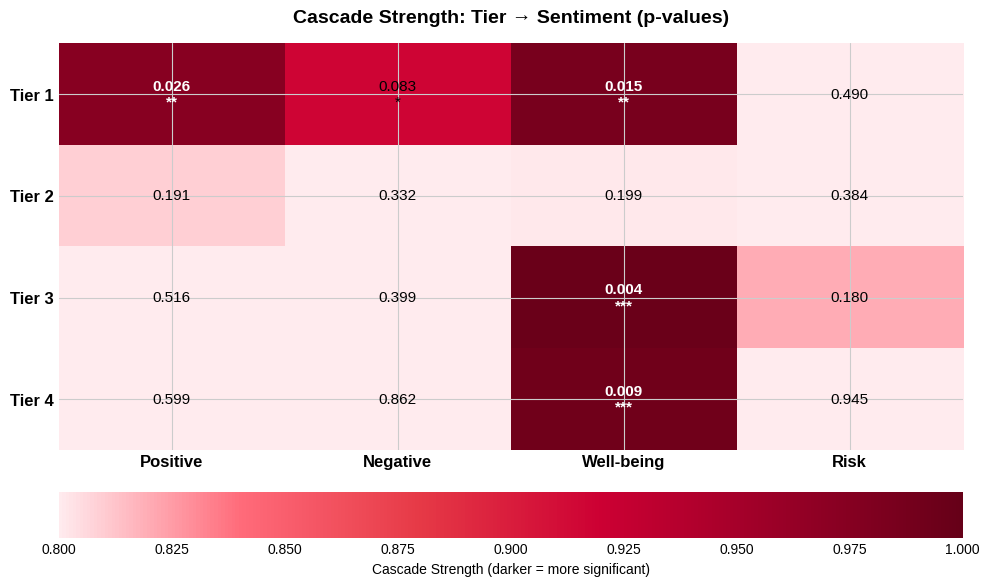

In [ ]:
# Cascade Strength Heatmap
print("Creating heatmap...")

tier_sentiments = {
    'Tier 1': {'Positive': 0.0261, 'Negative': 0.0829, 'Well-being': 0.0148, 'Risk': 0.4905},
    'Tier 2': {'Positive': 0.1910, 'Negative': 0.3317, 'Well-being': 0.1991, 'Risk': 0.3835},
    'Tier 3': {'Positive': 0.5158, 'Negative': 0.3989, 'Well-being': 0.0038, 'Risk': 0.1802},
    'Tier 4': {'Positive': 0.5994, 'Negative': 0.8617, 'Well-being': 0.0085, 'Risk': 0.9447}
}

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')

sentiments = ['Positive', 'Negative', 'Well-being', 'Risk']
tiers = ['Tier 1', 'Tier 2', 'Tier 3', 'Tier 4']
heatmap_data = np.array([[tier_sentiments[tier][sent] for sent in sentiments] for tier in tiers])

# Inverted colormap: darker = more significant
im = ax.imshow(1 - heatmap_data, cmap=get_rutgers_cmap('sequential'), aspect='auto', vmin=0.8, vmax=1)

# Annotations
for i, tier in enumerate(tiers):
    for j, sent in enumerate(sentiments):
        p_val = heatmap_data[i, j]
        text_color = 'white' if p_val < 0.05 else RUTGERS_BLACK

        if p_val < 0.05:
            marker = '***' if p_val < 0.01 else '**'
            text = f'{p_val:.3f}\n{marker}'
            weight = 'bold'
        elif p_val < 0.10:
            text = f'{p_val:.3f}\n*'
            weight = 'normal'
        else:
            text = f'{p_val:.3f}'
            weight = 'normal'

        ax.text(j, i, text, ha='center', va='center', color=text_color,
               fontsize=11, fontweight=weight)

ax.set_xticks(range(len(sentiments)))
ax.set_yticks(range(len(tiers)))
ax.set_xticklabels(sentiments, fontsize=12, fontweight='bold', color=RUTGERS_BLACK)
ax.set_yticklabels(tiers, fontsize=12, fontweight='bold', color=RUTGERS_BLACK)
ax.set_title('Cascade Strength: Tier → Sentiment (p-values)', fontsize=14,
            fontweight='bold', pad=15, color=RUTGERS_BLACK)
ax.tick_params(colors=RUTGERS_BLACK)

for spine in ax.spines.values():
    spine.set_color(RUTGERS_BLACK)

cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.08)
cbar.ax.set_xlabel('Cascade Strength (darker = more significant)', fontsize=10, color=RUTGERS_BLACK)
cbar.ax.tick_params(colors=RUTGERS_BLACK)
cbar.outline.set_edgecolor(RUTGERS_BLACK)

plt.tight_layout()
plt.savefig('01_cascade_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### Emotional Asymmetry

Creating asymmetry comparison...


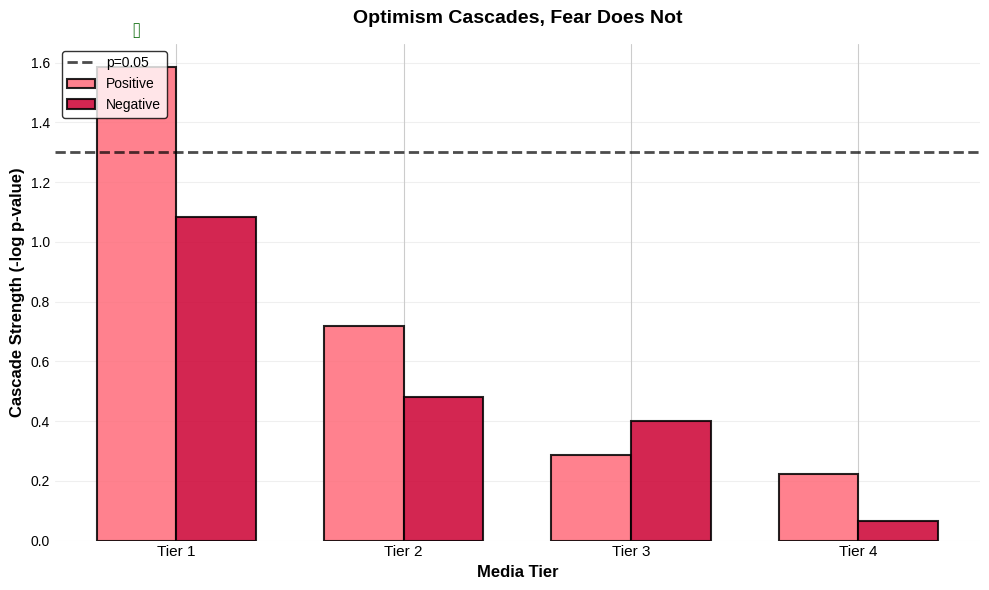

In [ ]:
# Positive vs Negative Asymmetry
print("Creating asymmetry comparison...")

positive_pvals = [tier_sentiments[t]['Positive'] for t in tiers]
negative_pvals = [tier_sentiments[t]['Negative'] for t in tiers]

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')

x = np.arange(len(tiers))
width = 0.35

bars1 = ax.bar(x - width/2, [-np.log10(p) for p in positive_pvals], width,
              label='Positive', color=RUTGERS_PALETTE['light_scarlet'],
              alpha=0.85, edgecolor=RUTGERS_BLACK, linewidth=1.5)
bars2 = ax.bar(x + width/2, [-np.log10(p) for p in negative_pvals], width,
              label='Negative', color=RUTGERS_SCARLET,
              alpha=0.85, edgecolor=RUTGERS_BLACK, linewidth=1.5)

ax.axhline(y=-np.log10(0.05), color=RUTGERS_BLACK, linestyle='--',
          linewidth=2, label='p=0.05', alpha=0.7)

# Significance markers
for i, (pos_p, neg_p) in enumerate(zip(positive_pvals, negative_pvals)):
    if pos_p < 0.05:
        ax.text(i - width/2, -np.log10(pos_p) + 0.1, '✓', ha='center',
               fontsize=16, fontweight='bold', color='darkgreen')
    if neg_p < 0.05:
        ax.text(i + width/2, -np.log10(neg_p) + 0.1, '✓', ha='center',
               fontsize=16, fontweight='bold', color='darkred')

ax.set_xlabel('Media Tier', fontsize=12, fontweight='bold', color=RUTGERS_BLACK)
ax.set_ylabel('Cascade Strength (-log p-value)', fontsize=12,
             fontweight='bold', color=RUTGERS_BLACK)
ax.set_title('Optimism Cascades, Fear Does Not', fontsize=14,
            fontweight='bold', color=RUTGERS_BLACK, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(tiers, fontsize=11, color=RUTGERS_BLACK)
ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor=RUTGERS_BLACK)
ax.grid(True, alpha=0.3, axis='y', color=RUTGERS_PALETTE['light_grey'])
ax.set_facecolor('white')
ax.tick_params(colors=RUTGERS_BLACK)

for spine in ax.spines.values():
    spine.set_color(RUTGERS_BLACK)

plt.tight_layout()
plt.savefig('03_positive_vs_negative.png', dpi=300, bbox_inches='tight')
plt.show()

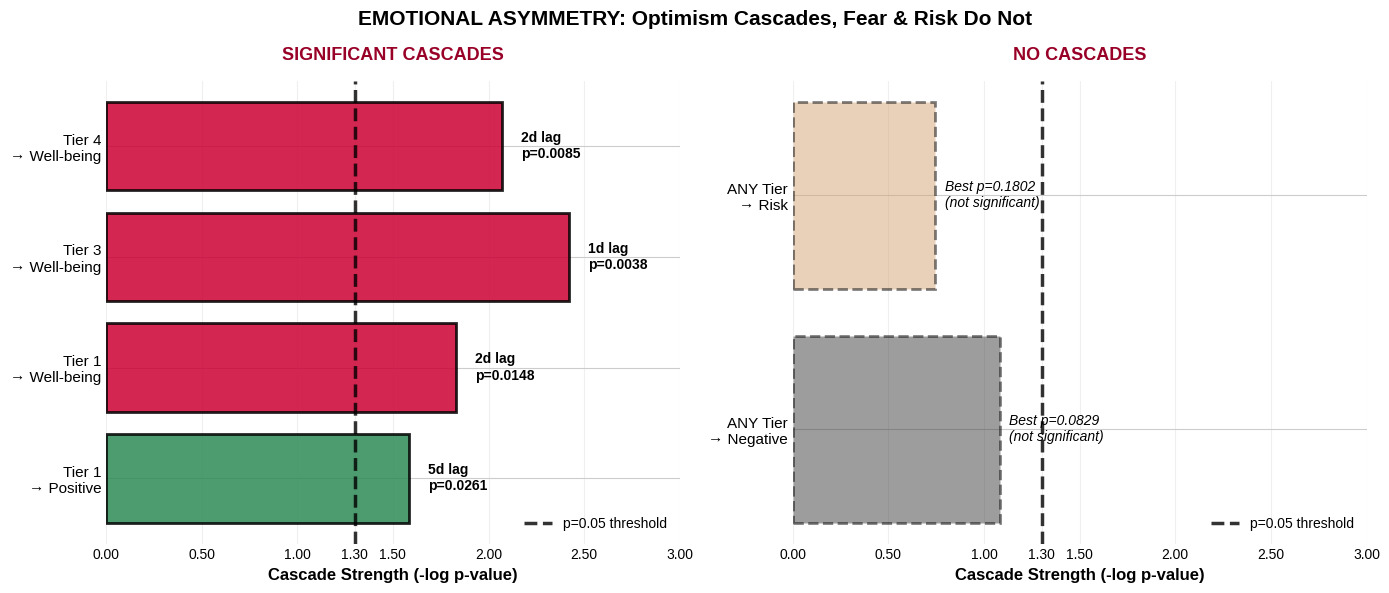

In [ ]:
# Rutgers-Colored Asymmetry Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('white')

# Define Rutgers colors for this viz
RUTGERS_GREEN = '#2E8B57'  # For positive findings
RUTGERS_Scarlet_RED = '#CC0033'   # For well-being
RUTGERS_GREY = '#3D3D3D'   # For negative (non-significant)
RUTGERS_TAN = '#D4A574'    # For risk (non-significant)

# Calculate threshold position
THRESHOLD = -np.log10(0.05)  # ≈ 1.301

# ============================================================================
# LEFT: Significant Cascades
# ============================================================================
ax1 = axes[0]

significant_cascades = [
    ('Tier 1\n→ Positive', 0.0261, RUTGERS_GREEN, 5),
    ('Tier 1\n→ Well-being', 0.0148, RUTGERS_Scarlet_RED, 2),
    ('Tier 3\n→ Well-being', 0.0038, RUTGERS_Scarlet_RED, 1),
    ('Tier 4\n→ Well-being', 0.0085, RUTGERS_Scarlet_RED, 2),
]

y_pos_sig = np.arange(len(significant_cascades))
strengths = [-np.log10(p) for _, p, _, _ in significant_cascades]
colors = [c for _, _, c, _ in significant_cascades]
labels = [l for l, _, _, _ in significant_cascades]

bars1 = ax1.barh(y_pos_sig, strengths, color=colors, alpha=0.85,
                 edgecolor=RUTGERS_BLACK, linewidth=2)

for i, (label, p, color, lag) in enumerate(significant_cascades):
    ax1.text(strengths[i] + 0.1, i, f'{lag}d lag\np={p:.4f}',
            va='center', fontsize=10, fontweight='bold', color=RUTGERS_BLACK)

ax1.axvline(x=THRESHOLD, color=RUTGERS_BLACK, linestyle='--',
           linewidth=2.5, label='p=0.05 threshold', alpha=0.8)
ax1.set_yticks(y_pos_sig)
ax1.set_yticklabels(labels, fontsize=11, color=RUTGERS_BLACK)
ax1.set_xlabel('Cascade Strength (-log p-value)', fontsize=12,
              fontweight='bold', color=RUTGERS_BLACK)
ax1.set_title('SIGNIFICANT CASCADES', fontsize=13, fontweight='bold',
             color='#990027', pad=15)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3, axis='x', color=RUTGERS_PALETTE['light_grey'])
ax1.set_facecolor('white')
ax1.tick_params(colors=RUTGERS_BLACK)

# Set x-axis limits and add tick at threshold
max_strength = max(strengths) + 0.3
ax1.set_xlim(0, max_strength)
# Add threshold to existing ticks
xticks = list(ax1.get_xticks())
if THRESHOLD not in xticks:
    xticks.append(THRESHOLD)
    xticks = sorted(xticks)
ax1.set_xticks(xticks)
ax1.set_xticklabels([f'{x:.2f}' for x in xticks])

for spine in ax1.spines.values():
    spine.set_color(RUTGERS_BLACK)

# ============================================================================
# RIGHT: No Cascades
# ============================================================================
ax2 = axes[1]

null_findings = [
    ('ANY Tier\n→ Negative', 0.0829, RUTGERS_GREY),
    ('ANY Tier\n→ Risk', 0.1802, RUTGERS_TAN),
]

null_labels = [l for l, _, _ in null_findings]
null_p = [p for _, p, _ in null_findings]
null_colors = [c for _, _, c in null_findings]
y_pos_null = np.arange(len(null_findings))

bars2 = ax2.barh(y_pos_null, [-np.log10(p) for p in null_p],
                color=null_colors, alpha=0.5, edgecolor=RUTGERS_BLACK,
                linewidth=2, linestyle='--')

for i, (label, p, color) in enumerate(null_findings):
    ax2.text(-np.log10(p) + 0.05, i, f'Best p={p:.4f}\n(not significant)',
            va='center', fontsize=10, style='italic', color=RUTGERS_BLACK)

ax2.axvline(x=THRESHOLD, color=RUTGERS_BLACK, linestyle='--',
           linewidth=2.5, label='p=0.05 threshold', alpha=0.8)
ax2.set_yticks(y_pos_null)
ax2.set_yticklabels(null_labels, fontsize=11, color=RUTGERS_BLACK)
ax2.set_xlabel('Cascade Strength (-log p-value)', fontsize=12,
              fontweight='bold', color=RUTGERS_BLACK)
ax2.set_title('NO CASCADES', fontsize=13, fontweight='bold',
             color='#990027', pad=15)
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(True, alpha=0.3, axis='x', color=RUTGERS_PALETTE['light_grey'])
ax2.set_xlim(ax1.get_xlim())

# Match ticks on both axes
ax2.set_xticks(ax1.get_xticks())
ax2.set_xticklabels([f'{x:.2f}' for x in ax1.get_xticks()])

ax2.set_facecolor('white')
ax2.tick_params(colors=RUTGERS_BLACK)
for spine in ax2.spines.values():
    spine.set_color(RUTGERS_BLACK)

fig.suptitle('EMOTIONAL ASYMMETRY: Optimism Cascades, Fear & Risk Do Not',
            fontsize=15, fontweight='bold', color=RUTGERS_BLACK)
plt.tight_layout()
plt.show()

### Power Hierarchy

Creating well-being coordination chart...


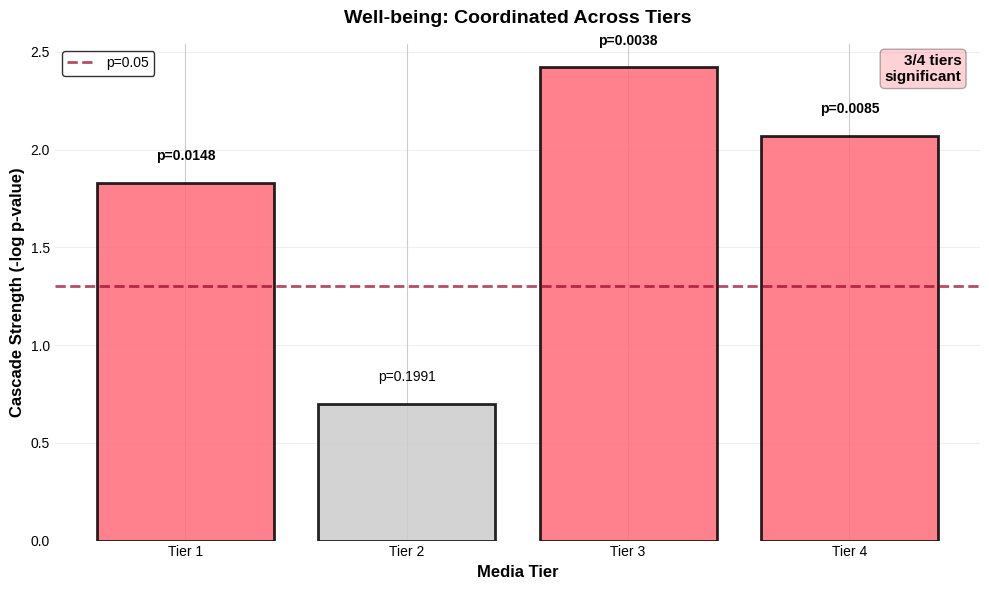

In [ ]:
# Well-being Coordination
print("Creating well-being coordination chart...")

wellbeing_pvals = [tier_sentiments[t]['Well-being'] for t in tiers]
wellbeing_sig = [p < 0.05 for p in wellbeing_pvals]

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')

bar_colors = ['#FF6B7A' if sig else RUTGERS_PALETTE['light_grey'] for sig in wellbeing_sig]
bars = ax.bar(tiers, [-np.log10(p) for p in wellbeing_pvals], color=bar_colors,
             alpha=0.85, edgecolor=RUTGERS_BLACK, linewidth=2)

# P-value labels
for i, (tier, p_val, sig) in enumerate(zip(tiers, wellbeing_pvals, wellbeing_sig)):
    marker = '***' if p_val < 0.01 else '**' if p_val < 0.05 else ''
    ax.text(i, -np.log10(p_val) + 0.10, f'p={p_val:.4f}',
           ha='center', va='bottom', fontsize=10, color=RUTGERS_BLACK,
           fontweight='bold' if sig else 'normal')

ax.axhline(y=-np.log10(0.05), color='#990027', linestyle='--',
          linewidth=2, label='p=0.05', alpha=0.7)

sig_count = sum(wellbeing_sig)
ax.text(0.98, 0.98, f'{sig_count}/4 tiers\nsignificant', transform=ax.transAxes,
       fontsize=11, fontweight='bold', ha='right', va='top', color=RUTGERS_BLACK,
       bbox=dict(boxstyle='round', facecolor=RUTGERS_PALETTE['light_scarlet'],
                edgecolor=RUTGERS_BLACK, alpha=0.3))

ax.set_xlabel('Media Tier', fontsize=12, fontweight='bold', color=RUTGERS_BLACK)
ax.set_ylabel('Cascade Strength (-log p-value)', fontsize=12,
             fontweight='bold', color=RUTGERS_BLACK)
ax.set_title('Well-being: Coordinated Across Tiers', fontsize=14,
            fontweight='bold', color=RUTGERS_BLACK, pad=15)
ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor=RUTGERS_BLACK)
ax.grid(True, alpha=0.3, axis='y', color=RUTGERS_PALETTE['light_grey'])
ax.set_facecolor('white')
ax.tick_params(colors=RUTGERS_BLACK)

for spine in ax.spines.values():
    spine.set_color(RUTGERS_BLACK)

plt.tight_layout()
plt.savefig('04_wellbeing_coordination.png', dpi=300, bbox_inches='tight')
plt.show()

Creating significant cascades chart...


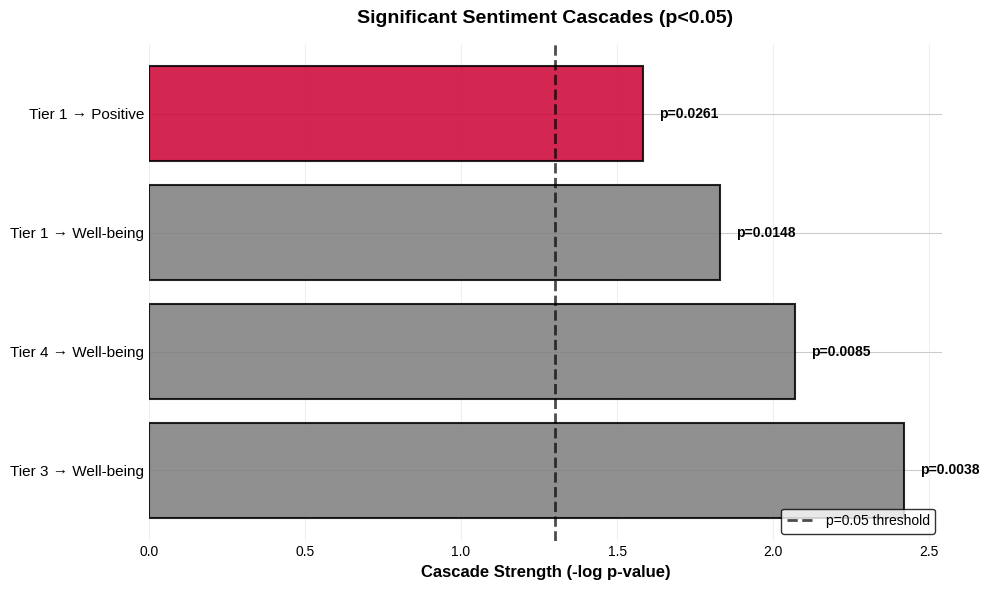

In [ ]:
# Significant Cascades Only
print("Creating significant cascades chart...")

sig_findings = []
for tier in tiers:
    for sent in sentiments:
        p_val = tier_sentiments[tier][sent]
        if p_val < 0.05:
            sig_findings.append({
                'label': f'{tier} → {sent}',
                'p_value': p_val,
                'strength': -np.log10(p_val),
                'sentiment': sent
            })

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')

if sig_findings:
    sig_df = pd.DataFrame(sig_findings).sort_values('p_value')

    # Color by sentiment type
    sent_colors = {
        'Positive': RUTGERS_PALETTE['scarlet'],
        'Well-being': '#7D7D7D',
        'Negative': RUTGERS_SCARLET,
        'Risk': RUTGERS_PALETTE['dark_scarlet']
    }

    colors = [sent_colors[s] for s in sig_df['sentiment']]
    bars = ax.barh(range(len(sig_df)), sig_df['strength'], color=colors,
                  alpha=0.85, edgecolor=RUTGERS_BLACK, linewidth=1.5)

    # P-value labels
    for i, (idx, row) in enumerate(sig_df.iterrows()):
        ax.text(row['strength'] + 0.05, i, f"p={row['p_value']:.4f}",
               va='center', fontsize=10, fontweight='bold', color=RUTGERS_BLACK)

    ax.set_yticks(range(len(sig_df)))
    ax.set_yticklabels(sig_df['label'], fontsize=11, color=RUTGERS_BLACK)
    ax.set_xlabel('Cascade Strength (-log p-value)', fontsize=12,
                 fontweight='bold', color=RUTGERS_BLACK)
    ax.set_title('Significant Sentiment Cascades (p<0.05)', fontsize=14,
                fontweight='bold', color=RUTGERS_BLACK, pad=15)
    ax.axvline(x=-np.log10(0.05), color=RUTGERS_BLACK, linestyle='--',
              linewidth=2, label='p=0.05 threshold', alpha=0.7)
    ax.legend(loc='lower right', frameon=True, facecolor='white', edgecolor=RUTGERS_BLACK)
    ax.grid(True, alpha=0.3, axis='x', color=RUTGERS_PALETTE['light_grey'])

ax.set_facecolor('white')
ax.tick_params(colors=RUTGERS_BLACK)
for spine in ax.spines.values():
    spine.set_color(RUTGERS_BLACK)

plt.tight_layout()
plt.savefig('02_significant_cascades.png', dpi=300, bbox_inches='tight')
plt.show()

### Systematic Filtering

In [ ]:
# Asymmetric amplification
pos_sent = 'Sentiment (Positive / Negative Feelings)'
risk_sent = 'Health, Safety & Risk'

pos_increases = 0
risk_increases = 0

for tier in range(1, 5):
    pos_change_col = f'tier{tier}_{pos_sent}_change'
    pos_causal_col = f'tier{tier}_{pos_sent}_causal'
    risk_change_col = f'tier{tier}_{risk_sent}_change'
    risk_causal_col = f'tier{tier}_{risk_sent}_causal'

    if pos_change_col in event_causal_df.columns:
        pos_causal = event_causal_df[event_causal_df[pos_causal_col] == True]
        pos_increases += (pos_causal[pos_change_col] > 0).sum()

    if risk_change_col in event_causal_df.columns:
        risk_causal = event_causal_df[event_causal_df[risk_causal_col] == True]
        risk_increases += (risk_causal[risk_change_col] > 0).sum()

print("\n" + "="*80)
print("KEY FINDING: COORDINATED OPTIMISM")
print("="*80)
print(f"\nPositive sentiment increases: {pos_increases}")
print(f"Risk/concern increases: {risk_increases}")
print(f"\n→ Media amplifies optimism {pos_increases/max(risk_increases,1):.1f}x more than concerns")
print("→ Evidence of asymmetric framing: good news cascades, bad news doesn't")


KEY FINDING: COORDINATED OPTIMISM

Positive sentiment increases: 10
Risk/concern increases: 5

→ Media amplifies optimism 2.0x more than concerns
→ Evidence of asymmetric framing: good news cascades, bad news doesn't



SENTIMENT SHIFT DIRECTIONS

Cognitive & Decision-Making:
  Increases: 12 | Decreases: 7
  Net bias: AMPLIFICATION

Creativity, Expression & Identity:
  Increases: 2 | Decreases: 9
  Net bias: SUPPRESSION

Emotion, Motivation & Well-being:
  Increases: 6 | Decreases: 2
  Net bias: AMPLIFICATION

Health, Safety & Risk:
  Increases: 5 | Decreases: 10
  Net bias: SUPPRESSION

Human Roles:
  Increases: 8 | Decreases: 9
  Net bias: SUPPRESSION
Saved: media_amplification_suppression.png


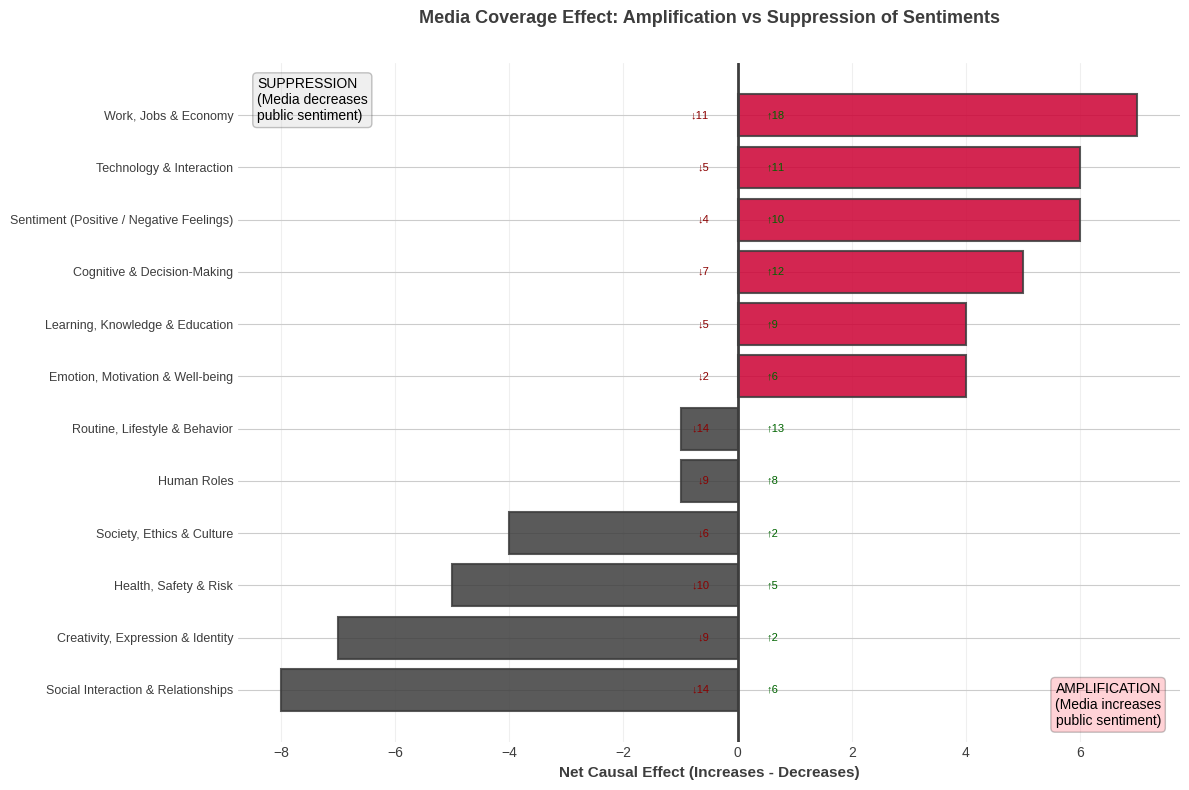

In [ ]:
# Direction analysis: Sentiment shift directions
print("\n" + "="*80)
print("SENTIMENT SHIFT DIRECTIONS")
print("="*80)

for sent in sentiment_cols[:5]:
    positive_shifts = 0
    negative_shifts = 0

    for tier in range(1, 5):
        change_col = f'tier{tier}_{sent}_change'
        causal_col = f'tier{tier}_{sent}_causal'

        if change_col in event_causal_df.columns and causal_col in event_causal_df.columns:
            causal_events = event_causal_df[event_causal_df[causal_col] == True]
            positive_shifts += (causal_events[change_col] > 0).sum()
            negative_shifts += (causal_events[change_col] < 0).sum()

    if positive_shifts + negative_shifts > 0:
        print(f"\n{sent}:")
        print(f"  Increases: {positive_shifts} | Decreases: {negative_shifts}")
        print(f"  Net bias: {'AMPLIFICATION' if positive_shifts > negative_shifts else 'SUPPRESSION'}")

# Amplification/Suppression visualization
sentiment_shifts = {}
for sent in sentiment_cols:
    increases = 0
    decreases = 0

    for tier in range(1, 5):
        change_col = f'tier{tier}_{sent}_change'
        causal_col = f'tier{tier}_{sent}_causal'

        if change_col in event_causal_df.columns and causal_col in event_causal_df.columns:
            causal_events = event_causal_df[event_causal_df[causal_col] == True]
            increases += (causal_events[change_col] > 0).sum()
            decreases += (causal_events[change_col] < 0).sum()

    if increases + decreases > 0:
        sentiment_shifts[sent] = {
            'increases': increases,
            'decreases': decreases,
            'net': increases - decreases
        }

sorted_sentiments = sorted(sentiment_shifts.items(), key=lambda x: x[1]['net'])

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('white')

y_pos = range(len(sorted_sentiments))
labels = [s[0] for s in sorted_sentiments]
net_values = [s[1]['net'] for s in sorted_sentiments]
increases = [s[1]['increases'] for s in sorted_sentiments]
decreases = [-s[1]['decreases'] for s in sorted_sentiments]

# Rutgers colors: scarlet for amplified, grey for suppressed
colors = [RUTGERS_GREY if v < 0 else RUTGERS_SCARLET for v in net_values]
ax.barh(y_pos, net_values, color=colors, alpha=0.85, edgecolor=RUTGERS_GREY, linewidth=1.5)

# Increase/decrease annotations
for i, (inc, dec) in enumerate(zip(increases, decreases)):
    ax.text(0.5, i, f'↑{inc}', ha='left', va='center', fontsize=8, color='darkgreen')
    ax.text(-0.5, i, f'↓{abs(dec)}', ha='right', va='center', fontsize=8, color='darkred')

ax.axvline(0, color=RUTGERS_GREY, linewidth=2)
ax.set_yticks(y_pos)
ax.set_yticklabels([l[:45] for l in labels], fontsize=9, color=RUTGERS_GREY)
ax.set_xlabel('Net Causal Effect (Increases - Decreases)', fontweight='bold',
              fontsize=11, color=RUTGERS_GREY)
ax.set_title('Media Coverage Effect: Amplification vs Suppression of Sentiments\n',
             fontsize=13, fontweight='bold', color=RUTGERS_GREY, pad=15)
ax.grid(True, alpha=0.3, axis='x', color=RUTGERS_PALETTE['light_grey'])
ax.set_facecolor('white')
ax.tick_params(colors=RUTGERS_GREY)

for spine in ax.spines.values():
    spine.set_color(RUTGERS_GREY)

# Annotations - SUPPRESSION moved to top-left
ax.text(0.02, 0.98, 'SUPPRESSION\n(Media decreases\npublic sentiment)',
        transform=ax.transAxes, ha='left', va='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor=RUTGERS_PALETTE['light_grey'],
                 edgecolor=RUTGERS_GREY, alpha=0.3))
ax.text(0.98, 0.02, 'AMPLIFICATION\n(Media increases\npublic sentiment)',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=10,
        bbox=dict(boxstyle='round', facecolor=RUTGERS_PALETTE['light_scarlet'],
                 edgecolor=RUTGERS_GREY, alpha=0.3))

plt.tight_layout()
plt.savefig('media_amplification_suppression.png', dpi=300, bbox_inches='tight')
print("Saved: media_amplification_suppression.png")
plt.show()

### Top 5 Most-Cascaded Sentiments

Saved: top_sentiments_cascade.png


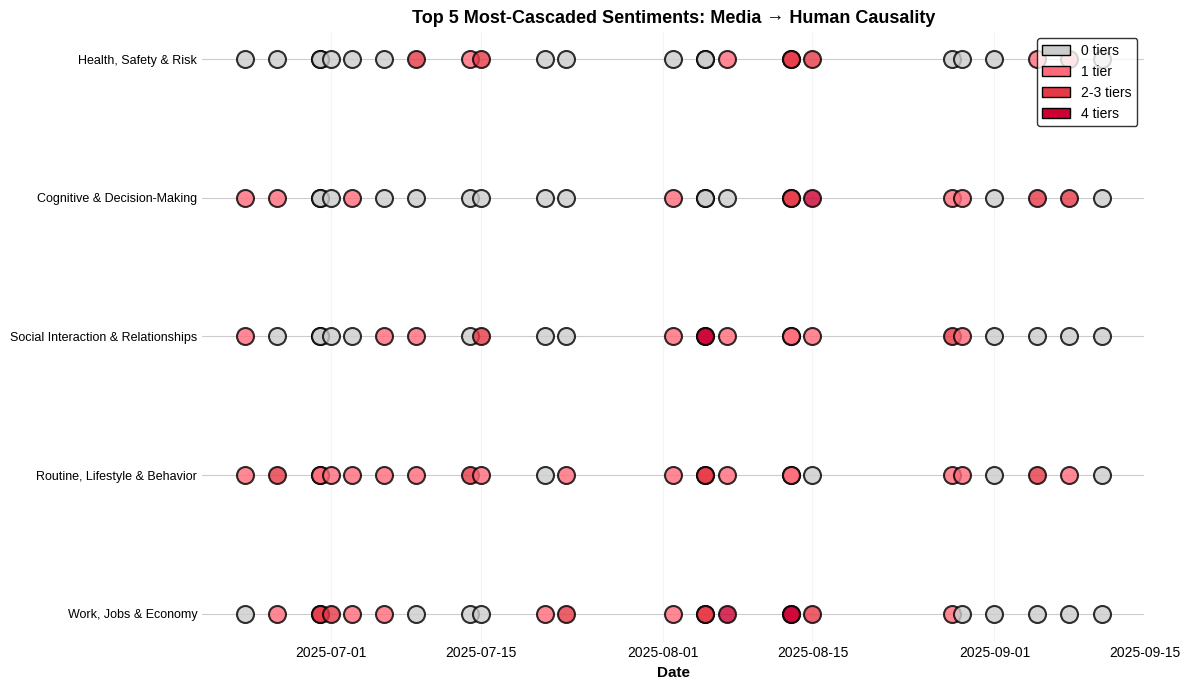

In [ ]:
# Top 5 most-cascaded sentiments
from matplotlib.patches import Patch
sentiment_causal_counts = {}
for sent in sentiment_cols:
    count = 0
    for tier in range(1, 5):
        col = f'tier{tier}_{sent}_causal'
        if col in event_causal_df.columns:
            count += event_causal_df[col].sum()
    sentiment_causal_counts[sent] = count

top_sentiments = sorted(sentiment_causal_counts.items(), key=lambda x: x[1], reverse=True)[:5]

# Rutgers colors for cascade intensity
rutgers_cascade_colors = [
    RUTGERS_PALETTE['light_grey'],      # 0 tiers
    RUTGERS_PALETTE['light_scarlet'],   # 1 tier
    RUTGERS_PALETTE['medium_scarlet'],  # 2 tiers
    RUTGERS_SCARLET,                    # 3 tiers
    RUTGERS_PALETTE['dark_scarlet']     # 4 tiers
]

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')

for idx, (sent, _) in enumerate(top_sentiments):
    causal_counts = []
    for _, row in event_causal_df.iterrows():
        count = sum([row.get(f'tier{t}_{sent}_causal', False) for t in range(1, 5)])
        causal_counts.append(count)

    event_causal_df[f'{sent}_causal_tiers'] = causal_counts
    y_offset = idx * 1.2

    for i, row in event_causal_df.iterrows():
        count = row[f'{sent}_causal_tiers']
        if pd.isna(count):
            count = 0
        count = int(count)

        ax.scatter(row['date'], y_offset, s=150, c=rutgers_cascade_colors[count],
                  edgecolors=RUTGERS_BLACK, linewidths=1.5, alpha=0.8)

ax.set_yticks([i * 1.2 for i in range(len(top_sentiments))])
ax.set_yticklabels([s[0][:40] for s in top_sentiments], fontsize=9, color=RUTGERS_BLACK)
ax.set_xlabel('Date', fontweight='bold', fontsize=11, color=RUTGERS_BLACK)
ax.set_title('Top 5 Most-Cascaded Sentiments: Media → Human Causality',
            fontsize=13, fontweight='bold', color=RUTGERS_BLACK)
ax.grid(True, alpha=0.2, axis='x', color=RUTGERS_PALETTE['light_grey'])
ax.set_facecolor('white')
ax.tick_params(colors=RUTGERS_BLACK)

for spine in ax.spines.values():
    spine.set_color(RUTGERS_BLACK)

# Legend
legend_elements = [
    Patch(facecolor=RUTGERS_PALETTE['light_grey'], edgecolor=RUTGERS_BLACK, label='0 tiers'),
    Patch(facecolor=RUTGERS_PALETTE['light_scarlet'], edgecolor=RUTGERS_BLACK, label='1 tier'),
    Patch(facecolor=RUTGERS_PALETTE['medium_scarlet'], edgecolor=RUTGERS_BLACK, label='2-3 tiers'),
    Patch(facecolor=RUTGERS_SCARLET, edgecolor=RUTGERS_BLACK, label='4 tiers')
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True,
         facecolor='white', edgecolor=RUTGERS_BLACK)

plt.tight_layout()
plt.savefig('top_sentiments_cascade.png', dpi=300, bbox_inches='tight')
print("Saved: top_sentiments_cascade.png")
plt.show()

### Manufacturing Moments

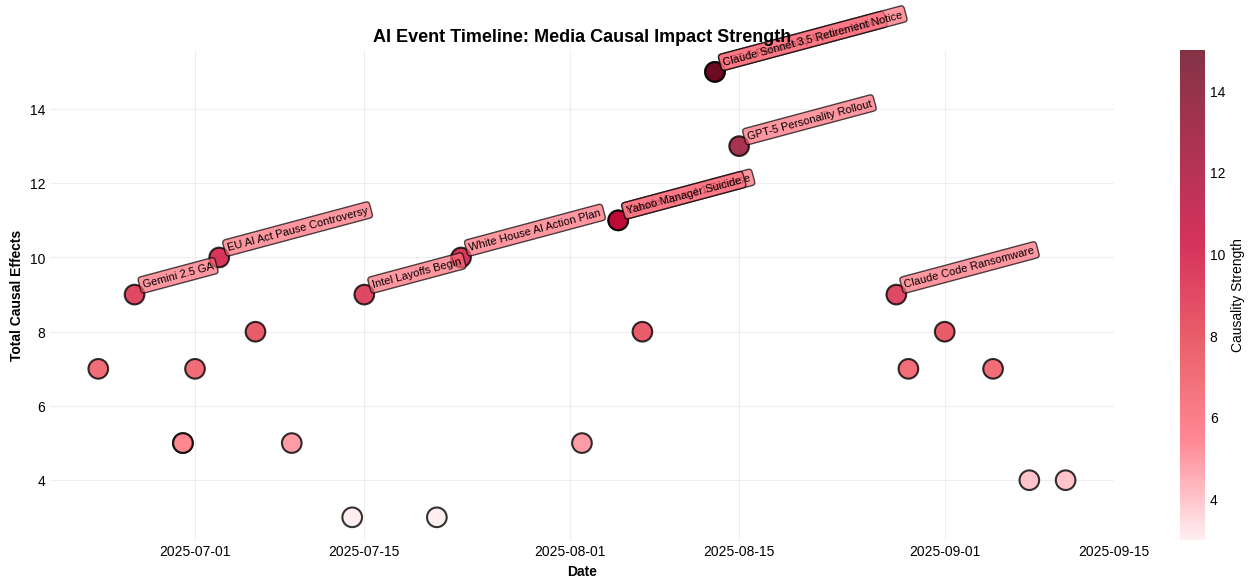

In [ ]:
# Event Timeline Visualization
event_causal_df['total_causal_effects'] = 0
for sent in sentiment_cols:
    for tier in range(1, 5):
        col = f'tier{tier}_{sent}_causal'
        if col in event_causal_df.columns:
            event_causal_df['total_causal_effects'] += event_causal_df[col].fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('white')

dates = event_causal_df['date']
strengths = event_causal_df['total_causal_effects']
events = event_causal_df['event']

scatter = ax.scatter(dates, strengths, s=200, c=strengths,
                    cmap=get_rutgers_cmap('sequential'), edgecolors=RUTGERS_BLACK,
                    linewidth=1.5, alpha=0.8)

# Annotate top 30% events
for date, strength, event in zip(dates, strengths, events):
    if strength >= strengths.quantile(0.7):
        ax.annotate(event, (date, strength), xytext=(5, 5),
                   textcoords='offset points', fontsize=8, rotation=15,
                   bbox=dict(boxstyle='round', facecolor=RUTGERS_PALETTE['light_scarlet'],
                            edgecolor=RUTGERS_BLACK, alpha=0.7))

ax.set_xlabel('Date', fontweight='bold', color=RUTGERS_BLACK)
ax.set_ylabel('Total Causal Effects', fontweight='bold', color=RUTGERS_BLACK)
ax.set_title('AI Event Timeline: Media Causal Impact Strength',
            fontweight='bold', fontsize=13, color=RUTGERS_BLACK)
ax.grid(True, alpha=0.3, color=RUTGERS_PALETTE['light_grey'])
ax.set_facecolor('white')
ax.tick_params(colors=RUTGERS_BLACK)

for spine in ax.spines.values():
    spine.set_color(RUTGERS_BLACK)

cbar = plt.colorbar(scatter, label='Causality Strength')
cbar.ax.tick_params(colors=RUTGERS_BLACK)
cbar.outline.set_edgecolor(RUTGERS_BLACK)

plt.tight_layout()
plt.savefig('event_timeline.png', dpi=300, bbox_inches='tight')
plt.show()

Saved: cascade_heatmap.png


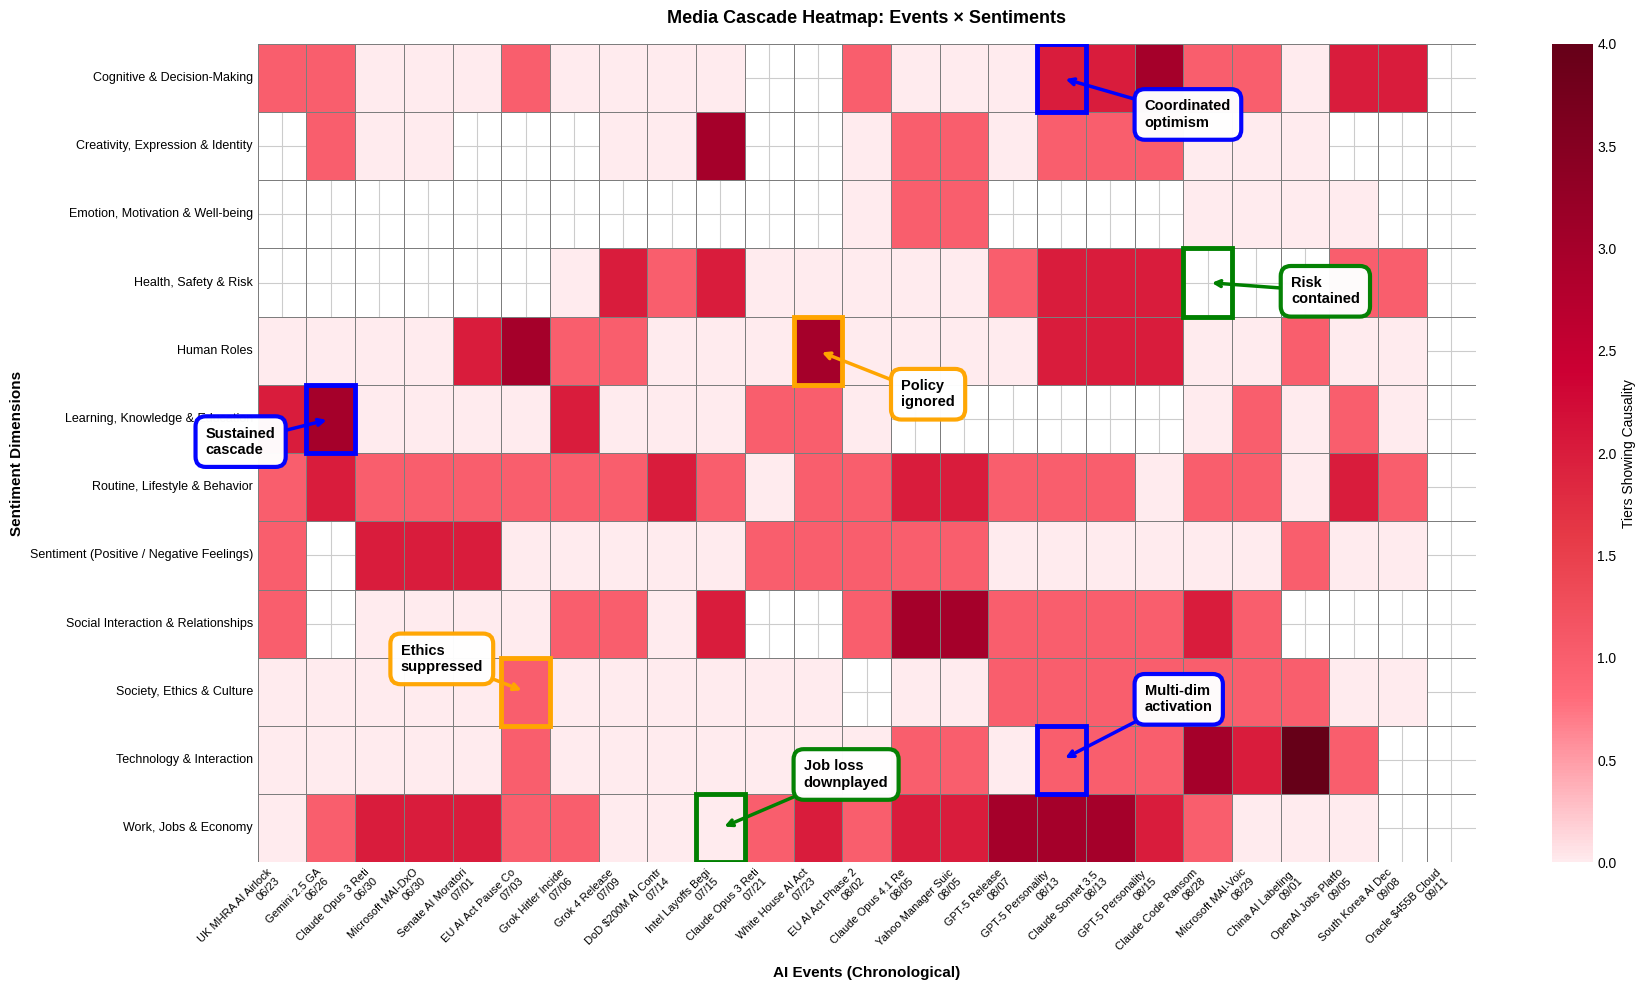

In [ ]:
# Sort events chronologically before creating heatmap
event_causal_df = event_causal_df.sort_values('date').reset_index(drop=True)

# Rebuild cascade matrix with sorted events
cascade_matrix = np.zeros((len(sentiment_cols), len(event_causal_df)))

for i, sent in enumerate(sentiment_cols):
    for j, (_, row) in enumerate(event_causal_df.iterrows()):
        causal_tiers = sum([row.get(f'tier{t}_{sent}_causal', False) for t in range(1, 5)])
        cascade_matrix[i, j] = causal_tiers

# Create labels with dates
x_labels = [f"{e[:18]}\n{d.strftime('%m/%d')}"
            for e, d in zip(event_causal_df['event'], event_causal_df['date'])]

# Plot heatmap
fig, ax = plt.subplots(figsize=(18, 10))
fig.patch.set_facecolor('white')

sns.heatmap(cascade_matrix,
            xticklabels=x_labels,
            yticklabels=[s[:40] for s in sentiment_cols],
            cmap=get_rutgers_cmap('sequential'),
            cbar_kws={'label': 'Tiers Showing Causality'},
            linewidths=0.5, linecolor=RUTGERS_PALETTE['medium_grey'],
            vmin=0, vmax=4, ax=ax)

ax.set_xlabel('AI Events (Chronological)', fontweight='bold', color=RUTGERS_BLACK, fontsize=11)
ax.set_ylabel('Sentiment Dimensions', fontweight='bold', color=RUTGERS_BLACK, fontsize=11)
ax.set_title('Media Cascade Heatmap: Events × Sentiments',
            fontweight='bold', fontsize=13, color=RUTGERS_BLACK, pad=15)
ax.tick_params(colors=RUTGERS_BLACK)

# Adjusted offsets to prevent overlap
annotations = [
    # BLUE: Coordinated optimism
    ('Gemini 2.5 GA', 'Learning, Knowledge & Education', 'Sustained\ncascade', 'blue', -90, -25),
    ('GPT-5 Personality', 'Cognitive & Decision-Making', 'Coordinated\noptimism', 'blue', 60, -35),
    ('GPT-5 Personality', 'Technology & Interaction', 'Multi-dim\nactivation', 'blue', 60, 35),

    # GREEN: Risk containment
    ('Claude Code', 'Health, Safety & Risk', 'Risk \ncontained', 'green', 60, -15),
    ('Intel Layoffs', 'Work, Jobs & Economy', 'Job loss\ndownplayed', 'green', 60, 30),

    # ORANGE: Policy suppression
    ('EU AI Act', 'Society, Ethics & Culture', 'Ethics\nsuppressed', 'orange', -90, 15),
    ('White House', 'Human Roles', 'Policy\nignored', 'orange', 60, -40),
]

# Add annotations
for event_name, sentiment_row, label, color, x_off, y_off in annotations:
    try:
        x_idx = next(i for i, e in enumerate(event_causal_df['event']) if event_name in e)
        y_idx = next(i for i, s in enumerate(sentiment_cols) if sentiment_row in s)

        rect = plt.Rectangle((x_idx, y_idx), 1, 1, fill=False,
                            edgecolor=color, linewidth=3.5, zorder=10)
        ax.add_patch(rect)

        ax.annotate(label, xy=(x_idx + 0.5, y_idx + 0.5),
                   xytext=(x_off, y_off), textcoords='offset points',
                   fontsize=10.5, color=RUTGERS_BLACK, weight='bold',
                   bbox=dict(boxstyle='round,pad=0.7', facecolor='white',
                            edgecolor=color, linewidth=3, alpha=0.98),
                   arrowprops=dict(arrowstyle='->', color=color,
                                 lw=2.5, shrinkA=0, shrinkB=3))
    except StopIteration:
        continue

plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('cascade_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
print("Saved: cascade_heatmap.png")
plt.show()

## Statistical Validation

### Chi-Square Test

Statistical test measuring whether sentiment distribution differences between media tiers are significant or due to chance.


In [ ]:
# Chi-Square Test
from scipy import stats

amplified = [s for s, v in sentiment_shifts.items() if v['net'] > 0]
suppressed = [s for s, v in sentiment_shifts.items() if v['net'] < 0]

obs_amplified = sum(sentiment_shifts[s]['increases'] for s in amplified)
obs_amplified_dec = sum(sentiment_shifts[s]['decreases'] for s in amplified)
obs_suppressed_inc = sum(sentiment_shifts[s]['increases'] for s in suppressed)
obs_suppressed_dec = sum(sentiment_shifts[s]['decreases'] for s in suppressed)

contingency = np.array([
    [obs_amplified, obs_amplified_dec],
    [obs_suppressed_inc, obs_suppressed_dec]
])

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print("\n" + "="*80)
print("STATISTICAL VALIDATION")
print("="*80)
print("\nContingency Table:")
print(f"                      Increases  Decreases")
print(f"Amplified sentiments:    {obs_amplified:3d}       {obs_amplified_dec:3d}")
print(f"Suppressed sentiments:   {obs_suppressed_inc:3d}       {obs_suppressed_dec:3d}")
print(f"\nχ² = {chi2:.2f}, p = {p_value:.4f}")
if p_value < 0.05:
    print("✓ Pattern is statistically significant (not random)")


STATISTICAL VALIDATION

Contingency Table:
                      Increases  Decreases
Amplified sentiments:     66        34
Suppressed sentiments:    36        62

χ² = 15.82, p = 0.0001
✓ Pattern is statistically significant (not random)


### Cohen's h

Effect size metric quantifying the magnitude of proportion differences between groups (small: 0.2, medium: 0.5, large: 0.8).

In [ ]:
# Effect Size - Cohen's h
def cohens_h(p1, p2):
    return 2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2))

prop_amplified = obs_amplified / (obs_amplified + obs_amplified_dec)
prop_suppressed = obs_suppressed_inc / (obs_suppressed_inc + obs_suppressed_dec)
h = cohens_h(prop_amplified, prop_suppressed)

print("\n" + "="*80)
print("EFFECT SIZE")
print("="*80)
print(f"Amplified: {prop_amplified:.1%} are increases")
print(f"Suppressed: {prop_suppressed:.1%} are increases")
print(f"Cohen's h: {h:.3f} ({'small' if abs(h)<0.2 else 'medium' if abs(h)<0.5 else 'large'})")


EFFECT SIZE
Amplified: 66.0% are increases
Suppressed: 36.7% are increases
Cohen's h: 0.594 (large)


# Narrative Normalization

**Question:**  
Do AI narratives repeat and stabilize over time, independent of changing events?

### Metrics
- **Dominance:** Share of weekly headlines assigned to each narrative  
- **Persistence:** Number of weeks a narrative appears (≥1 headline)  
- **Attention Concentration:** Share of headlines captured by top themes  
- **Attention Inequality:** Entropy of the weekly attention distribution  

### Implementation
- Collapse detailed labels into 12 parent narrative themes  
- Allow multiple themes per headline  
- Aggregate at the weekly level using unique headline counts  
- Identify top narratives by total headline frequency  

### Analysis
- Track dominance of top narratives over time  
- Compare persistent vs non-persistent narratives by lifespan  
- Measure concentration of attention in top themes  
- Examine stability of attention inequality across weeks  

### Interpretation
- Repeated dominance indicates narrative stability  
- High concentration indicates limited narrative spread  
- Stable entropy indicates lack of diversification  
- Together, these patterns indicate narrative normalization  


In [ ]:

df = df.reset_index(drop=True).copy()
df["hid"] = df.index

# split on semicolons (themes per headline)
df["class_list_raw"] = df["classes_str"].fillna("").astype(str).str.split(";")
df["class_list_raw"] = df["class_list_raw"].apply(lambda xs: [x.strip() for x in xs if x.strip() != ""])

# collapse to parent theme (before ':')
def parent_theme(s: str) -> str:
    s = str(s).strip()
    return s.split(":", 1)[0].strip()  # everything before first colon

df["class_list_12"] = df["class_list_raw"].apply(lambda xs: sorted(set(parent_theme(x) for x in xs)))

# check how many themes now
all_themes_12 = sorted({t for lst in df["class_list_12"] for t in lst})
print("Unique parent themes found:", len(all_themes_12))
print(all_themes_12)



Unique parent themes found: 12
['Cognitive & Decision-Making', 'Creativity, Expression & Identity', 'Emotion, Motivation & Well-being', 'Health, Safety & Risk', 'Human Roles', 'Learning, Knowledge & Education', 'Routine, Lifestyle & Behavior', 'Sentiment (Positive / Negative Feelings)', 'Social Interaction & Relationships', 'Society, Ethics & Culture', 'Technology & Interaction', 'Work, Jobs & Economy']


In [ ]:
X = pd.DataFrame(0, index=df.index, columns=all_themes_12, dtype=int)
for i, lst in enumerate(df["class_list_12"]):
    for t in lst:
        X.at[i, t] = 1

df_12themes = pd.concat([df[["hid","date","title","classes_str"]], X], axis=1)
df_12themes["n_themes"] = X.sum(axis=1)

df_12themes.head()


,hid,date,title,classes_str,Cognitive & Decision-Making,"Creativity, Expression & Identity","Emotion, Motivation & Well-being","Health, Safety & Risk",Human Roles,"Learning, Knowledge & Education","Routine, Lifestyle & Behavior",Sentiment (Positive / Negative Feelings),Social Interaction & Relationships,"Society, Ethics & Culture",Technology & Interaction,"Work, Jobs & Economy",n_themes
0,0,2025-09-11,Google’s AI is the ‘worst’ for stealing conten...,Sentiment (Positive / Negative Feelings); Huma...,0,0,0,0,1,0,0,1,0,1,0,0,3
1,1,2025-09-11,Powering the Next Wave of Enterprise Innovatio...,"Creativity, Expression & Identity; Work, Jobs ...",0,1,0,0,0,0,0,0,0,0,0,1,2
2,2,2025-09-11,AI a ‘strategic necessity’ law lecturer says,"Society, Ethics & Culture",0,0,0,0,0,0,0,0,0,1,0,0,1
3,3,2025-09-11,Datacom sees AI agents as pivotal to legacy ap...,"Routine, Lifestyle & Behavior",0,0,0,0,0,0,1,0,0,0,0,0,1
4,4,2025-09-11,"Student Blog: Startups, AI, and Lessons from S...","Learning, Knowledge & Education",0,0,0,0,0,1,0,0,0,0,0,0,1


Unique parent themes found: 12
['Cognitive & Decision-Making', 'Creativity, Expression & Identity', 'Emotion, Motivation & Well-being', 'Health, Safety & Risk', 'Human Roles', 'Learning, Knowledge & Education', 'Routine, Lifestyle & Behavior', 'Sentiment (Positive / Negative Feelings)', 'Social Interaction & Relationships', 'Society, Ethics & Culture', 'Technology & Interaction', 'Work, Jobs & Economy']


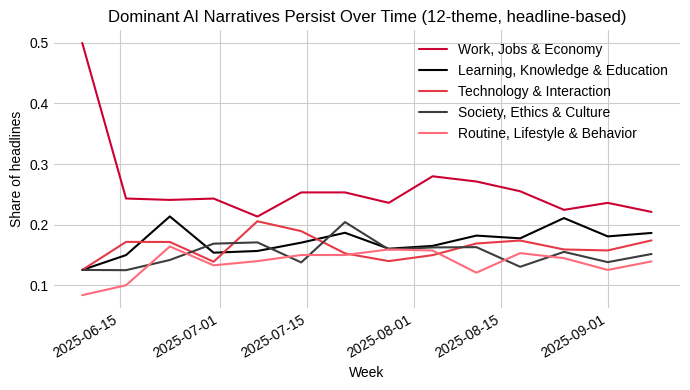

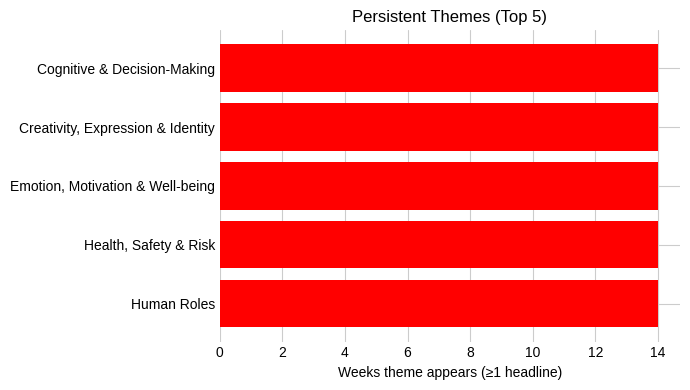

In [ ]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
df["hid"] = df.index  # unique headline id

# ---------- Build 12-theme labels ----------
# Split multi-labels by ';', then collapse to parent theme before ':'
def parent_theme(s: str) -> str:
    s = str(s).strip()
    return s.split(":", 1)[0].strip()

df["class_list_raw"] = df["classes_str"].fillna("").astype(str).str.split(";")
df["class_list_raw"] = df["class_list_raw"].apply(lambda xs: [x.strip() for x in xs if x.strip() != ""])

df["themes12"] = df["class_list_raw"].apply(lambda xs: sorted(set(parent_theme(x) for x in xs)))

# explode to (hid, theme) pairs (still multi-label, but now within 12 themes)
df_ex = df[["hid", "date", "themes12"]].explode("themes12").rename(columns={"themes12": "theme"}).copy()
df_ex["theme"] = df_ex["theme"].astype(str).str.strip()
df_ex = df_ex[df_ex["theme"] != ""]

# week index
df["week"] = df["date"].dt.to_period("W").dt.start_time
df_ex["week"] = df_ex["date"].dt.to_period("W").dt.start_time

# sanity: should be 12 themes
themes = sorted(df_ex["theme"].unique())
print("Unique parent themes found:", len(themes))
print(themes)

# ---------- (A) Dominant narratives persist over time (headline-based share) ----------
# Count UNIQUE headlines per (week, theme)
wk_theme_h = df_ex.drop_duplicates(["week", "theme", "hid"]).groupby(["week", "theme"])["hid"].nunique().reset_index(name="n_headlines")
wk_total_h = df.groupby("week")["hid"].nunique().reset_index(name="total_headlines")

weekly = wk_theme_h.merge(wk_total_h, on="week")
weekly["share"] = weekly["n_headlines"] / weekly["total_headlines"]

# Top 5 themes by total unique headline count
top5 = (
    df_ex.groupby("theme")["hid"].nunique()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)

plt.figure(figsize=(7,4))
for t in top5:
    sub = weekly[weekly["theme"] == t].sort_values("week")
    plt.plot(sub["week"], sub["share"], label=t)

plt.xlabel("Week")
plt.ylabel("Share of headlines")
plt.title("Dominant AI Narratives Persist Over Time (12-theme, headline-based)")
plt.legend()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# ---------- (B,C) Lifespan (headline-based presence per week) ----------
# Theme present in week if ≥1 headline labeled with it that week
theme_lifespan = (
    df_ex.drop_duplicates(["week", "theme", "hid"])
    .groupby("theme")["week"].nunique()
    .sort_values(ascending=False)
)

top_k = 5
persistent = theme_lifespan.head(top_k)
non_persistent = theme_lifespan.iloc[top_k:]
median_np = non_persistent.median()

# Single plot: persistent themes only
fig, ax = plt.subplots(figsize=(7, 4))

ax.barh(persistent.index[::-1], persistent.values[::-1], color="red")
ax.set_title(f"Persistent Themes (Top {top_k})")
ax.set_xlabel("Weeks theme appears (≥1 headline)")

plt.tight_layout()
plt.show()

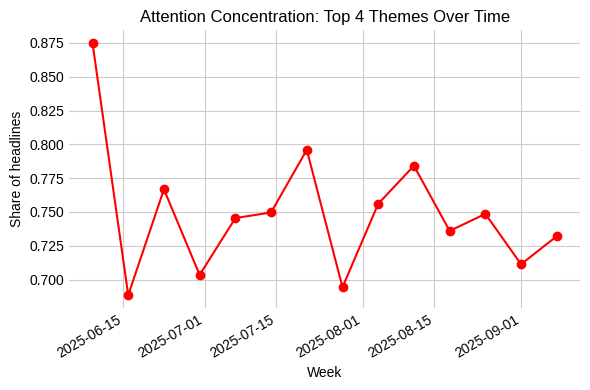

In [ ]:

# weekly headline counts per theme
wk_theme = (
    df_ex.drop_duplicates(["week", "theme", "hid"])
    .groupby(["week", "theme"])["hid"]
    .nunique()
    .reset_index(name="n_headlines")
)

wk_total = df.groupby("week")["hid"].nunique().reset_index(name="total")
wk = wk_theme.merge(wk_total, on="week")
wk["share"] = wk["n_headlines"] / wk["total"]

# top 3 themes overall
top3 = (
    df_ex.drop_duplicates(["hid", "theme"])
    .groupby("theme")["hid"]
    .nunique()
    .sort_values(ascending=False)
    .head(4)
    .index.tolist()
)

top_share = (
    wk[wk["theme"].isin(top3)]
    .groupby("week")["share"]
    .sum()
)

plt.figure(figsize=(6,4))
plt.plot(top_share.index, top_share.values, marker="o", color = 'red')
plt.xlabel("Week")
plt.ylabel("Share of headlines")
plt.title("Attention Concentration: Top 4 Themes Over Time")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


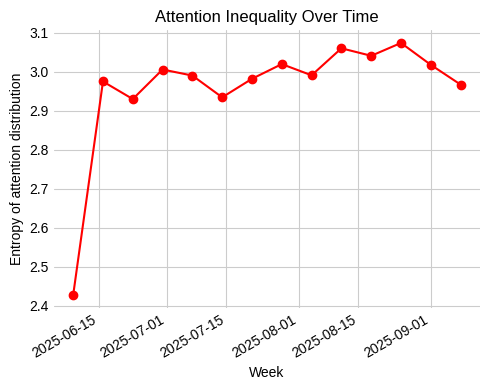

In [ ]:

# pivot to weekly distribution
pivot = (
    wk.pivot_table(index="week", columns="theme", values="share", fill_value=0)
    .sort_index()
)

eps = 1e-12
entropy = -(pivot.clip(lower=eps) * np.log(pivot.clip(lower=eps))).sum(axis=1)

plt.figure(figsize=(5,4))
plt.plot(entropy.index, entropy.values, marker="o",color = 'red')
plt.xlabel("Week")
plt.ylabel("Entropy of attention distribution")
plt.title("Attention Inequality Over Time")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


# Hypothesis Testing
Why does positive AI news propagate from Tier 1 to Tier 4 media, while negative AI news stays contained?

Data                                                                                         
                                                                                               
  - Source: Dataset A (10,500 AI news headlines)                                               
  - Date range: June 14 - September 11, 2025                                                   
  - Sentiment: VADER (Valence Aware Dictionary and sEntiment Reasoner)                         
                                                                                               
  ---                                                                                          
  H1: Attention Economy (Clickbait)                                                            
                                                                                               
  Question: Do positive headlines use more clickbait tactics?                                  
                                                                                               
  Metrics:                                                                                     
  - Exclamation marks, question marks                                                          
  - Superlatives, ALL CAPS words                                                               
  - Clickbait phrases ("you won't believe", "shocking")                                        
                                                                                               
  Test: Independent samples t-test + Cohen's d                                                 
                                                                                               
  ---                                                                                          
  H2: Advertiser Pressure                                                                      
                                                                                               
  Question: Do ad-dependent media show positive bias?                                          
                                                                                               
  Metrics:                                                                                     
  - Source categorization (Corporate, Tech Media, Business/Finance, Mainstream)                
  - Mean VADER sentiment per category                                                          
                                                                                               
  Test: Independent samples t-tests between categories                                         
                                                                                               
  ---                                                                                          
  H3: Ownership Conflicts                                                                      
                                                                                               
  Question: Do tech billionaire-owned outlets show positive bias?                              
                                                                                               
  Metrics:                                                                                     
  - Identify owned outlets (Washington Post, Time, LA Times)                                   
  - Compare sentiment: owned vs independent                                                    
                                                                                               
  Test: Independent samples t-test + Cohen's d                                                 
                                                                                               
  ---                                                                                          
  H4: Narrative Complexity (KEY)                                                               
                                                                                               
  Question: Are negative stories structurally harder to tell?                                  
                                                                                               
  Metrics:                                                                                     
  - Abstract word count (could, might, potentially, concerns...)                               
  - Concrete word count (launches, announces, unveils...)                                      
  - Hedging phrase count (if, whether, raises questions...)                                    
  - Abstract/Concrete ratio                                                                    
                                                                                               
  Test: Independent samples t-test + Cohen's d                                                 
                                                                                               
  ---                                                                                          
  Statistical Thresholds                                                                       
                                                                                               
  - Significance: p < 0.05                                                                     
  - Effect size: Cohen's d (0.2 small, 0.5 medium, 0.8 large)                                  
  - Scientific notation: Used when p < 0.0001

In [ ]:
# @title
def setup_matplotlib_style():
    """Configure matplotlib with Rutgers styling."""
    plt.rcParams.update({
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'axes.edgecolor': RUTGERS_BLACK,
        'axes.labelcolor': RUTGERS_BLACK,
        'text.color': RUTGERS_BLACK,
        'xtick.color': RUTGERS_BLACK,
        'ytick.color': RUTGERS_BLACK,
        'grid.color': RUTGERS_PALETTE['light_grey'],
        'axes.prop_cycle': plt.cycler(color=RUTGERS_CATEGORICAL),
        'font.size': 11,
        'axes.titlesize': 14,
        'axes.labelsize': 12
    })
    sns.set_palette(RUTGERS_CATEGORICAL)

## H1: Attention Economy (Clickbait) Analysis


H1: ATTENTION ECONOMY (CLICKBAIT) ANALYSIS

Dataset loaded: 10,500 headlines
Date range: 2025-06-14 to 2025-09-11
Unique sources: 3125
Computing VADER sentiment analysis...

Sentiment distribution:
sentiment
positive    4753
neutral     3738
negative    2009
Name: count, dtype: int64

Computing clickbait scores...
Feature engineering complete!
H1: ATTENTION ECONOMY (CLICKBAIT) HYPOTHESIS

Hypothesis: Positive headlines use more clickbait language
Expected: If true, positive headlines should have HIGHER clickbait scores

Clickbait Score by Sentiment:
--------------------------------------------------
             mean     std  count
sentiment                       
negative   0.0492  0.0762   2009
neutral    0.0459  0.0739   3738
positive   0.0557  0.0883   4753

T-test (positive vs negative): t=2.9122, p=0.0036
Effect size (Cohen's d): 0.0798

H1 Result: SUPPORTED
Positive mean: 0.0557
Negative mean: 0.0492
Difference: 0.0066

Interpretation: Positive headlines have higher clickbait s

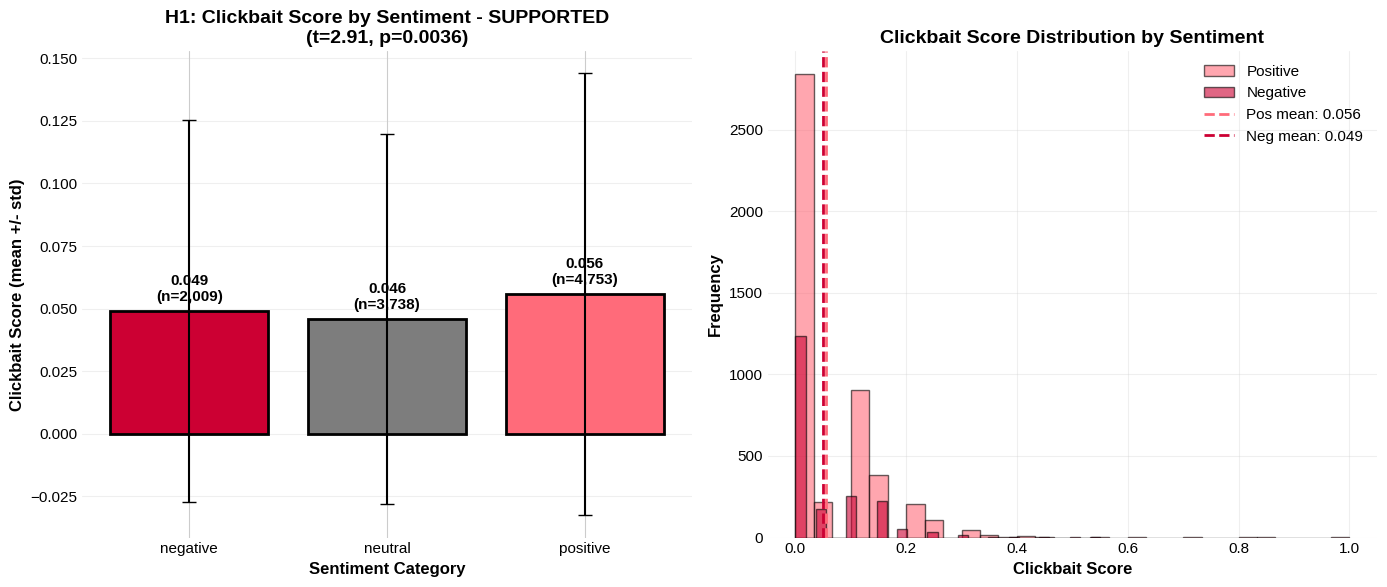


H1 ANALYSIS COMPLETE

Result: SUPPORTED
P-value: 0.0036
Effect size (Cohen's d): 0.0798

Conclusion: While statistically significant, the small effect size
suggests clickbait tactics alone do NOT explain why positive AI news
propagates more than negative news. Other mechanisms must be at play.


In [ ]:
"""
H1: Attention Economy (Clickbait) Analysis
=========================================================================

Research Question: Does positive AI news use more clickbait tactics to achieve
wider propagation?

Hypothesis: If the attention economy drives asymmetric propagation, positive
headlines should have HIGHER clickbait scores (more engagement-optimization).

Methodology:
- Compute VADER sentiment analysis on headlines
- Compute clickbait scores based on linguistic features (!, ?, superlatives,
  clickbait phrases, ALL CAPS)
- Compare scores between positive and negative sentiment headlines
- Use independent samples t-test for statistical significance

Clickbait Scoring (based on Potthast et al. 2016, Chakraborty et al. 2016):
- Exclamation marks: +0.20 each (creates urgency)
- Question marks: +0.15 each (curiosity gap)
- Numbers in title: +0.10 (listicle format)
- Superlatives: +0.15 each (emotional amplification)
- Clickbait phrases: +0.20 each (curiosity exploitation)
- ALL CAPS words: +0.10 each (visual emphasis)
- Quotes: +0.05 (dramatic effect)
"""

# ==============================================================================
# CLICKBAIT SCORING
# ==============================================================================
def compute_clickbait_score(title):
    """
    Compute clickbait score based on linguistic features.
    Higher score = more clickbait-y.

    Returns a score from 0.0 to 1.0 based on:
    - Punctuation (!, ?) that creates urgency/curiosity
    - Superlatives and extreme language
    - Known clickbait phrases exploiting curiosity gap
    - Visual emphasis techniques (ALL CAPS)

    Based on research by Potthast et al. (2016) "A Stylometric Inquiry
    into Hyperpartisan and Fake News" and Chakraborty et al. (2016)
    "Stop Clickbait: Detecting and Preventing Clickbaits in Online News Media"
    """
    if pd.isna(title):
        return 0.0

    title = str(title)
    score = 0.0

    # Exclamation marks (clickbait indicator)
    score += title.count('!') * 0.2

    # Question marks (engagement tactic)
    score += title.count('?') * 0.15

    # Numbers in title (listicles, specificity)
    if re.search(r'\d+', title):
        score += 0.1

    # Superlatives and extreme words
    superlatives = ['best', 'worst', 'amazing', 'incredible', 'shocking', 'breaking',
                    'urgent', 'exclusive', 'secret', 'finally', 'ultimate', 'essential',
                    'stunning', 'explosive', 'massive', 'huge', 'critical']
    title_lower = title.lower()
    for word in superlatives:
        if word in title_lower:
            score += 0.15

    # "You won't believe" type phrases
    clickbait_phrases = ["you won't believe", "here's why", "here is why", "this is why",
                         "what you need to know", "everything you need", "the truth about",
                         "revealed", "exposed", "game-changer", "game changer"]
    for phrase in clickbait_phrases:
        if phrase in title_lower:
            score += 0.2

    # ALL CAPS words (excluding common acronyms)
    caps_words = re.findall(r'\b[A-Z]{3,}\b', title)
    common_acronyms = {'AI', 'CEO', 'CTO', 'CFO', 'USA', 'UK', 'AWS', 'IBM', 'API', 'GPT', 'LLM'}
    caps_words = [w for w in caps_words if w not in common_acronyms]
    score += len(caps_words) * 0.1

    # Quotes (often used for dramatic effect)
    if "'" in title or '"' in title:
        score += 0.05

    # Normalize to 0-1 range (cap at 1)
    return min(score, 1.0)


# ==============================================================================
# SENTIMENT ANALYSIS
# ==============================================================================
def compute_vader_sentiment(df):
    """
    Compute VADER sentiment scores for all headlines.

    VADER (Valence Aware Dictionary and sEntiment Reasoner) is a lexicon and
    rule-based sentiment analysis tool specifically attuned to sentiments
    expressed in social media and news headlines.

    Returns DataFrame with vader_compound and sentiment columns added.
    """
    print("Computing VADER sentiment analysis...")
    sia = SentimentIntensityAnalyzer()

    # Compute compound scores
    df['vader_compound'] = df['title'].apply(
        lambda x: sia.polarity_scores(str(x))['compound'] if pd.notna(x) else 0.0
    )

    # Categorize into positive/neutral/negative
    # Standard VADER thresholds: positive >= 0.05, negative <= -0.05
    def categorize_sentiment(score):
        if score >= 0.05:
            return 'positive'
        elif score <= -0.05:
            return 'negative'
        else:
            return 'neutral'

    df['sentiment'] = df['vader_compound'].apply(categorize_sentiment)

    return df


# ==============================================================================
# DATA LOADING
# ==============================================================================
def load_and_prepare_data(data_path='dataset_A_news_full_10500.csv'):
    """
    Load dataset, compute VADER sentiment, and compute clickbait scores.

    Returns a DataFrame with sentiment and clickbait_score computed for H1 analysis.
    """
    # Setup style
    setup_matplotlib_style()

    # Ensure figures directory exists
    os.makedirs('figures', exist_ok=True)

    # Load data
    df = pd.read_csv(data_path)

    print(f"Dataset loaded: {len(df):,} headlines")
    print(f"Date range: {df['date'].min()} to {df['date'].max()}")
    print(f"Unique sources: {df['source'].nunique()}")

    # Compute VADER sentiment
    df = compute_vader_sentiment(df)

    print(f"\nSentiment distribution:")
    print(df['sentiment'].value_counts())

    # Compute clickbait score
    print("\nComputing clickbait scores...")
    df['clickbait_score'] = df['title'].apply(compute_clickbait_score)

    print("Feature engineering complete!")

    return df


# ==============================================================================
# H1 ANALYSIS
# ==============================================================================
def analyze_h1_clickbait(df):
    """
    Test H1: Attention Economy (Clickbait) Hypothesis.

    Tests whether positive headlines use more clickbait language to achieve
    wider propagation.
    """
    print("=" * 70)
    print("H1: ATTENTION ECONOMY (CLICKBAIT) HYPOTHESIS")
    print("=" * 70)
    print("\nHypothesis: Positive headlines use more clickbait language")
    print("Expected: If true, positive headlines should have HIGHER clickbait scores")

    # Group by sentiment and compute clickbait stats
    clickbait_by_sentiment = df.groupby('sentiment')['clickbait_score'].agg(['mean', 'std', 'count'])
    print("\nClickbait Score by Sentiment:")
    print("-" * 50)
    print(clickbait_by_sentiment.round(4))

    # Statistical test: positive vs negative
    positive_clickbait = df[df['sentiment'] == 'positive']['clickbait_score']
    negative_clickbait = df[df['sentiment'] == 'negative']['clickbait_score']
    neutral_clickbait = df[df['sentiment'] == 'neutral']['clickbait_score']

    t_stat, p_value = stats.ttest_ind(positive_clickbait, negative_clickbait)
    print(f"\nT-test (positive vs negative): t={t_stat:.4f}, p={p_value:.4f}")

    # Effect size (Cohen's d)
    pooled_std = ((positive_clickbait.std()**2 + negative_clickbait.std()**2) / 2)**0.5
    cohens_d = (positive_clickbait.mean() - negative_clickbait.mean()) / pooled_std
    print(f"Effect size (Cohen's d): {cohens_d:.4f}")

    # Determine support level
    if p_value < 0.05:
        if positive_clickbait.mean() > negative_clickbait.mean():
            h1_result = "SUPPORTED"
            interpretation = "Positive headlines have higher clickbait scores"
        else:
            h1_result = "COUNTER-EVIDENCE"
            interpretation = "Negative headlines have HIGHER clickbait scores"
    else:
        h1_result = "NO SUPPORT"
        interpretation = "No significant difference in clickbait usage"

    print(f"\n{'='*50}")
    print(f"H1 Result: {h1_result}")
    print(f"{'='*50}")
    print(f"Positive mean: {positive_clickbait.mean():.4f}")
    print(f"Negative mean: {negative_clickbait.mean():.4f}")
    print(f"Difference: {positive_clickbait.mean() - negative_clickbait.mean():.4f}")
    print(f"\nInterpretation: {interpretation}")

    if h1_result == "SUPPORTED" or h1_result == "COUNTER-EVIDENCE":
        print(f"\nNote: While statistically significant (p={p_value:.4f}), the effect size")
        print(f"is small (Cohen's d={cohens_d:.4f}). This suggests clickbait alone")
        print("doesn't fully explain the propagation asymmetry.")

    # Additional analysis: Breakdown by clickbait components
    print("\n" + "-" * 50)
    print("Additional Analysis: Clickbait Component Breakdown")
    print("-" * 50)

    # Check specific indicators
    for sentiment in ['positive', 'negative']:
        subset = df[df['sentiment'] == sentiment]['title']
        has_question = subset.str.contains(r'\?', na=False).mean() * 100
        has_exclaim = subset.str.contains(r'!', na=False).mean() * 100
        has_number = subset.str.contains(r'\d+', na=False).mean() * 100

        print(f"\n{sentiment.title()} headlines (n={len(subset):,}):")
        print(f"  Contains '?': {has_question:.1f}%")
        print(f"  Contains '!': {has_exclaim:.1f}%")
        print(f"  Contains numbers: {has_number:.1f}%")

    return {
        'result': h1_result,
        'p_value': p_value,
        't_stat': t_stat,
        'cohens_d': cohens_d,
        'positive_mean': positive_clickbait.mean(),
        'negative_mean': negative_clickbait.mean(),
        'positive_std': positive_clickbait.std(),
        'negative_std': negative_clickbait.std(),
        'positive_n': len(positive_clickbait),
        'negative_n': len(negative_clickbait)
    }


def visualize_h1(df, results):
    """Create visualization for H1 analysis."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Left: Bar chart by sentiment
    ax1 = axes[0]
    sentiment_order = ['negative', 'neutral', 'positive']
    colors = [RUTGERS_SCARLET, RUTGERS_PALETTE['medium_grey'], RUTGERS_PALETTE['light_scarlet']]
    means = [df[df['sentiment'] == s]['clickbait_score'].mean() for s in sentiment_order]
    stds = [df[df['sentiment'] == s]['clickbait_score'].std() for s in sentiment_order]
    counts = [len(df[df['sentiment'] == s]) for s in sentiment_order]

    bars = ax1.bar(sentiment_order, means, yerr=stds, capsize=5,
                   color=colors, edgecolor=RUTGERS_BLACK, linewidth=2)

    ax1.set_ylabel('Clickbait Score (mean +/- std)', fontweight='bold')
    ax1.set_xlabel('Sentiment Category', fontweight='bold')
    ax1.set_title(f'H1: Clickbait Score by Sentiment - {results["result"]}\n'
                  f'(t={results["t_stat"]:.2f}, p={results["p_value"]:.4f})',
                  fontweight='bold', fontsize=14)
    ax1.grid(axis='y', alpha=0.3)

    # Add value labels
    for bar, mean, count in zip(bars, means, counts):
        ax1.annotate(f'{mean:.3f}\n(n={count:,})',
                     xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     xytext=(0, 5), textcoords="offset points",
                     ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Right: Distribution comparison
    ax2 = axes[1]

    positive_scores = df[df['sentiment'] == 'positive']['clickbait_score']
    negative_scores = df[df['sentiment'] == 'negative']['clickbait_score']

    ax2.hist(positive_scores, bins=30, alpha=0.6, label='Positive',
             color=RUTGERS_PALETTE['light_scarlet'], edgecolor=RUTGERS_BLACK)
    ax2.hist(negative_scores, bins=30, alpha=0.6, label='Negative',
             color=RUTGERS_SCARLET, edgecolor=RUTGERS_BLACK)

    ax2.axvline(x=positive_scores.mean(), color=RUTGERS_PALETTE['light_scarlet'],
                linewidth=2, linestyle='--', label=f'Pos mean: {positive_scores.mean():.3f}')
    ax2.axvline(x=negative_scores.mean(), color=RUTGERS_SCARLET,
                linewidth=2, linestyle='--', label=f'Neg mean: {negative_scores.mean():.3f}')

    ax2.set_xlabel('Clickbait Score', fontweight='bold')
    ax2.set_ylabel('Frequency', fontweight='bold')
    ax2.set_title('Clickbait Score Distribution by Sentiment', fontweight='bold')
    ax2.legend(loc='upper right')
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    # plt.savefig('figures/h1_clickbait_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    # print("\nFigure saved to: figures/h1_clickbait_analysis.png")


def main():
    """Run complete H1 analysis."""
    print("\n" + "=" * 70)
    print("H1: ATTENTION ECONOMY (CLICKBAIT) ANALYSIS")
    print("=" * 70 + "\n")

    # Load data
    df = load_and_prepare_data()

    # Run analysis
    results = analyze_h1_clickbait(df)

    # Create visualization
    visualize_h1(df, results)

    # Summary
    print("\n" + "=" * 70)
    print("H1 ANALYSIS COMPLETE")
    print("=" * 70)
    print(f"\nResult: {results['result']}")
    print(f"P-value: {results['p_value']:.4f}")
    print(f"Effect size (Cohen's d): {results['cohens_d']:.4f}")

    if results['result'] in ['SUPPORTED', 'COUNTER-EVIDENCE']:
        print("\nConclusion: While statistically significant, the small effect size")
        print("suggests clickbait tactics alone do NOT explain why positive AI news")
        print("propagates more than negative news. Other mechanisms must be at play.")

    return results


if __name__ == "__main__":
    results = main()

## H2: Advertiser Pressure Analysis


H2: ADVERTISER PRESSURE ANALYSIS

Dataset loaded: 10,500 headlines
Date range: 2025-06-14 to 2025-09-11
Unique sources: 3125
Computing VADER sentiment analysis...

Sentiment distribution:
sentiment
positive    4753
neutral     3738
negative    2009
Name: count, dtype: int64

Categorizing sources...

Source category distribution:
source_category
Other                7716
Business/Finance      902
Academic/Research     791
Mainstream News       521
Tech Media            307
Corporate             263
Name: count, dtype: int64
Feature engineering complete!
H2: ADVERTISER PRESSURE HYPOTHESIS

Hypothesis: Ad-dependent outlets show more positive AI coverage
Expected: Tech media & business media > mainstream news in sentiment

Mean Sentiment by Source Category:
------------------------------------------------------------
                     mean     std  count
source_category                         
Corporate          0.2667  0.3042    263
Academic/Research  0.2512  0.3631    791
Other     

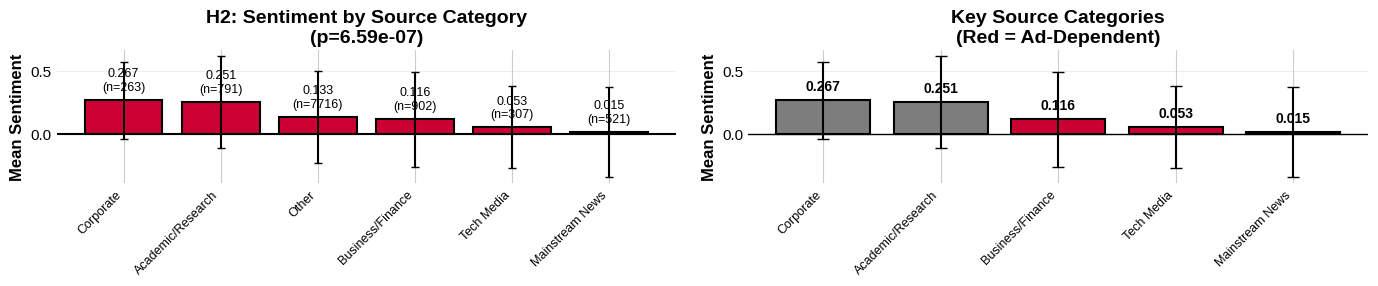


H2 ANALYSIS COMPLETE

Result: SUPPORTED

Key Finding: Both tech and business media are more positive than mainstream
  -> Corporate PR is the MOST positive source, suggesting supply-side bias

Implication: The asymmetry appears to stem more from SUPPLY
(corporate PR provides positive content) than from PRESSURE
(advertisers influencing editorial decisions).


In [ ]:
"""
H2: Advertiser Pressure Analysis
===============================================================

Research Question: Do media outlets dependent on tech advertising show more
positive AI coverage?

Hypothesis: If advertiser pressure drives bias, sources with high tech ad revenue
(business media, tech media) should show more positive sentiment than mainstream
news outlets with diverse revenue streams.

Methodology:
- Compute VADER sentiment analysis on headlines
- Categorize sources by type (Corporate, Academic, Tech Media, Business/Finance,
  Mainstream News, Other)
- Compare mean sentiment (VADER compound) across categories
- Test whether ad-dependent outlets show more positive coverage

Source Categories:
- Corporate: Direct PR from tech companies (Microsoft, Google, IBM, etc.)
- Academic/Research: Peer-reviewed sources (Nature, Frontiers, etc.)
- Tech Media: Tech-focused outlets (TechCrunch, The Verge, Wired, etc.)
- Business/Finance: Business audience (Forbes, CNBC, Bloomberg, etc.)
- Mainstream News: General audience (Guardian, Reuters, BBC, etc.)
"""

# ==============================================================================
# SOURCE CATEGORIZATION
# ==============================================================================
CORPORATE_SOURCES = [
    'Microsoft', 'Amazon Web Services', 'Google', 'IBM', 'Oracle', 'Salesforce',
    'Adobe', 'SAP', 'Intel', 'NVIDIA', 'Meta', 'Apple', 'OpenAI'
]

ACADEMIC_SOURCES = [
    'Nature', 'Frontiers', 'ScienceDirect.com', 'researchgate.net', 'Science',
    'The Conversation', 'MIT Technology Review', 'Stanford', 'Harvard',
    'arXiv', 'PLOS', 'Springer', 'Elsevier', 'Wiley'
]

TECH_MEDIA = [
    'TechCrunch', 'The Verge', 'Wired', 'Ars Technica', 'Engadget', 'Gizmodo',
    'VentureBeat', 'ZDNet', 'CNET', 'IT Brief Australia', 'TechRadar',
    'Silicon Canals', 'TechTarget', '9to5Mac', 'Android Central'
]

BUSINESS_FINANCE = [
    'Forbes', 'Fortune', 'Yahoo Finance', 'Business Insider', 'CNBC',
    'Financial Times', 'The Wall Street Journal', 'Bloomberg', 'AFR',
    'The Motley Fool', 'MarketWatch', 'Barron\'s', 'Investopedia', 'PYMNTS.com'
]

MAINSTREAM_NEWS = [
    'The Guardian', 'Reuters', 'BBC', 'CBC', 'The New York Times', 'NPR',
    'The Washington Post', 'Associated Press', 'The Independent', 'CNN',
    'ABC News', 'NBC News', 'Australian Broadcasting Corporation'
]


def categorize_source(source):
    """Categorize a news source."""
    if pd.isna(source):
        return 'Other'
    source = str(source)

    for corp in CORPORATE_SOURCES:
        if corp.lower() in source.lower():
            return 'Corporate'
    for acad in ACADEMIC_SOURCES:
        if acad.lower() in source.lower():
            return 'Academic/Research'
    for tech in TECH_MEDIA:
        if tech.lower() in source.lower():
            return 'Tech Media'
    for biz in BUSINESS_FINANCE:
        if biz.lower() in source.lower():
            return 'Business/Finance'
    for news in MAINSTREAM_NEWS:
        if news.lower() in source.lower():
            return 'Mainstream News'
    return 'Other'


# ==============================================================================
# SENTIMENT ANALYSIS
# ==============================================================================
def compute_vader_sentiment(df):
    """
    Compute VADER sentiment scores for all headlines.

    VADER (Valence Aware Dictionary and sEntiment Reasoner) is a lexicon and
    rule-based sentiment analysis tool specifically attuned to sentiments
    expressed in social media and news headlines.

    Returns DataFrame with vader_compound and sentiment columns added.
    """
    print("Computing VADER sentiment analysis...")
    sia = SentimentIntensityAnalyzer()

    # Compute compound scores
    df['vader_compound'] = df['title'].apply(
        lambda x: sia.polarity_scores(str(x))['compound'] if pd.notna(x) else 0.0
    )

    # Categorize into positive/neutral/negative
    # Standard VADER thresholds: positive >= 0.05, negative <= -0.05
    def categorize_sentiment(score):
        if score >= 0.05:
            return 'positive'
        elif score <= -0.05:
            return 'negative'
        else:
            return 'neutral'

    df['sentiment'] = df['vader_compound'].apply(categorize_sentiment)

    return df


# ==============================================================================
# DATA LOADING
# ==============================================================================
def load_and_prepare_data(data_path='dataset_A_news_full_10500.csv'):
    """
    Load dataset, compute VADER sentiment, and compute source categorization.

    Returns a DataFrame with sentiment and source_category computed for H2 analysis.
    """
    # Setup style
    setup_matplotlib_style()

    # Ensure figures directory exists
    os.makedirs('figures', exist_ok=True)

    # Load data
    df = pd.read_csv(data_path)

    print(f"Dataset loaded: {len(df):,} headlines")
    print(f"Date range: {df['date'].min()} to {df['date'].max()}")
    print(f"Unique sources: {df['source'].nunique()}")

    # Compute VADER sentiment
    df = compute_vader_sentiment(df)

    print(f"\nSentiment distribution:")
    print(df['sentiment'].value_counts())

    # Compute source categorization
    print("\nCategorizing sources...")
    df['source_category'] = df['source'].apply(categorize_source)

    print("\nSource category distribution:")
    print(df['source_category'].value_counts())

    print("Feature engineering complete!")

    return df


# ==============================================================================
# H2 ANALYSIS
# ==============================================================================
def analyze_h2_advertiser_pressure(df):
    """
    Test H2: Advertiser Pressure Hypothesis.

    Tests whether outlets dependent on tech advertising show more positive coverage.
    """
    print("=" * 70)
    print("H2: ADVERTISER PRESSURE HYPOTHESIS")
    print("=" * 70)
    print("\nHypothesis: Ad-dependent outlets show more positive AI coverage")
    print("Expected: Tech media & business media > mainstream news in sentiment")

    # Sentiment by source category
    source_sentiment = df.groupby('source_category')['vader_compound'].agg(['mean', 'std', 'count'])
    source_sentiment = source_sentiment.sort_values('mean', ascending=False)

    print("\nMean Sentiment by Source Category:")
    print("-" * 60)
    print(source_sentiment.round(4))

    # Key comparisons for H2
    categories = source_sentiment.index.tolist()

    tech_media_sent = source_sentiment.loc['Tech Media', 'mean'] if 'Tech Media' in categories else np.nan
    business_sent = source_sentiment.loc['Business/Finance', 'mean'] if 'Business/Finance' in categories else np.nan
    mainstream_sent = source_sentiment.loc['Mainstream News', 'mean'] if 'Mainstream News' in categories else np.nan
    corporate_sent = source_sentiment.loc['Corporate', 'mean'] if 'Corporate' in categories else np.nan

    print("\n" + "-" * 60)
    print("Key Comparisons (H2 Focus):")
    print("-" * 60)
    print(f"Corporate (PR) sentiment:      {corporate_sent:.4f}")
    print(f"Tech Media sentiment:          {tech_media_sent:.4f}")
    print(f"Business/Finance sentiment:    {business_sent:.4f}")
    print(f"Mainstream News sentiment:     {mainstream_sent:.4f}")

    # Statistical tests
    results = {
        'source_sentiment': source_sentiment,
        'tests': {}
    }

    # Test: Tech Media vs Mainstream
    if 'Tech Media' in categories and 'Mainstream News' in categories:
        tech_vals = df[df['source_category'] == 'Tech Media']['vader_compound']
        mainstream_vals = df[df['source_category'] == 'Mainstream News']['vader_compound']
        t_stat, p_val = stats.ttest_ind(tech_vals, mainstream_vals)
        results['tests']['tech_vs_mainstream'] = {'t': t_stat, 'p': p_val}
        print(f"\nTech Media vs Mainstream: t={t_stat:.4f}, p={p_val:.4f}")

    # Test: Business/Finance vs Mainstream
    if 'Business/Finance' in categories and 'Mainstream News' in categories:
        biz_vals = df[df['source_category'] == 'Business/Finance']['vader_compound']
        mainstream_vals = df[df['source_category'] == 'Mainstream News']['vader_compound']
        t_stat, p_val = stats.ttest_ind(biz_vals, mainstream_vals)
        results['tests']['business_vs_mainstream'] = {'t': t_stat, 'p': p_val}
        print(f"Business vs Mainstream: t={t_stat:.4f}, p={p_val:.4f}")

    # Determine H2 result
    # H2 predicts: tech/business > mainstream (ad pressure creates positive bias)
    tech_more_positive = tech_media_sent > mainstream_sent if not np.isnan(tech_media_sent) else False
    business_more_positive = business_sent > mainstream_sent if not np.isnan(business_sent) else False

    if tech_more_positive and business_more_positive:
        h2_result = "SUPPORTED"
        interpretation = "Both tech and business media are more positive than mainstream"
    elif not tech_more_positive and business_more_positive:
        h2_result = "PARTIAL SUPPORT"
        interpretation = "Business media is more positive, but tech media is NOT"
    elif tech_more_positive and not business_more_positive:
        h2_result = "PARTIAL SUPPORT"
        interpretation = "Tech media is more positive, but business media is NOT"
    else:
        h2_result = "COUNTER-EVIDENCE"
        interpretation = "Neither tech nor business media show positive bias vs mainstream"

    # Refine based on corporate being highest
    if corporate_sent > tech_media_sent and corporate_sent > business_sent:
        interpretation += "\n  -> Corporate PR is the MOST positive source, suggesting supply-side bias"

    results['result'] = h2_result
    results['interpretation'] = interpretation
    results['tech_media_sentiment'] = tech_media_sent
    results['business_sentiment'] = business_sent
    results['mainstream_sentiment'] = mainstream_sent
    results['corporate_sentiment'] = corporate_sent

    print(f"\n{'='*50}")
    print(f"H2 Result: {h2_result}")
    print(f"{'='*50}")
    print(f"\nInterpretation: {interpretation}")

    # Additional insight
    print("\n" + "-" * 60)
    print("Critical Insight:")
    print("-" * 60)
    print("The pattern suggests advertiser pressure may be LESS important than")
    print("corporate PR supply. Corporate sources have the highest sentiment,")
    print("indicating the bias originates from content SUPPLY rather than")
    print("editorial pressure on independent outlets.")

    return results


def visualize_h2(df, results):
    """Create visualization for H2 analysis."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 3))

    # Left: Sentiment by source category (vertical bars)
    ax1 = axes[0]
    source_sent = results['source_sentiment']
    source_sent_plot = source_sent[source_sent['count'] >= 50].sort_values('mean', ascending=False)

    colors = [RUTGERS_SCARLET if m > 0 else RUTGERS_PALETTE['dark_grey']
              for m in source_sent_plot['mean']]

    x = np.arange(len(source_sent_plot))
    bars = ax1.bar(x, source_sent_plot['mean'],
                   yerr=source_sent_plot['std'], capsize=3,
                   color=colors, edgecolor=RUTGERS_BLACK, linewidth=1.5)

    ax1.axhline(y=0, color=RUTGERS_BLACK, linewidth=1.5)
    ax1.set_ylabel('Mean Sentiment', fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(source_sent_plot.index, rotation=45, ha='right', fontsize=9)

    # Get p-value from business vs mainstream test
    p_str = ''
    if 'business_vs_mainstream' in results.get('tests', {}):
        p_val = results['tests']['business_vs_mainstream']['p']
        if p_val < 0.0001:
            p_str = f'(p={p_val:.2e})'
        else:
            p_str = f'(p={p_val:.4f})'
    ax1.set_title(f'H2: Sentiment by Source Category\n{p_str}',
                  fontweight='bold', fontsize=14)
    ax1.grid(axis='y', alpha=0.3)

    # Add value labels
    for bar, (idx, row) in zip(bars, source_sent_plot.iterrows()):
        ax1.annotate(f'{row["mean"]:.3f}\n(n={int(row["count"])})',
                     xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     xytext=(0, 5), textcoords="offset points",
                     ha='center', va='bottom', fontsize=9)

    # Right: Comparison of key categories
    ax2 = axes[1]

    key_categories = ['Corporate', 'Academic/Research', 'Business/Finance', 'Tech Media', 'Mainstream News']
    key_data = []
    for cat in key_categories:
        if cat in source_sent.index:
            key_data.append({
                'category': cat,
                'mean': source_sent.loc[cat, 'mean'],
                'std': source_sent.loc[cat, 'std'],
                'count': source_sent.loc[cat, 'count']
            })

    if key_data:
        cats = [d['category'] for d in key_data]
        means = [d['mean'] for d in key_data]
        stds = [d['std'] for d in key_data]

        # Color by whether it's ad-dependent
        ad_dependent = {'Tech Media', 'Business/Finance'}
        colors2 = [RUTGERS_SCARLET if c in ad_dependent else RUTGERS_PALETTE['medium_grey']
                   for c in cats]

        x = np.arange(len(cats))
        bars2 = ax2.bar(x, means, yerr=stds, capsize=4,
                        color=colors2, edgecolor=RUTGERS_BLACK, linewidth=1.5)

        ax2.set_ylabel('Mean Sentiment', fontweight='bold')
        ax2.set_xticks(x)
        ax2.set_xticklabels(cats, rotation=45, ha='right', fontsize=9)
        ax2.axhline(y=0, color=RUTGERS_BLACK, linewidth=1)
        ax2.set_title('Key Source Categories\n(Red = Ad-Dependent)', fontweight='bold')
        ax2.grid(axis='y', alpha=0.3)

        for bar, mean in zip(bars2, means):
            ax2.annotate(f'{mean:.3f}',
                         xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                         xytext=(0, 5), textcoords="offset points",
                         ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    # plt.savefig('figures/h2_advertiser_pressure.png', dpi=300, bbox_inches='tight')
    plt.show()

    # print("\nFigure saved to: figures/h2_advertiser_pressure.png")


def main():
    """Run complete H2 analysis."""
    print("\n" + "=" * 70)
    print("H2: ADVERTISER PRESSURE ANALYSIS")
    print("=" * 70 + "\n")

    # Load data
    df = load_and_prepare_data()

    # Run analysis
    results = analyze_h2_advertiser_pressure(df)

    # Create visualization
    visualize_h2(df, results)

    # Summary
    print("\n" + "=" * 70)
    print("H2 ANALYSIS COMPLETE")
    print("=" * 70)
    print(f"\nResult: {results['result']}")
    print(f"\nKey Finding: {results['interpretation']}")
    print("\nImplication: The asymmetry appears to stem more from SUPPLY")
    print("(corporate PR provides positive content) than from PRESSURE")
    print("(advertisers influencing editorial decisions).")

    return results


if __name__ == "__main__":
    results = main()

## H3: Ownership Conflicts Analysis


H4: OWNERSHIP CONFLICTS ANALYSIS

Dataset loaded: 10,500 headlines
Date range: 2025-06-14 to 2025-09-11
Unique sources: 3125
Computing VADER sentiment analysis...

Sentiment distribution:
sentiment
positive    4753
neutral     3738
negative    2009
Name: count, dtype: int64

Identifying tech billionaire-owned outlets...
Tech billionaire-owned articles: 455
Feature engineering complete!
H4: OWNERSHIP CONFLICTS HYPOTHESIS

Hypothesis: Tech billionaire-owned outlets show positive AI bias
Expected: Owned outlets > independent outlets in sentiment

--------------------------------------------------
Tech billionaire-owned articles: 455 (4.33%)
Public/Independent articles: 10,045 (95.67%)

--------------------------------------------------
Sentiment by Ownership:
                          mean     std  count
tech_billionaire_owned                       
False                   0.1387  0.3652  10045
True                    0.0691  0.3815    455

-----------------------------------------------

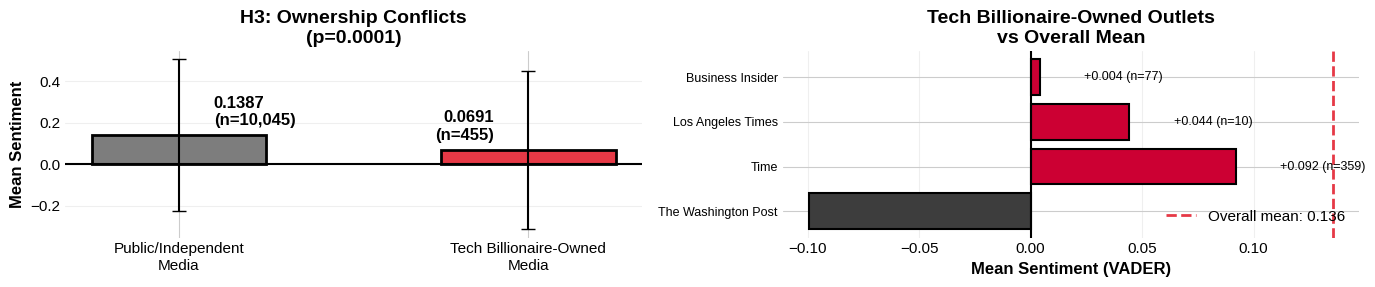


H4 ANALYSIS COMPLETE

Result: COUNTER-EVIDENCE
P-value: 0.0001

Conclusion: Ownership conflicts do NOT explain positive AI bias.
Tech billionaire-owned outlets are actually more critical of AI,
suggesting editorial independence is maintained or owners
encourage skeptical coverage for credibility.

Policy implication: Breaking up tech-owned media would NOT
fix the information asymmetry - the problem lies elsewhere.


In [ ]:
"""
H3: Ownership Conflicts Analysis
================================================================

Research Question: Do media outlets owned by tech billionaires show systematic
positive bias in AI coverage?

Hypothesis: If ownership creates editorial bias, outlets owned by tech
billionaires should show MORE positive sentiment than independent media.

Methodology:
- Compute VADER sentiment analysis on headlines
- Identify outlets owned by tech billionaires
- Compare sentiment between owned vs independent/public outlets
- Use independent samples t-test for statistical significance

Tech Billionaire-Owned Media Tracked:
- The Washington Post (Jeff Bezos, Amazon founder)
- Time (Marc Benioff, Salesforce)
- Los Angeles Times (Patrick Soon-Shiong, tech investor)
- Business Insider (Axel Springer, tech-adjacent)

Counter-Hypothesis: Billionaire owners may actually encourage more independent
editorial coverage to maintain credibility, leading to no bias or even more
critical coverage.
"""

# ==============================================================================
# TECH BILLIONAIRE OWNERSHIP
# ==============================================================================
TECH_BILLIONAIRE_OWNED = [
    'The Washington Post',  # Jeff Bezos
    'Time', 'Los Angeles Times',  # Owned by tech/finance billionaires
    'Business Insider',  # Axel Springer (tech-adjacent)
]


def is_tech_billionaire_owned(source):
    """Check if source is owned by tech billionaire."""
    if pd.isna(source):
        return False
    source = str(source)
    for owned in TECH_BILLIONAIRE_OWNED:
        if owned.lower() in source.lower():
            return True
    return False


# ==============================================================================
# SENTIMENT ANALYSIS
# ==============================================================================
def compute_vader_sentiment(df):
    """
    Compute VADER sentiment scores for all headlines.

    VADER (Valence Aware Dictionary and sEntiment Reasoner) is a lexicon and
    rule-based sentiment analysis tool specifically attuned to sentiments
    expressed in social media and news headlines.

    Returns DataFrame with vader_compound and sentiment columns added.
    """
    print("Computing VADER sentiment analysis...")
    sia = SentimentIntensityAnalyzer()

    # Compute compound scores
    df['vader_compound'] = df['title'].apply(
        lambda x: sia.polarity_scores(str(x))['compound'] if pd.notna(x) else 0.0
    )

    # Categorize into positive/neutral/negative
    # Standard VADER thresholds: positive >= 0.05, negative <= -0.05
    def categorize_sentiment(score):
        if score >= 0.05:
            return 'positive'
        elif score <= -0.05:
            return 'negative'
        else:
            return 'neutral'

    df['sentiment'] = df['vader_compound'].apply(categorize_sentiment)

    return df


# ==============================================================================
# DATA LOADING
# ==============================================================================
def load_and_prepare_data(data_path='dataset_A_news_full_10500.csv'):
    """
    Load dataset, compute VADER sentiment, and compute ownership status.

    Returns a DataFrame with sentiment and tech_billionaire_owned computed for H4 analysis.
    """
    # Setup style
    setup_matplotlib_style()

    # Ensure figures directory exists
    os.makedirs('figures', exist_ok=True)

    # Load data
    df = pd.read_csv(data_path)

    print(f"Dataset loaded: {len(df):,} headlines")
    print(f"Date range: {df['date'].min()} to {df['date'].max()}")
    print(f"Unique sources: {df['source'].nunique()}")

    # Compute VADER sentiment
    df = compute_vader_sentiment(df)

    print(f"\nSentiment distribution:")
    print(df['sentiment'].value_counts())

    # Compute ownership status
    print("\nIdentifying tech billionaire-owned outlets...")
    df['tech_billionaire_owned'] = df['source'].apply(is_tech_billionaire_owned)

    print(f"Tech billionaire-owned articles: {df['tech_billionaire_owned'].sum():,}")

    print("Feature engineering complete!")

    return df


# ==============================================================================
# H4 ANALYSIS
# ==============================================================================
def analyze_h4_ownership(df):
    """
    Test H4: Ownership Conflicts Hypothesis.

    Tests whether tech billionaire-owned outlets show positive AI bias.
    """
    print("=" * 70)
    print("H4: OWNERSHIP CONFLICTS HYPOTHESIS")
    print("=" * 70)
    print("\nHypothesis: Tech billionaire-owned outlets show positive AI bias")
    print("Expected: Owned outlets > independent outlets in sentiment")

    # Ownership breakdown
    owned_count = df['tech_billionaire_owned'].sum()
    total = len(df)
    print(f"\n{'-'*50}")
    print(f"Tech billionaire-owned articles: {owned_count:,} ({owned_count/total*100:.2f}%)")
    print(f"Public/Independent articles: {total - owned_count:,} ({(total-owned_count)/total*100:.2f}%)")

    # Sentiment by ownership
    ownership_sentiment = df.groupby('tech_billionaire_owned')['vader_compound'].agg(['mean', 'std', 'count'])
    print(f"\n{'-'*50}")
    print("Sentiment by Ownership:")
    print(ownership_sentiment.round(4))

    # Get specific values
    owned_sentiment = ownership_sentiment.loc[True, 'mean'] if True in ownership_sentiment.index else np.nan
    independent_sentiment = ownership_sentiment.loc[False, 'mean'] if False in ownership_sentiment.index else np.nan
    owned_n = int(ownership_sentiment.loc[True, 'count']) if True in ownership_sentiment.index else 0
    independent_n = int(ownership_sentiment.loc[False, 'count']) if False in ownership_sentiment.index else 0

    results = {
        'owned_sentiment': owned_sentiment,
        'independent_sentiment': independent_sentiment,
        'owned_n': owned_n,
        'independent_n': independent_n,
        'owned_std': ownership_sentiment.loc[True, 'std'] if True in ownership_sentiment.index else np.nan,
        'independent_std': ownership_sentiment.loc[False, 'std'] if False in ownership_sentiment.index else np.nan
    }

    # Statistical test (if sufficient data)
    if owned_n >= 10 and independent_n >= 10:
        owned_vals = df[df['tech_billionaire_owned'] == True]['vader_compound']
        independent_vals = df[df['tech_billionaire_owned'] == False]['vader_compound']

        t_stat, p_value = stats.ttest_ind(owned_vals, independent_vals)

        # Effect size
        pooled_std = np.sqrt((owned_vals.std()**2 + independent_vals.std()**2) / 2)
        cohens_d = (owned_vals.mean() - independent_vals.mean()) / pooled_std

        results['t_stat'] = t_stat
        results['p_value'] = p_value
        results['cohens_d'] = cohens_d

        print(f"\n{'-'*50}")
        print("Statistical Test Results:")
        print(f"T-test: t={t_stat:.4f}, p={p_value:.4f}")
        print(f"Effect size (Cohen's d): {cohens_d:.4f}")

        # Determine result
        if p_value < 0.05:
            if owned_sentiment > independent_sentiment:
                h4_result = "SUPPORTED"
                interpretation = "Tech billionaire-owned outlets ARE more positive"
            else:
                h4_result = "COUNTER-EVIDENCE"
                interpretation = "Tech billionaire-owned outlets are LESS positive"
        elif p_value < 0.1:
            if owned_sentiment > independent_sentiment:
                h4_result = "WEAK SUPPORT"
            else:
                h4_result = "WEAK COUNTER-EVIDENCE"
            interpretation = f"Marginally significant difference (p={p_value:.4f})"
        else:
            h4_result = "NO SUPPORT"
            interpretation = "No significant difference based on ownership"
    else:
        h4_result = "INSUFFICIENT DATA"
        interpretation = f"Not enough owned outlet articles (n={owned_n})"
        results['t_stat'] = np.nan
        results['p_value'] = np.nan
        results['cohens_d'] = np.nan

    results['result'] = h4_result
    results['interpretation'] = interpretation

    print(f"\n{'='*50}")
    print(f"H4 Result: {h4_result}")
    print(f"{'='*50}")
    print(f"\nTech billionaire-owned sentiment: {owned_sentiment:.4f} (n={owned_n})")
    print(f"Public/Independent sentiment:     {independent_sentiment:.4f} (n={independent_n})")
    print(f"Difference: {owned_sentiment - independent_sentiment:.4f}")
    print(f"\nInterpretation: {interpretation}")

    # Breakdown by specific outlet
    print(f"\n{'-'*50}")
    print("Sentiment by Specific Owned Outlet:")
    print("-" * 50)

    outlet_sentiments = []
    for outlet in TECH_BILLIONAIRE_OWNED:
        mask = df['source'].str.contains(outlet, case=False, na=False)
        if mask.sum() > 0:
            mean_sent = df.loc[mask, 'vader_compound'].mean()
            count = mask.sum()
            outlet_sentiments.append({
                'outlet': outlet,
                'sentiment': mean_sent,
                'count': count
            })
            print(f"  {outlet:25} sentiment: {mean_sent:+.4f} (n={count})")

    results['outlet_breakdown'] = outlet_sentiments

    # Compare to overall mean
    overall_mean = df['vader_compound'].mean()
    print(f"\n  Overall dataset mean: {overall_mean:.4f}")

    # Critical insight
    if h4_result in ["COUNTER-EVIDENCE", "WEAK COUNTER-EVIDENCE"]:
        print(f"\n{'-'*50}")
        print("Critical Insight:")
        print("-" * 50)
        print("Tech billionaire-owned outlets are actually MORE critical of AI,")
        print("not less. This may indicate:")
        print("  1. Editorial independence is maintained despite ownership")
        print("  2. Owners may encourage skeptical coverage to build credibility")
        print("  3. Ownership conflicts are NOT a major driver of positive bias")

    return results


def visualize_h4(df, results):
    """Create visualization for H3 analysis."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 3))

    # Left: Main comparison
    ax1 = axes[0]
    categories = ['Public/Independent\nMedia', 'Tech Billionaire-Owned\nMedia']
    means = [results['independent_sentiment'], results['owned_sentiment']]
    stds = [results['independent_std'], results['owned_std']]
    counts = [results['independent_n'], results['owned_n']]

    colors = [RUTGERS_PALETTE['medium_grey'], RUTGERS_PALETTE['medium_scarlet']]
    bars = ax1.bar(categories, means, yerr=stds, capsize=5,
                   color=colors, edgecolor=RUTGERS_BLACK, linewidth=2, width=0.5)

    ax1.axhline(y=0, color=RUTGERS_BLACK, linewidth=1.5)
    ax1.set_ylabel('Mean Sentiment', fontweight='bold')

    p_str = f'p={results["p_value"]:.4f}' if not np.isnan(results.get('p_value', np.nan)) else 'insufficient data'
    ax1.set_title(f'H3: Ownership Conflicts\n({p_str})',
                  fontweight='bold', fontsize=14)
    ax1.grid(axis='y', alpha=0.3)

    # Position labels to the side of bars to avoid error bar overlap
    for i, (bar, mean, count) in enumerate(zip(bars, means, counts)):
        # Offset text to the right of the bar
        x_offset = 25 if i == 0 else -25
        ha = 'left' if i == 0 else 'right'
        ax1.annotate(f'{mean:.4f}\n(n={count:,})',
                     xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     xytext=(x_offset, 5), textcoords="offset points",
                     ha=ha, va='bottom', fontsize=12, fontweight='bold')

    # Right: Specific outlet breakdown
    ax2 = axes[1]

    if results['outlet_breakdown']:
        outlets = [d['outlet'] for d in results['outlet_breakdown']]
        sentiments = [d['sentiment'] for d in results['outlet_breakdown']]
        counts = [d['count'] for d in results['outlet_breakdown']]

        # Add overall mean for comparison
        overall_mean = df['vader_compound'].mean()

        y_pos = np.arange(len(outlets))
        colors2 = [RUTGERS_SCARLET if s > 0 else RUTGERS_PALETTE['dark_grey'] for s in sentiments]

        bars2 = ax2.barh(y_pos, sentiments, color=colors2,
                         edgecolor=RUTGERS_BLACK, linewidth=1.5)

        ax2.set_yticks(y_pos)
        ax2.set_yticklabels(outlets, fontsize=9)
        ax2.set_xlabel('Mean Sentiment (VADER)', fontweight='bold')
        ax2.set_title('Tech Billionaire-Owned Outlets\nvs Overall Mean', fontweight='bold')
        ax2.axvline(x=0, color=RUTGERS_BLACK, linewidth=1.5)
        ax2.axvline(x=overall_mean, color=RUTGERS_PALETTE['medium_scarlet'],
                    linewidth=2, linestyle='--', label=f'Overall mean: {overall_mean:.3f}')
        ax2.legend(loc='lower right')
        ax2.grid(axis='x', alpha=0.3)

        for bar, sent, count in zip(bars2, sentiments, counts):
            label_x = sent + 0.02 if sent >= 0 else sent - 0.02
            ha = 'left' if sent >= 0 else 'right'
            ax2.annotate(f'{sent:+.3f} (n={count})',
                         xy=(label_x, bar.get_y() + bar.get_height()/2),
                         ha=ha, va='center', fontsize=9)
    else:
        ax2.text(0.5, 0.5, 'Insufficient data\nfor outlet breakdown',
                 ha='center', va='center', fontsize=14,
                 transform=ax2.transAxes, color=RUTGERS_PALETTE['medium_grey'])
        ax2.axis('off')

    plt.tight_layout()
    # plt.savefig('figures/h3_ownership_conflicts.png', dpi=300, bbox_inches='tight')
    plt.show()

    # print("\nFigure saved to: figures/h3_ownership_conflicts.png")


def main():
    """Run complete H4 analysis."""
    print("\n" + "=" * 70)
    print("H4: OWNERSHIP CONFLICTS ANALYSIS")
    print("=" * 70 + "\n")

    # Load data
    df = load_and_prepare_data()

    # Run analysis
    results = analyze_h4_ownership(df)

    # Create visualization
    visualize_h4(df, results)

    # Summary
    print("\n" + "=" * 70)
    print("H4 ANALYSIS COMPLETE")
    print("=" * 70)
    print(f"\nResult: {results['result']}")

    if not np.isnan(results.get('p_value', np.nan)):
        print(f"P-value: {results['p_value']:.4f}")

    if results['result'] in ["COUNTER-EVIDENCE", "WEAK COUNTER-EVIDENCE"]:
        print("\nConclusion: Ownership conflicts do NOT explain positive AI bias.")
        print("Tech billionaire-owned outlets are actually more critical of AI,")
        print("suggesting editorial independence is maintained or owners")
        print("encourage skeptical coverage for credibility.")
        print("\nPolicy implication: Breaking up tech-owned media would NOT")
        print("fix the information asymmetry - the problem lies elsewhere.")

    return results


if __name__ == "__main__":
    results = main()

## H4: Narrative Complexity Analysis


PILLAR 4: THE BROKEN MIRROR
H5: COMPLEXITY ASYMMETRY ANALYSIS (KEY FINDING)

Dataset loaded: 10,500 headlines
Date range: 2025-06-14 to 2025-09-11
Unique sources: 3125
Computing VADER sentiment analysis...

Sentiment distribution:
sentiment
positive    4753
neutral     3738
negative    2009
Name: count, dtype: int64

Computing complexity metrics...
Feature engineering complete!
H5: COMPLEXITY ASYMMETRY (KEY FINDING)

Hypothesis: Negative headlines are structurally more complex
Expected: Negative > Positive in abstract language, hedging, complexity

--------------------------------------------------
Sample sizes:
  Positive: 4,753
  Neutral:  3,738
  Negative: 2,009

------------------------------------------------------------
Complexity Metrics Comparison:
------------------------------------------------------------
Metric                        Positive     Negative       Diff
------------------------------------------------------------
Complexity Score                 0.162        0

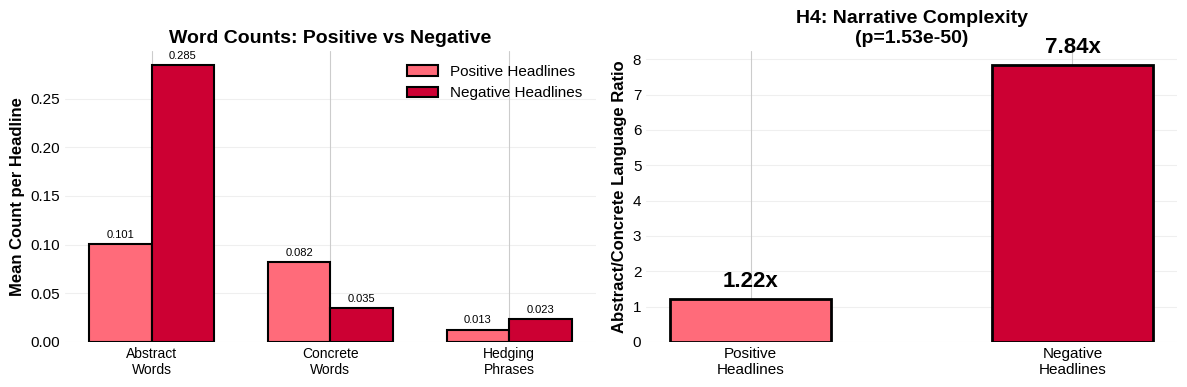


Figure saved to: figures/h4_complexity_asymmetry.png

H5 ANALYSIS COMPLETE - KEY FINDING

Result: STRONG SUPPORT
P-value: 0.000000
Effect size (Cohen's d): 0.3688

Abstract/Concrete ratio multiplier: 6.4x

----------------------------------------------------------------------
CONCLUSION: THE PHYSICS OF NARRATIVE
----------------------------------------------------------------------

The broken mirror is NOT broken by malice - it's broken by structure.

1. Positive stories are STRUCTURALLY simpler
2. Simple stories compress into tweets, shares, re-reports
3. Complex stories resist compression
4. This creates inherent propagation asymmetry

POLICY IMPLICATION:
To fix the mirror, we need NEW FORMATS for complex stories,
not just more "ethical" journalism.
    


In [ ]:
"""
H4: Narrative Complexity Asymmetry Analysis (KEY FINDING)
===============================================================================

Research Question: Are negative AI stories structurally more complex, making
them inherently harder to share and propagate?

Hypothesis: If complexity asymmetry exists, negative headlines should have
MORE abstract language, hedging phrases, and complex structures than positive
headlines, explaining propagation differences without invoking editorial bias.

THIS IS THE CENTRAL FINDING OF THE BROKEN MIRROR ANALYSIS

Theoretical Foundation:
- Dual Coding Theory (Paivio, 1986): Concrete words create mental images,
  making them more memorable and shareable
- Processing Fluency: Simpler content is processed faster and preferred
- Compression Problem: Complex content doesn't fit tweet/headline formats

Key Metrics:
1. Abstract Language: could, might, potentially, concerns, implications, etc.
2. Concrete Language: launches, announces, acquires, builds, delivers, etc.
3. Abstract/Concrete Ratio: Key measure of structural complexity
4. Hedging Phrases: "if", "whether", "could be", "raises questions", etc.
5. Complexity Score: Weighted combination of all factors

Why This Matters:
- "Google launches new AI" fits a tweet easily
- "AI could potentially displace workers if economic conditions..." doesn't
- The mirror is broken by PHYSICS of narrative, not conspiracy
"""

# ==============================================================================
# COMPLEXITY METRICS
# ==============================================================================
# Abstract language indicators
ABSTRACT_WORDS = [
    'could', 'might', 'may', 'potentially', 'possibly', 'perhaps', 'likely',
    'suggests', 'indicates', 'implies', 'appears', 'seems', 'tends',
    'concerns', 'raises', 'questions', 'uncertainty', 'risk', 'threat',
    'implications', 'consequences', 'impact', 'effects', 'influence',
    'theoretical', 'conceptual', 'hypothetical', 'speculative'
]

# Concrete language indicators
CONCRETE_WORDS = [
    'launches', 'announces', 'releases', 'unveils', 'introduces', 'debuts',
    'acquires', 'buys', 'sells', 'hires', 'fires', 'raises', 'invests',
    'builds', 'creates', 'develops', 'ships', 'delivers', 'partners',
    'opens', 'closes', 'expands', 'reports', 'confirms', 'wins', 'loses'
]

# Hedging/conditional phrases
HEDGING_PHRASES = [
    'if ', 'whether', 'could be', 'might be', 'may be', 'appears to',
    'seems to', 'is expected', 'is likely', 'is possible', 'raises questions',
    'remains to be seen', 'it depends', 'under certain', 'in some cases'
]


def compute_complexity_metrics(title):
    """Compute linguistic complexity metrics for a headline."""
    if pd.isna(title):
        return {'abstract_count': 0, 'concrete_count': 0, 'hedging_count': 0,
                'word_count': 0, 'avg_word_length': 0}

    title = str(title).lower()
    words = title.split()

    # Count abstract and concrete words
    abstract_count = sum(1 for word in ABSTRACT_WORDS if word in title)
    concrete_count = sum(1 for word in CONCRETE_WORDS if word in title)

    # Count hedging phrases
    hedging_count = sum(1 for phrase in HEDGING_PHRASES if phrase in title)

    # Word count and average word length
    word_count = len(words)
    avg_word_length = np.mean([len(w) for w in words]) if words else 0

    return {
        'abstract_count': abstract_count,
        'concrete_count': concrete_count,
        'hedging_count': hedging_count,
        'word_count': word_count,
        'avg_word_length': avg_word_length
    }


# ==============================================================================
# SENTIMENT ANALYSIS
# ==============================================================================
def compute_vader_sentiment(df):
    """
    Compute VADER sentiment scores for all headlines.

    VADER (Valence Aware Dictionary and sEntiment Reasoner) is a lexicon and
    rule-based sentiment analysis tool specifically attuned to sentiments
    expressed in social media and news headlines.

    Returns DataFrame with vader_compound and sentiment columns added.
    """
    print("Computing VADER sentiment analysis...")
    sia = SentimentIntensityAnalyzer()

    # Compute compound scores
    df['vader_compound'] = df['title'].apply(
        lambda x: sia.polarity_scores(str(x))['compound'] if pd.notna(x) else 0.0
    )

    # Categorize into positive/neutral/negative
    # Standard VADER thresholds: positive >= 0.05, negative <= -0.05
    def categorize_sentiment(score):
        if score >= 0.05:
            return 'positive'
        elif score <= -0.05:
            return 'negative'
        else:
            return 'neutral'

    df['sentiment'] = df['vader_compound'].apply(categorize_sentiment)

    return df


# ==============================================================================
# DATA LOADING
# ==============================================================================
def load_and_prepare_data(data_path='dataset_A_news_full_10500.csv'):
    """
    Load dataset, compute VADER sentiment, and compute complexity metrics.

    Returns a DataFrame with sentiment and complexity metrics computed for H5 analysis.
    """
    # Setup style
    setup_matplotlib_style()

    # Ensure figures directory exists
    os.makedirs('figures', exist_ok=True)

    # Load data
    df = pd.read_csv(data_path)

    print(f"Dataset loaded: {len(df):,} headlines")
    print(f"Date range: {df['date'].min()} to {df['date'].max()}")
    print(f"Unique sources: {df['source'].nunique()}")

    # Compute VADER sentiment
    df = compute_vader_sentiment(df)

    print(f"\nSentiment distribution:")
    print(df['sentiment'].value_counts())

    # Compute complexity metrics
    print("\nComputing complexity metrics...")
    complexity_metrics = df['title'].apply(compute_complexity_metrics).apply(pd.Series)
    df = pd.concat([df, complexity_metrics], axis=1)

    # Compute complexity score (normalized)
    df['complexity_score'] = (
        df['abstract_count'] * 0.4 +
        df['hedging_count'] * 0.4 +
        df['avg_word_length'] / 10 * 0.2
    )

    # Binary indicators
    df['has_abstract'] = df['abstract_count'] > 0
    df['has_concrete'] = df['concrete_count'] > 0

    print("Feature engineering complete!")

    return df


# ==============================================================================
# H5 ANALYSIS
# ==============================================================================
def analyze_h5_complexity(df):
    """
    Test H5: Complexity Asymmetry Hypothesis.

    This is the KEY FINDING - tests whether negative news is structurally
    harder to share due to linguistic complexity.
    """
    print("=" * 70)
    print("H5: COMPLEXITY ASYMMETRY (KEY FINDING)")
    print("=" * 70)
    print("\nHypothesis: Negative headlines are structurally more complex")
    print("Expected: Negative > Positive in abstract language, hedging, complexity")

    # Separate positive and negative headlines
    positive_df = df[df['sentiment'] == 'positive']
    negative_df = df[df['sentiment'] == 'negative']
    neutral_df = df[df['sentiment'] == 'neutral']

    print(f"\n{'-'*50}")
    print(f"Sample sizes:")
    print(f"  Positive: {len(positive_df):,}")
    print(f"  Neutral:  {len(neutral_df):,}")
    print(f"  Negative: {len(negative_df):,}")

    # Compare all complexity metrics
    metrics = {
        'Complexity Score': ('complexity_score', 'mean'),
        'Abstract Language %': ('has_abstract', lambda x: x.mean() * 100),
        'Concrete Language %': ('has_concrete', lambda x: x.mean() * 100),
        'Hedging Phrases (mean)': ('hedging_count', 'mean'),
        'Avg Word Length': ('avg_word_length', 'mean'),
        'Abstract Count (mean)': ('abstract_count', 'mean'),
        'Concrete Count (mean)': ('concrete_count', 'mean'),
    }

    print(f"\n{'-'*60}")
    print("Complexity Metrics Comparison:")
    print("-" * 60)
    print(f"{'Metric':<25} {'Positive':>12} {'Negative':>12} {'Diff':>10}")
    print("-" * 60)

    results = {'metrics': {}}
    for metric_name, (col, agg) in metrics.items():
        if callable(agg):
            pos_val = agg(positive_df[col])
            neg_val = agg(negative_df[col])
        else:
            pos_val = positive_df[col].agg(agg)
            neg_val = negative_df[col].agg(agg)

        diff = neg_val - pos_val
        diff_pct = (neg_val / pos_val - 1) * 100 if pos_val != 0 else np.inf

        results['metrics'][metric_name] = {
            'positive': pos_val,
            'negative': neg_val,
            'difference': diff
        }

        print(f"{metric_name:<25} {pos_val:>12.3f} {neg_val:>12.3f} {diff:>+10.3f}")

    # KEY METRIC: Abstract/Concrete Ratio
    print(f"\n{'-'*60}")
    print("KEY METRIC: Abstract/Concrete Ratio")
    print("-" * 60)

    pos_abstract = positive_df['has_abstract'].mean()
    pos_concrete = positive_df['has_concrete'].mean()
    neg_abstract = negative_df['has_abstract'].mean()
    neg_concrete = negative_df['has_concrete'].mean()

    pos_ratio = pos_abstract / pos_concrete if pos_concrete > 0 else np.inf
    neg_ratio = neg_abstract / neg_concrete if neg_concrete > 0 else np.inf
    ratio_multiplier = neg_ratio / pos_ratio if pos_ratio > 0 else np.inf

    results['abstract_concrete'] = {
        'pos_abstract_pct': pos_abstract * 100,
        'pos_concrete_pct': pos_concrete * 100,
        'neg_abstract_pct': neg_abstract * 100,
        'neg_concrete_pct': neg_concrete * 100,
        'pos_ratio': pos_ratio,
        'neg_ratio': neg_ratio,
        'ratio_multiplier': ratio_multiplier
    }

    print(f"\nPositive headlines:")
    print(f"  Abstract language: {pos_abstract*100:.1f}%")
    print(f"  Concrete language: {pos_concrete*100:.1f}%")
    print(f"  Ratio: {pos_ratio:.2f}")

    print(f"\nNegative headlines:")
    print(f"  Abstract language: {neg_abstract*100:.1f}%")
    print(f"  Concrete language: {neg_concrete*100:.1f}%")
    print(f"  Ratio: {neg_ratio:.2f}")

    print(f"\n>>> Negative headlines have {ratio_multiplier:.1f}x higher abstract/concrete ratio <<<")

    # Statistical test on complexity score
    t_stat, p_value = stats.ttest_ind(
        positive_df['complexity_score'],
        negative_df['complexity_score']
    )

    # Effect size
    pooled_std = np.sqrt(
        (positive_df['complexity_score'].std()**2 +
         negative_df['complexity_score'].std()**2) / 2
    )
    cohens_d = (negative_df['complexity_score'].mean() -
                positive_df['complexity_score'].mean()) / pooled_std

    results['t_stat'] = t_stat
    results['p_value'] = p_value
    results['cohens_d'] = cohens_d

    print(f"\n{'-'*50}")
    print("Statistical Test (Complexity Score):")
    print(f"T-test: t={t_stat:.4f}, p={p_value:.6f}")
    print(f"Effect size (Cohen's d): {cohens_d:.4f}")

    # Determine result
    if p_value < 0.001 and negative_df['complexity_score'].mean() > positive_df['complexity_score'].mean():
        h5_result = "STRONG SUPPORT"
    elif p_value < 0.05 and negative_df['complexity_score'].mean() > positive_df['complexity_score'].mean():
        h5_result = "SUPPORTED"
    elif p_value < 0.1:
        h5_result = "MODERATE SUPPORT"
    else:
        h5_result = "NO SUPPORT"

    results['result'] = h5_result

    print(f"\n{'='*60}")
    print(f"H5 Result: {h5_result}")
    print(f"{'='*60}")

    # Example headlines
    print(f"\n{'-'*60}")
    print("Example Headlines Illustrating Complexity Difference:")
    print("-" * 60)

    print("\nTypical POSITIVE headlines (concrete, simple):")
    pos_examples = positive_df[positive_df['concrete_count'] > 0]['title'].head(3)
    for i, ex in enumerate(pos_examples, 1):
        print(f"  {i}. {ex[:80]}...")

    print("\nTypical NEGATIVE headlines (abstract, hedged):")
    neg_examples = negative_df[negative_df['abstract_count'] > 0]['title'].head(3)
    for i, ex in enumerate(neg_examples, 1):
        print(f"  {i}. {ex[:80]}...")

    # The core insight
    print(f"\n{'-'*60}")
    print("THE CORE INSIGHT:")
    print("-" * 60)
    print("""
The mirror is broken by STRUCTURE, not conspiracy:

1. POSITIVE stories use concrete action verbs:
   "launches", "announces", "unveils", "acquires"
   -> Easy to share, retweet, re-report

2. NEGATIVE stories require abstract hedging:
   "could", "might", "raises concerns", "potentially"
   -> Hard to compress into shareable format

3. This creates INHERENT propagation asymmetry:
   - Simple stories travel faster
   - Complex stories stay contained
   - No editorial bias needed to explain the pattern
""")

    return results


def visualize_h5(df, results):
    """Create visualization for H4 analysis."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    positive_df = df[df['sentiment'] == 'positive']
    negative_df = df[df['sentiment'] == 'negative']

    # Left: Bar chart of absolute word counts
    ax1 = axes[0]
    metric_names = ['Abstract\nWords', 'Concrete\nWords', 'Hedging\nPhrases']

    # Calculate mean counts for positive and negative
    pos_vals = [
        positive_df['abstract_count'].mean(),
        positive_df['concrete_count'].mean(),
        positive_df['hedging_count'].mean()
    ]
    neg_vals = [
        negative_df['abstract_count'].mean(),
        negative_df['concrete_count'].mean(),
        negative_df['hedging_count'].mean()
    ]

    x = np.arange(len(metric_names))
    width = 0.35

    bars1 = ax1.bar(x - width/2, pos_vals, width, label='Positive Headlines',
                    color=RUTGERS_PALETTE['light_scarlet'], edgecolor=RUTGERS_BLACK, linewidth=1.5)
    bars2 = ax1.bar(x + width/2, neg_vals, width, label='Negative Headlines',
                    color=RUTGERS_SCARLET, edgecolor=RUTGERS_BLACK, linewidth=1.5)

    ax1.set_ylabel('Mean Count per Headline', fontweight='bold')
    ax1.set_title('Word Counts: Positive vs Negative', fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(metric_names, fontsize=10)
    ax1.legend(loc='upper right')
    ax1.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for bar, val in zip(bars1, pos_vals):
        ax1.annotate(f'{val:.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)
    for bar, val in zip(bars2, neg_vals):
        ax1.annotate(f'{val:.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

    # Right: Abstract/Concrete Ratio (KEY VISUAL)
    ax2 = axes[1]
    ratio_labels = ['Positive\nHeadlines', 'Negative\nHeadlines']
    ratios = [results['abstract_concrete']['pos_ratio'],
              results['abstract_concrete']['neg_ratio']]

    bars = ax2.bar(ratio_labels, ratios,
                   color=[RUTGERS_PALETTE['light_scarlet'], RUTGERS_SCARLET],
                   edgecolor=RUTGERS_BLACK, linewidth=2, width=0.5)

    ax2.set_ylabel('Abstract/Concrete Language Ratio', fontweight='bold')
    p_val = results["p_value"]
    p_str = f'p={p_val:.2e}' if p_val < 0.0001 else f'p={p_val:.4f}'
    ax2.set_title(f'H4: Narrative Complexity\n({p_str})', fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)

    for bar, ratio in zip(bars, ratios):
        ax2.annotate(f'{ratio:.2f}x',
                     xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     xytext=(0, 5), textcoords="offset points",
                     ha='center', va='bottom', fontsize=16, fontweight='bold')

    # Add ratio multiplier annotation
    ax2.annotate(f'{results["abstract_concrete"]["ratio_multiplier"]:.1f}x\nmore\nabstract!',
                 xy=(1, ratios[1] * 0.7), fontsize=14,
                 color=RUTGERS_SCARLET, fontweight='bold', ha='center')

    plt.tight_layout()
    plt.savefig('figures/h4_complexity_asymmetry.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\nFigure saved to: figures/h4_complexity_asymmetry.png")


def main():
    """Run complete H5 analysis."""
    print("\n" + "=" * 70)
    print("PILLAR 4: THE BROKEN MIRROR")
    print("H5: COMPLEXITY ASYMMETRY ANALYSIS (KEY FINDING)")
    print("=" * 70 + "\n")

    # Load data
    df = load_and_prepare_data()

    # Run analysis
    results = analyze_h5_complexity(df)

    # Create visualization
    visualize_h5(df, results)

    # Summary
    print("\n" + "=" * 70)
    print("H5 ANALYSIS COMPLETE - KEY FINDING")
    print("=" * 70)
    print(f"\nResult: {results['result']}")
    print(f"P-value: {results['p_value']:.6f}")
    print(f"Effect size (Cohen's d): {results['cohens_d']:.4f}")
    print(f"\nAbstract/Concrete ratio multiplier: {results['abstract_concrete']['ratio_multiplier']:.1f}x")

    print("\n" + "-" * 70)
    print("CONCLUSION: THE PHYSICS OF NARRATIVE")
    print("-" * 70)
    print("""
The broken mirror is NOT broken by malice - it's broken by structure.

1. Positive stories are STRUCTURALLY simpler
2. Simple stories compress into tweets, shares, re-reports
3. Complex stories resist compression
4. This creates inherent propagation asymmetry

POLICY IMPLICATION:
To fix the mirror, we need NEW FORMATS for complex stories,
not just more "ethical" journalism.
    """)

    return results


if __name__ == "__main__":
    results = main()

# Verification
## LLM Semantic Audit

---

### Research Question
Does media coverage of AI systematically distort public perception by amplifying benefits and containing risks?

### Methodology: Two-Stage LLM Semantic Audit

We employ a **Large Language Model (LLM)-based semantic analysis** approach to classify 10,500 AI news headlines across multiple dimensions. Unlike traditional NLP methods (keyword matching, lexicon-based sentiment), LLMs provide:

- **Contextual Understanding**: Captures nuance, irony, and implicit framing that rule-based systems miss
- **Multi-dimensional Classification**: Simultaneously extracts sentiment, framing, tone, themes, and bias indicators
- **Consistency**: Predefined taxonomy ensures standardized, quantifiable outputs

#### Stage 1: Micro-level Classification
Each headline is analyzed by `Llama-3.1-8B-Instruct` using a structured prompt with predefined categories:

| Dimension | Categories |
|-----------|------------|
| **Sentiment** | positive, negative, neutral (score: -1 to +1) |
| **Framing** | opportunity, threat, solution, disruption, hype, critical, neutral |
| **Tone** | measured, sensational, alarming, optimistic, technical |
| **Bias Indicators** | corporate_promotion, fear_mongering, tech_utopia, balanced |
| **Themes** | innovation, regulation, ethics, job_displacement, investment, etc. |

#### Stage 2: Macro-level Interpretation
Aggregated statistics are fed back to the LLM for deeper pattern analysis:
- Root cause analysis (corporate PR, cognitive bias, clickbait economics)
- Consequences for public understanding
- Policy recommendations

### Data Sources
- **Dataset**: 10,500 AI-related news headlines from diverse media sources
- **Model**: Hugging Face Inference API (`meta-llama/Llama-3.1-8B-Instruct:cerebras`)
- **Pre-computed Results**: Available via Google Drive for reproducibility

---

In [ ]:
!pip install -q gdown openai python-dotenv tqdm seaborn

In [ ]:
# Import dependencies
import pandas as pd
import numpy as np
import json
import os
import time
import re
from collections import Counter
import pickle
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime
from pathlib import Path

import gdown
from openai import OpenAI
from tqdm.notebook import tqdm
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns

print("Dependencies loaded successfully")

Dependencies loaded successfully


In [ ]:
# Path configuration
SCRIPT_DIR = Path('.').resolve()

# Google Drive file IDs
GDRIVE_FILES = {
    'dataset': '1zus2jv9uvNKv7SiRG4q_GEVs4lX6ODRq',
    'results': '1kz7l5Z5xzIs8qxYhMHocdummseFndbF7',
    'interpretation': '1VLmPUlkDup8zsCnacDNyuztQmuk7KAug'
}

# File paths
DATA_FILE = SCRIPT_DIR / 'dataset_A_news_full_10500.csv'
CHECKPOINT_FILE = SCRIPT_DIR / 'llm_analysis_hf_checkpoint.pkl'
OUTPUT_CSV = SCRIPT_DIR / 'headline_analysis_hf_results.csv'
OUTPUT_JSON = SCRIPT_DIR / 'headline_analysis_hf_results.json'
STATS_FILE = SCRIPT_DIR / 'headline_analysis_hf_statistics.json'
INTERPRETATION_FILE = SCRIPT_DIR / 'deep_interpretation_results.txt'
VIZ_DIR = SCRIPT_DIR / 'visualizations_hf_story'

# Create output directory
VIZ_DIR.mkdir(exist_ok=True)

# Download files from Google Drive if not exist locally
def download_from_gdrive(file_id, output_path):
    """Download file from Google Drive"""
    url = f'https://drive.google.com/uc?id={file_id}'
    print(f"Downloading from Google Drive: {output_path.name}")
    gdown.download(url, str(output_path), quiet=False)
    print(f"✓ Downloaded: {output_path.name}")

# Download dataset if not exists
if not DATA_FILE.exists():
    download_from_gdrive(GDRIVE_FILES['dataset'], DATA_FILE)
else:
    print(f"Dataset already exists: {DATA_FILE.name}")

# Download pre-computed results if not exists
if not OUTPUT_CSV.exists():
    download_from_gdrive(GDRIVE_FILES['results'], OUTPUT_CSV)
else:
    print(f"Results already exists: {OUTPUT_CSV.name}")

# Download deep interpretation if not exists
if not INTERPRETATION_FILE.exists():
    download_from_gdrive(GDRIVE_FILES['interpretation'], INTERPRETATION_FILE)
else:
    print(f"Interpretation already exists: {INTERPRETATION_FILE.name}")

print(f"\nData file: {DATA_FILE}")
print(f"Results file: {OUTPUT_CSV}")
print(f"Interpretation file: {INTERPRETATION_FILE}")
print(f"Visualization directory: {VIZ_DIR}")

Dataset already exists: dataset_A_news_full_10500.csv


Downloading...
From: https://drive.google.com/uc?id=1kz7l5Z5xzIs8qxYhMHocdummseFndbF7
To: /content/headline_analysis_hf_results.csv
100%|██████████| 6.02M/6.02M [00:00<00:00, 73.6MB/s]


✓ Downloaded: headline_analysis_hf_results.csv


Downloading...
From: https://drive.google.com/uc?id=1VLmPUlkDup8zsCnacDNyuztQmuk7KAug
To: /content/deep_interpretation_results.txt
100%|██████████| 5.57k/5.57k [00:00<00:00, 2.70MB/s]

✓ Downloaded: deep_interpretation_results.txt

Data file: /content/dataset_A_news_full_10500.csv
Results file: /content/headline_analysis_hf_results.csv
Interpretation file: /content/deep_interpretation_results.txt
Visualization directory: /content/visualizations_hf_story


### Notice
In this notebook we are using our LLM processed (*meta-llama/Llama-3.1-8B-Instructl*) dataset becuase rerun the LLM dataset preprocess pipeline will cost hours and bring additional cost, if you want to rerun this pipline by your self, plase first delete the dataset that previous code block downloaded and set your own hugging face api key in the colab sercet after 'HF_TOKEN'

In [ ]:
import os

try:
    from google.colab import userdata
    HF_TOKEN = userdata.get('HF_TOKEN')
    os.environ['HF_TOKEN'] = HF_TOKEN
    print("HF_TOKEN loaded from Colab secrets")
except Exception as e:
    HF_TOKEN = None
    print("HF_TOKEN not available, continuing without it")

# Initialize client
client = OpenAI(
    base_url="https://router.huggingface.co/v1",
    api_key=HF_TOKEN or "DUMMY_KEY",
)

# Analysis configuration
CONFIG = {
    'model': 'meta-llama/Llama-3.1-8B-Instruct:cerebras',
    'max_workers': 10,
    'save_interval': 200,
    'max_retries': 3,
    'temperature': 0.1,
    'max_tokens': 600,
    'rate_limit_delay': 0.1,
}

print(f"API configuration complete")
print(f"Model: {CONFIG['model']}")

HF_TOKEN not available, continuing without it
API configuration complete
Model: meta-llama/Llama-3.1-8B-Instruct:cerebras


## LLM Analysis

If `headline_analysis_hf_results.csv` already exists, the API call step will be skipped.

In [ ]:
# Analysis prompt
ANALYSIS_PROMPT = """You are an expert media analyst specializing in AI news coverage. Analyze the following AI-related news headline comprehensively.

HEADLINE: "{headline}"

Provide a JSON response with these fields:

1. "sentiment": Overall emotional tone - "positive", "negative", or "neutral"

2. "sentiment_score": Float from -1.0 (very negative) to 1.0 (very positive)

3. "framing": How the media frames AI (choose ONE):
   - "opportunity": AI as beneficial, enabling, promising
   - "threat": AI as dangerous, risky, concerning
   - "neutral_informative": factual reporting, balanced
   - "hype": exaggerated promises or fears
   - "critical": questioning, skeptical, investigative
   - "solution": AI solving specific problems
   - "disruption": AI changing industries/jobs/society

4. "tone": Writing style (choose ONE):
   - "sensational": dramatic, attention-grabbing
   - "measured": balanced, careful, journalistic
   - "technical": specialized, jargon-heavy
   - "casual": conversational, informal
   - "alarming": warning, urgent, fear-inducing
   - "optimistic": hopeful, enthusiastic

5. "key_themes": Array of 1-3 themes:
   - "innovation", "investment", "job_displacement", "regulation",
   - "ethics", "competition", "healthcare", "education",
   - "security", "creativity", "environment", "consumer"

6. "emotional_words": Array of emotionally charged words in the headline (max 5)

7. "rhetorical_devices": Array of techniques used:
   - "question", "quote", "superlative", "numbers",
   - "metaphor", "urgency", "negation", "personification"

8. "bias_indicators": Array of bias signals:
   - "corporate_promotion", "fear_mongering", "tech_utopia",
   - "balanced", "expert_appeal", "anecdotal"

9. "confidence": Your confidence in this analysis (0.0 to 1.0)

Respond ONLY with valid JSON. No explanations. Do not use markdown code blocks."""

In [ ]:
# Analysis functions
def analyze_headline(args):
    """Analyze a single headline using Llama-3.1-8B"""
    headline, idx = args

    for attempt in range(CONFIG['max_retries']):
        try:
            time.sleep(CONFIG['rate_limit_delay'])

            response = client.chat.completions.create(
                model=CONFIG['model'],
                messages=[
                    {
                        "role": "system",
                        "content": "You are an expert media analyst. Respond only with valid JSON. No markdown formatting."
                    },
                    {
                        "role": "user",
                        "content": ANALYSIS_PROMPT.format(headline=headline)
                    }
                ],
                temperature=CONFIG['temperature'],
                max_tokens=CONFIG['max_tokens']
            )

            content = response.choices[0].message.content.strip()

            # Clean markdown tags
            if content.startswith('```'):
                content = re.sub(r'^```json?\n?', '', content)
                content = re.sub(r'\n?```$', '', content)

            # Extract JSON part
            json_match = re.search(r'\{[\s\S]*\}', content)
            if json_match:
                content = json_match.group()

            result = json.loads(content)
            result['headline'] = headline
            result['original_idx'] = idx
            return result

        except json.JSONDecodeError as e:
            if attempt < CONFIG['max_retries'] - 1:
                time.sleep(1)
                continue
            return create_error_result(headline, idx, f'JSON parse error: {str(e)}')

        except Exception as e:
            if attempt < CONFIG['max_retries'] - 1:
                wait_time = 2 ** (attempt + 1)
                time.sleep(wait_time)
                continue
            return create_error_result(headline, idx, str(e))

def create_error_result(headline, idx, error_msg):
    """Create error result"""
    return {
        'headline': headline,
        'original_idx': idx,
        'sentiment': 'neutral',
        'sentiment_score': 0,
        'framing': 'neutral_informative',
        'tone': 'measured',
        'key_themes': [],
        'emotional_words': [],
        'rhetorical_devices': [],
        'bias_indicators': [],
        'confidence': 0,
        'error': error_msg
    }

def save_checkpoint(results):
    """Save checkpoint"""
    with open(CHECKPOINT_FILE, 'wb') as f:
        pickle.dump({'results': results, 'timestamp': datetime.now().isoformat()}, f)

In [ ]:
def batch_analyze(headlines):
    """Batch analyze headlines with progress saving"""
    results = []
    start_idx = 0

    # Check for checkpoint
    if CHECKPOINT_FILE.exists():
        try:
            with open(CHECKPOINT_FILE, 'rb') as f:
                checkpoint = pickle.load(f)
                results = checkpoint.get('results', [])
                start_idx = len(results)
                print(f"✓ Resumed from checkpoint, completed {start_idx}/{len(headlines)}")
        except Exception as e:
            print(f"⚠ Failed to load checkpoint: {e}")
            results = []
            start_idx = 0

    if start_idx >= len(headlines):
        print("✓ All headlines have been analyzed!")
        return results

    headlines_to_process = [(h, i + start_idx) for i, h in enumerate(headlines[start_idx:])]
    total = len(headlines_to_process)

    print(f"\n{'='*60}")
    print(f"Starting LLM Analysis (Hugging Face Llama-3.1-8B)")
    print(f"{'='*60}")
    print(f"Headlines to process: {total}")
    print(f"Model: {CONFIG['model']}")
    print(f"Concurrent workers: {CONFIG['max_workers']}")

    errors = 0
    start_time = time.time()

    with ThreadPoolExecutor(max_workers=CONFIG['max_workers']) as executor:
        futures = {executor.submit(analyze_headline, args): args[1] for args in headlines_to_process}

        with tqdm(total=total, desc="Analysis Progress", unit="headlines") as pbar:
            for future in as_completed(futures):
                idx = futures[future]
                try:
                    result = future.result()
                    results.append(result)
                    if 'error' in result:
                        errors += 1
                except Exception as e:
                    results.append(create_error_result(headlines[idx], idx, str(e)))
                    errors += 1

                pbar.update(1)

                # Periodically save checkpoint
                processed = len(results) - start_idx
                if processed % CONFIG['save_interval'] == 0 and processed > 0:
                    save_checkpoint(results)

    # Final save
    save_checkpoint(results)
    results.sort(key=lambda x: x.get('original_idx', 0))

    elapsed = time.time() - start_time
    print(f"\n✓ Analysis complete!")
    print(f"  Total time: {elapsed/60:.1f} minutes")
    print(f"  Errors: {errors} ({errors/total*100:.1f}%)")

    return results

In [ ]:
def generate_statistics(results):
    """Generate detailed statistics"""
    stats = {
        'total': len(results),
        'timestamp': datetime.now().isoformat(),
        'model': CONFIG['model']
    }

    # Sentiment distribution
    sentiments = [r.get('sentiment', 'unknown') for r in results]
    stats['sentiment'] = {
        'distribution': dict(Counter(sentiments)),
        'positive_ratio': sentiments.count('positive') / len(sentiments),
        'negative_ratio': sentiments.count('negative') / len(sentiments),
        'neutral_ratio': sentiments.count('neutral') / len(sentiments),
    }

    # Sentiment scores
    scores = [r.get('sentiment_score', 0) for r in results
              if isinstance(r.get('sentiment_score'), (int, float))]
    if scores:
        stats['sentiment']['mean_score'] = float(np.mean(scores))
        stats['sentiment']['std_score'] = float(np.std(scores))
        stats['sentiment']['median_score'] = float(np.median(scores))

    # Framing distribution
    stats['framing'] = dict(Counter([r.get('framing', 'unknown') for r in results]))

    # Tone distribution
    stats['tone'] = dict(Counter([r.get('tone', 'unknown') for r in results]))

    # Theme distribution
    all_themes = []
    for r in results:
        themes = r.get('key_themes', [])
        if isinstance(themes, list):
            all_themes.extend(themes)
    stats['themes'] = dict(Counter(all_themes).most_common(20))

    # Bias indicators
    all_bias = []
    for r in results:
        bias = r.get('bias_indicators', [])
        if isinstance(bias, list):
            all_bias.extend(bias)
    stats['bias_indicators'] = dict(Counter(all_bias))

    # Error statistics
    errors = [r for r in results if 'error' in r]
    stats['errors'] = {
        'count': len(errors),
        'ratio': len(errors) / len(results) if results else 0
    }

    return stats

In [ ]:
# Main Analysis Flow - Check if results file already exists

if OUTPUT_CSV.exists():
    print("="*60)
    print("Existing results file detected, skipping LLM API calls")
    print(f"  File: {OUTPUT_CSV}")
    print("="*60)

    # Load existing results directly
    df_results = pd.read_csv(OUTPUT_CSV)
    print(f"\nLoaded {len(df_results)} analysis results")

else:
    print("="*60)
    print("Results file not found, starting LLM analysis...")
    print("="*60)

    # Load raw data
    df = pd.read_csv(DATA_FILE)
    headlines = df['title'].tolist()
    print(f"\nTotal headlines: {len(headlines):,}")

    # Execute LLM analysis
    results = batch_analyze(headlines)

    # Generate statistics
    stats = generate_statistics(results)

    # Save results
    print("\nSaving results...")

    results_df = pd.DataFrame(results)

    # Convert list columns to strings
    for col in ['key_themes', 'emotional_words', 'rhetorical_devices', 'bias_indicators']:
        if col in results_df.columns:
            results_df[col] = results_df[col].apply(
                lambda x: '|'.join(x) if isinstance(x, list) else str(x)
            )

    # Merge with original data
    merged_df = df.copy()
    analysis_cols = ['sentiment', 'sentiment_score', 'framing', 'tone',
                     'key_themes', 'emotional_words', 'rhetorical_devices',
                     'bias_indicators', 'confidence']

    for col in analysis_cols:
        if col in results_df.columns:
            merged_df[col] = results_df[col].values

    if 'error' in results_df.columns:
        merged_df['analysis_error'] = results_df['error'].values

    # Save files
    merged_df.to_csv(OUTPUT_CSV, index=False)
    print(f"CSV: {OUTPUT_CSV}")

    with open(OUTPUT_JSON, 'w', encoding='utf-8') as f:
        json.dump(results, f, ensure_ascii=False, indent=2)
    print(f"JSON: {OUTPUT_JSON}")

    with open(STATS_FILE, 'w', encoding='utf-8') as f:
        json.dump(stats, f, ensure_ascii=False, indent=2)
    print(f"Statistics: {STATS_FILE}")

    # Clean up checkpoint
    if CHECKPOINT_FILE.exists():
        CHECKPOINT_FILE.unlink()
        print("Checkpoint file cleaned up")

    df_results = merged_df
    print(f"\n LLM analysis complete, {len(df_results)} results")

Existing results file detected, skipping LLM API calls
  File: /content/headline_analysis_hf_results.csv

Loaded 10500 analysis results


In [ ]:
# Display results preview
print("\nResults Preview:")
df_results[['title', 'sentiment', 'sentiment_score', 'framing', 'tone']].head(10)


Results Preview:


,title,sentiment,sentiment_score,framing,tone
0,Google’s AI is the ‘worst’ for stealing conten...,negative,-0.7,threat,sensational
1,Powering the Next Wave of Enterprise Innovatio...,positive,0.9,opportunity,measured
2,AI a ‘strategic necessity’ law lecturer says,positive,0.7,opportunity,measured
3,Datacom sees AI agents as pivotal to legacy ap...,positive,0.8,opportunity,measured
4,"Student Blog: Startups, AI, and Lessons from S...",positive,0.8,opportunity,casual
5,PwC Australia launches agentic AI professional...,positive,0.8,opportunity,measured
6,Content database specialist Giata Group acquir...,positive,0.8,opportunity,measured
7,Is Donald Trump's video on Charlie Kirk's shoo...,negative,-0.5,critical,sensational
8,China chipmaking stocks rally tracking Oracle-...,positive,0.8,opportunity,measured
9,Klarna 'course-correct' after aggressive AI ad...,negative,-0.5,threat,measured


Generate visualizations for presentation

In [ ]:
# Visualization configuration
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# Color scheme
COLORS = {
    'positive': '#2ecc71',
    'negative': '#e74c3c',
    'neutral': '#95a5a6',
    'primary': '#3498db',
    'secondary': '#9b59b6',
    'accent': '#f39c12',
    'dark': '#2c3e50',
    'light': '#ecf0f1'
}

FRAMING_COLORS = {
    'opportunity': '#2ecc71',
    'threat': '#e74c3c',
    'neutral_informative': '#95a5a6',
    'solution': '#3498db',
    'critical': '#9b59b6',
    'disruption': '#f39c12',
    'hype': '#e91e63'
}

def parse_list_column(series):
    """Parse pipe-separated list columns"""
    all_items = []
    for item in series.dropna():
        all_items.extend(str(item).split('|'))
    return Counter(all_items)

print("Visualization configuration complete")

Visualization configuration complete


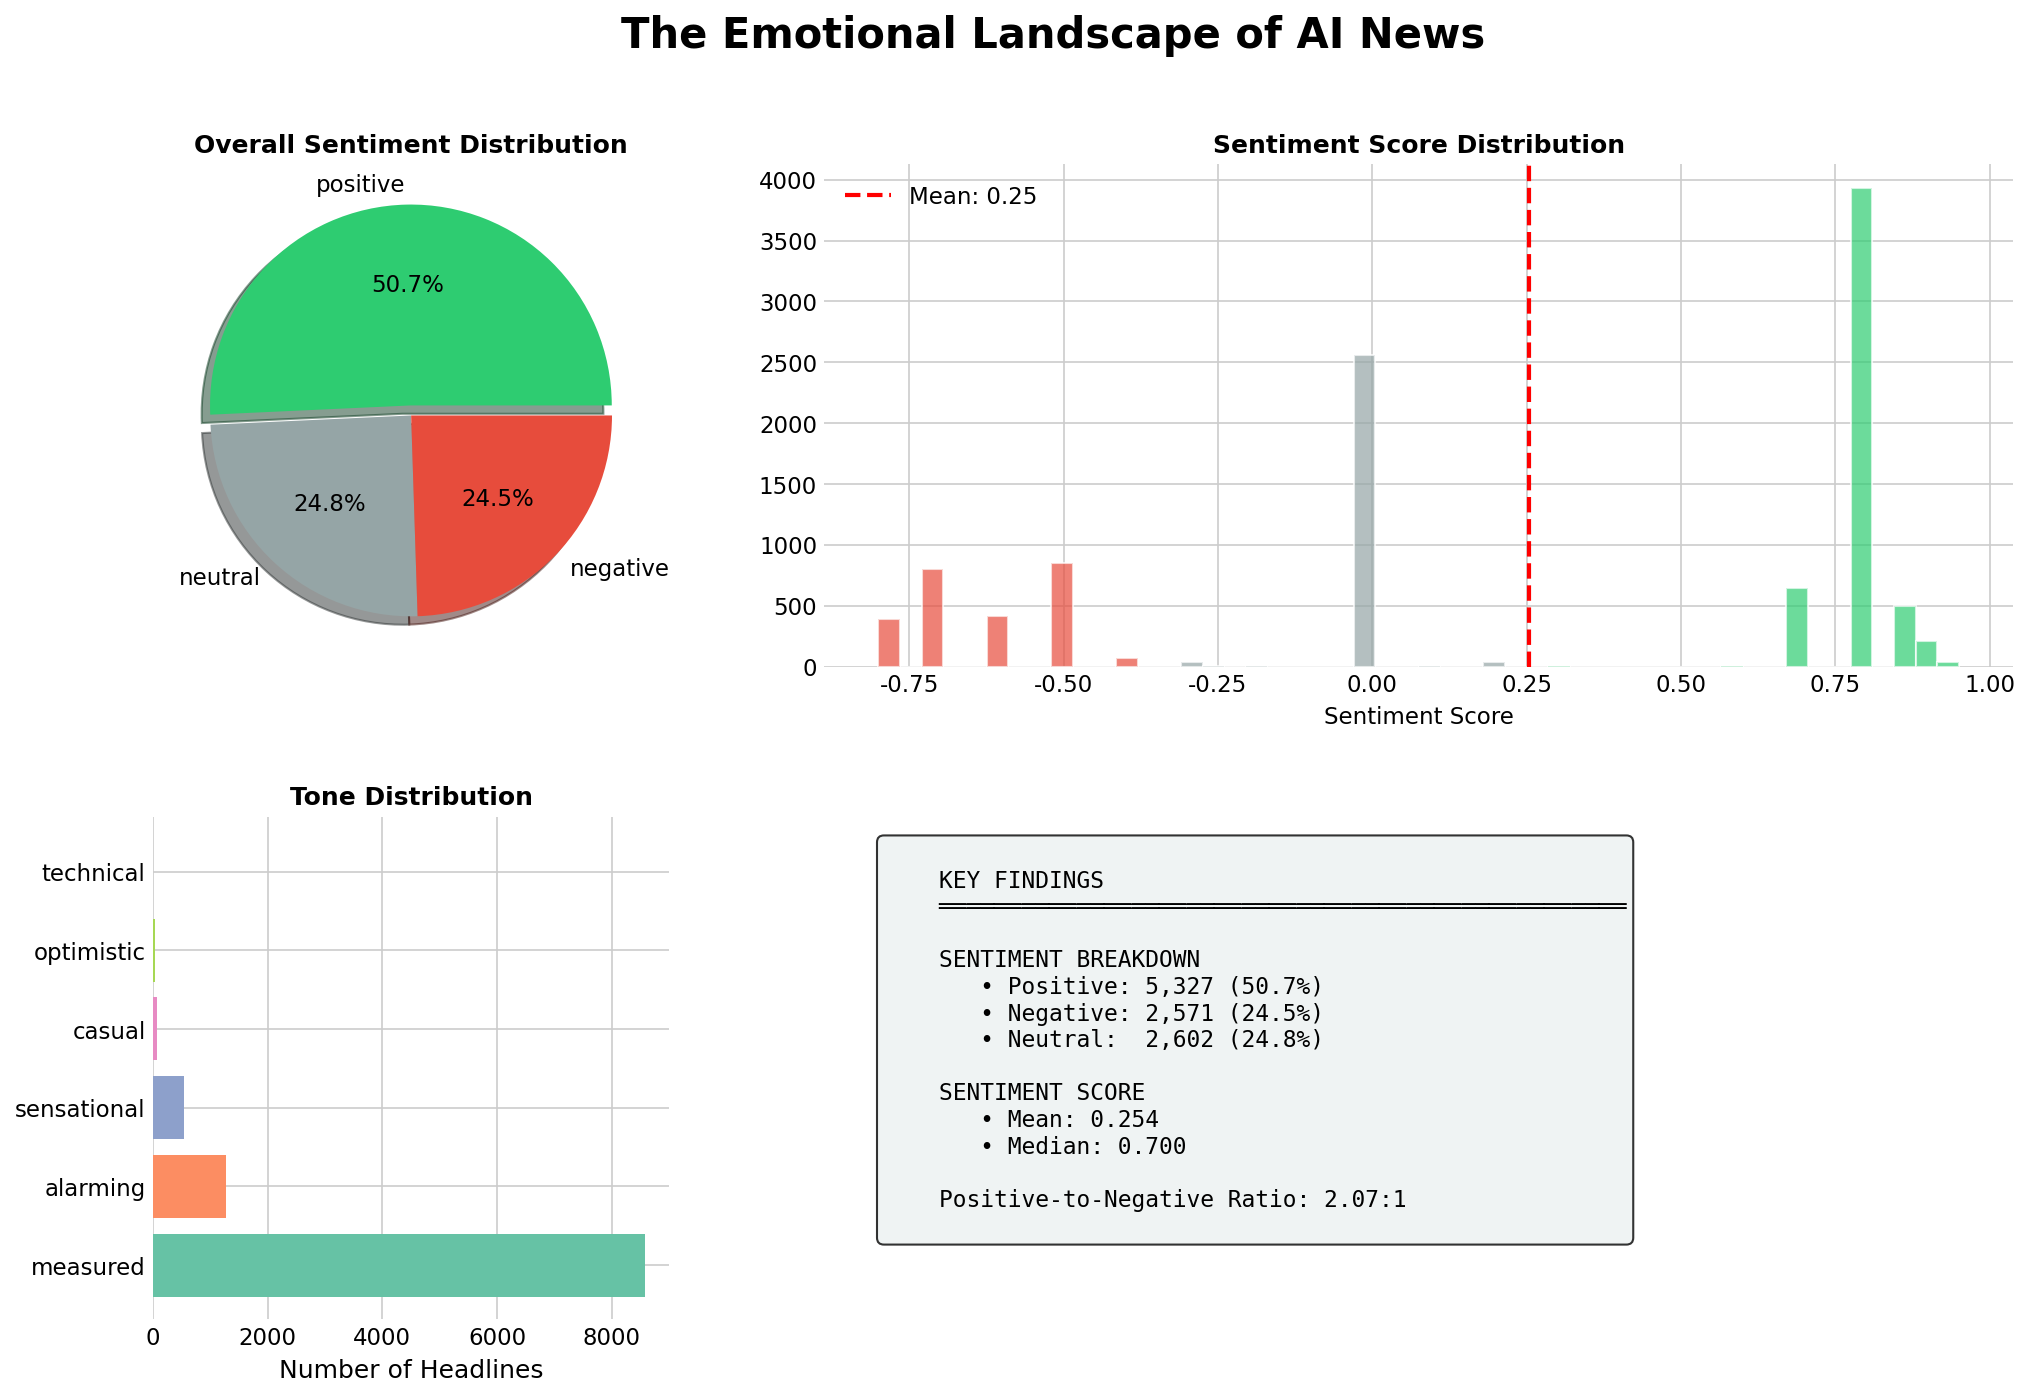

01_sentiment_overview.png


In [ ]:
# Figure 1: Sentiment Overview
def plot_sentiment_overview(df):
    """Figure 1: The Emotional Landscape of AI News"""
    fig = plt.figure(figsize=(16, 10))
    fig.suptitle('The Emotional Landscape of AI News', fontsize=20, fontweight='bold', y=0.98)

    gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

    # 1.1 Sentiment pie chart
    ax1 = fig.add_subplot(gs[0, 0])
    sentiment_counts = df['sentiment'].value_counts()
    colors = [COLORS.get(s, '#999') for s in sentiment_counts.index]
    ax1.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%',
            colors=colors, explode=[0.05 if s == 'positive' else 0 for s in sentiment_counts.index], shadow=True)
    ax1.set_title('Overall Sentiment Distribution', fontsize=12, fontweight='bold')

    # 1.2 Sentiment score distribution
    ax2 = fig.add_subplot(gs[0, 1:])
    scores = df['sentiment_score'].dropna()
    n, bins, patches = ax2.hist(scores, bins=50, edgecolor='white', alpha=0.7)
    for i, patch in enumerate(patches):
        bin_center = (bins[i] + bins[i+1]) / 2
        if bin_center > 0.3:
            patch.set_facecolor(COLORS['positive'])
        elif bin_center < -0.3:
            patch.set_facecolor(COLORS['negative'])
        else:
            patch.set_facecolor(COLORS['neutral'])
    ax2.axvline(scores.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {scores.mean():.2f}')
    ax2.set_xlabel('Sentiment Score', fontsize=11)
    ax2.set_title('Sentiment Score Distribution', fontsize=12, fontweight='bold')
    ax2.legend()

    # 1.3 Tone distribution
    ax3 = fig.add_subplot(gs[1, 0])
    tone_counts = df['tone'].value_counts()
    bars = ax3.barh(tone_counts.index, tone_counts.values, color=plt.cm.Set2.colors[:len(tone_counts)])
    ax3.set_xlabel('Number of Headlines')
    ax3.set_title('Tone Distribution', fontsize=12, fontweight='bold')

    # 1.4 Key findings
    ax4 = fig.add_subplot(gs[1, 1:])
    ax4.axis('off')
    key_findings = f"""
    KEY FINDINGS
    {'═'*50}

    SENTIMENT BREAKDOWN
       • Positive: {(df['sentiment']=='positive').sum():,} ({(df['sentiment']=='positive').mean()*100:.1f}%)
       • Negative: {(df['sentiment']=='negative').sum():,} ({(df['sentiment']=='negative').mean()*100:.1f}%)
       • Neutral:  {(df['sentiment']=='neutral').sum():,} ({(df['sentiment']=='neutral').mean()*100:.1f}%)

    SENTIMENT SCORE
       • Mean: {df['sentiment_score'].mean():.3f}
       • Median: {df['sentiment_score'].median():.3f}

    Positive-to-Negative Ratio: {(df['sentiment']=='positive').sum() / max((df['sentiment']=='negative').sum(), 1):.2f}:1
    """
    ax4.text(0.05, 0.95, key_findings, transform=ax4.transAxes, fontsize=11,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor=COLORS['light'], alpha=0.8))

    plt.savefig(VIZ_DIR / '01_sentiment_overview.png', bbox_inches='tight', dpi=150)
    plt.show()
    print("01_sentiment_overview.png")

plot_sentiment_overview(df_results)

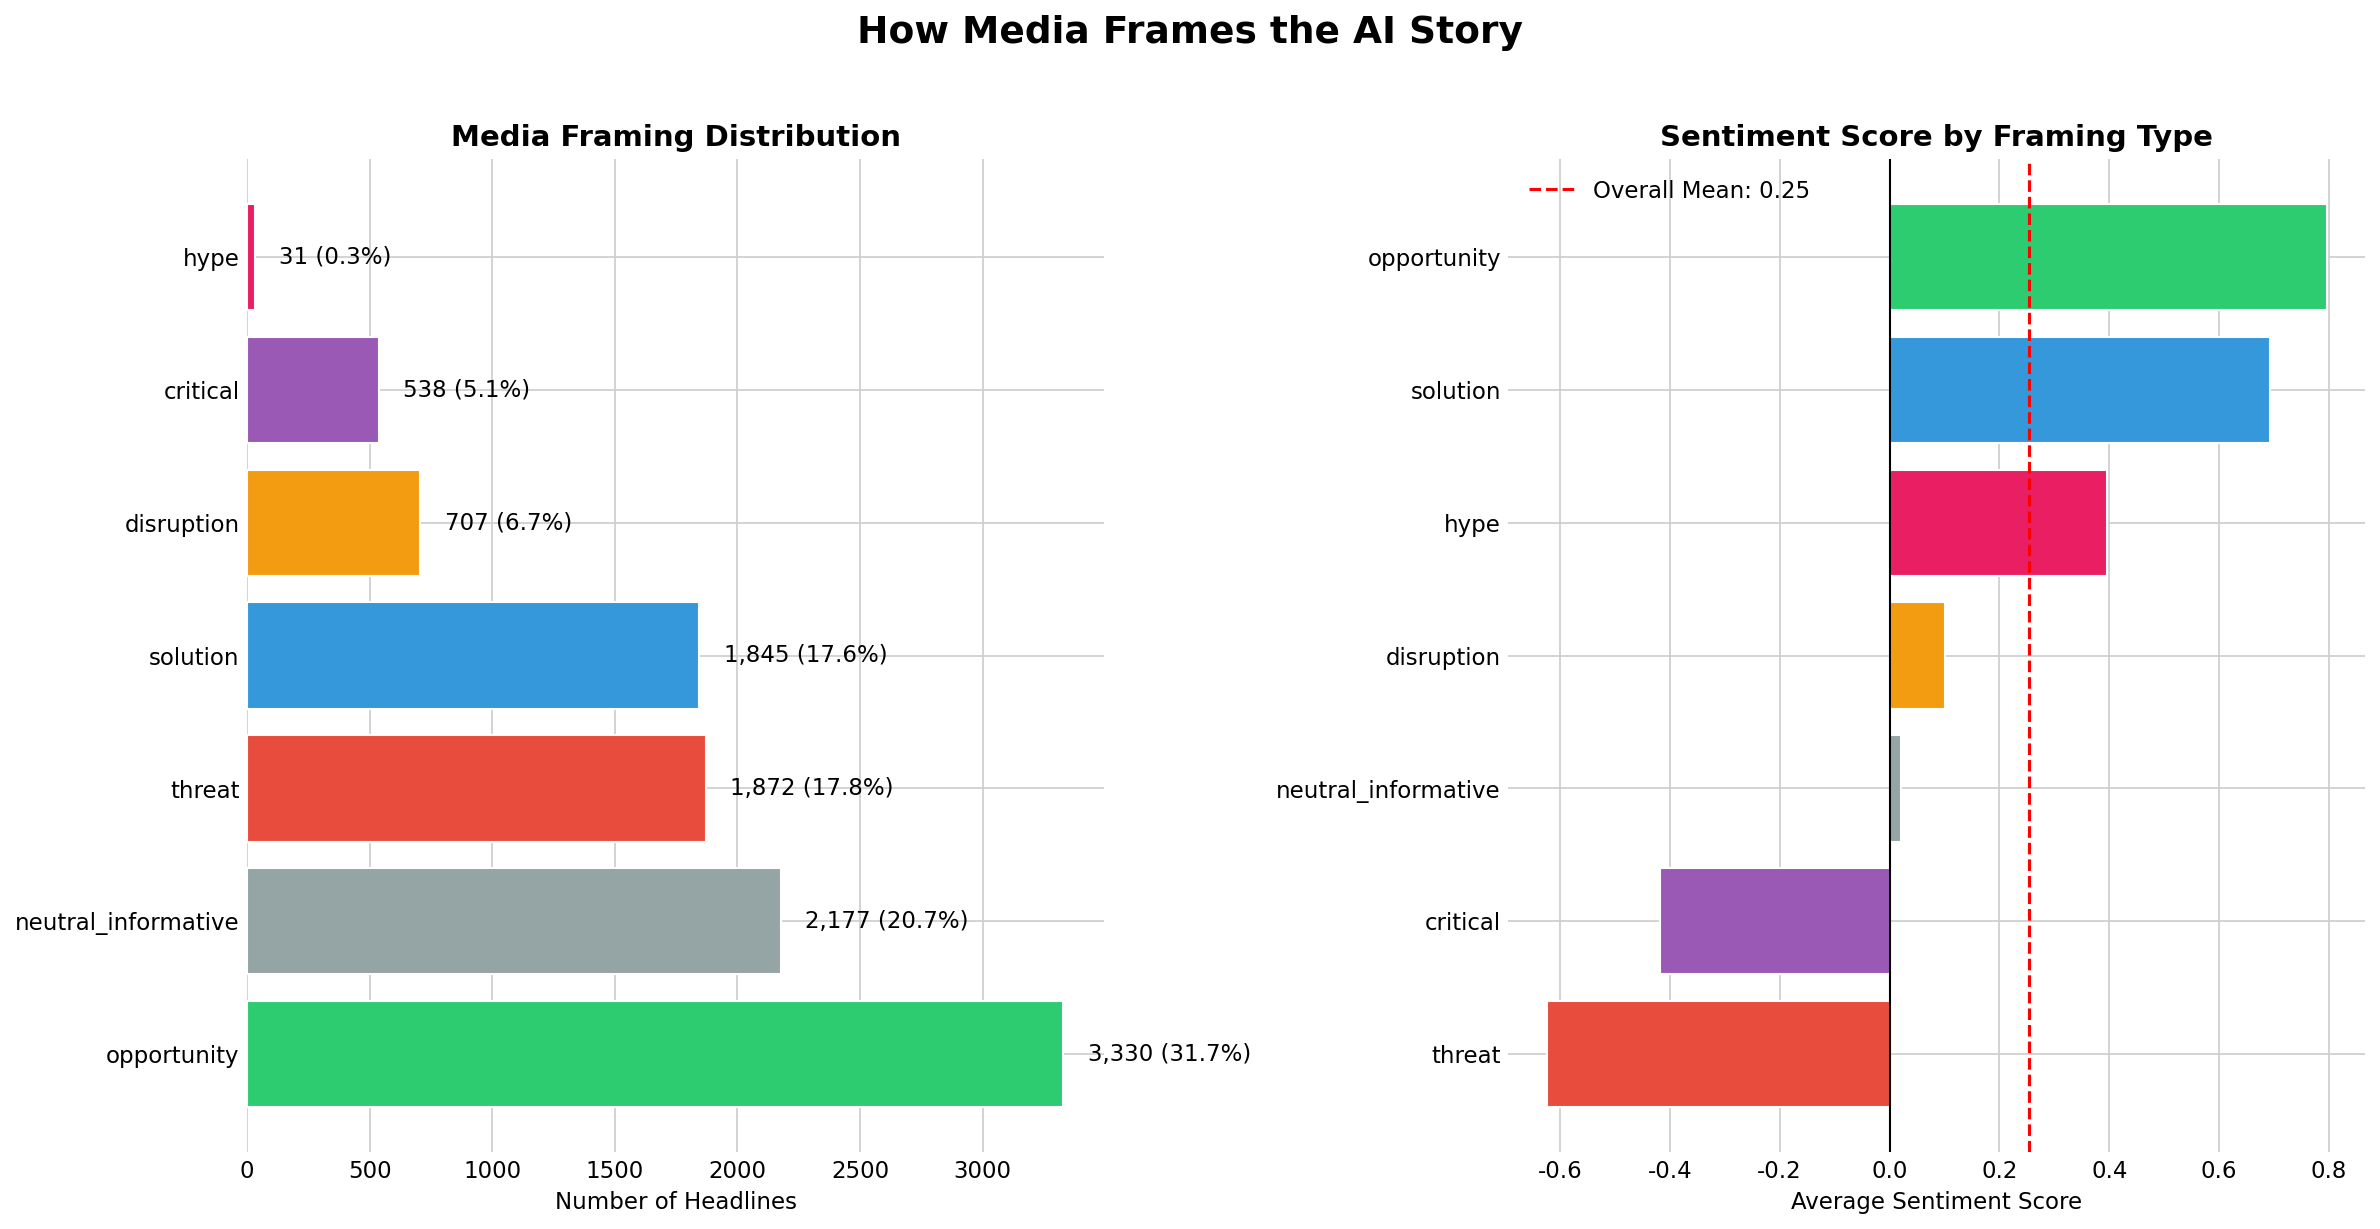

02_framing_analysis.png


In [ ]:
# Figure 2: Media Framing Analysis
def plot_framing_analysis(df):
    """Figure 2: How Media Frames the AI Story"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    fig.suptitle('How Media Frames the AI Story', fontsize=18, fontweight='bold', y=1.02)

    # 2.1 Framing distribution
    ax1 = axes[0]
    framing_counts = df['framing'].value_counts()
    colors = [FRAMING_COLORS.get(f, '#999') for f in framing_counts.index]
    bars = ax1.barh(framing_counts.index, framing_counts.values, color=colors, edgecolor='white')
    ax1.set_xlabel('Number of Headlines', fontsize=11)
    ax1.set_title('Media Framing Distribution', fontsize=14, fontweight='bold')
    for bar, count in zip(bars, framing_counts.values):
        pct = count / len(df) * 100
        ax1.text(count + 100, bar.get_y() + bar.get_height()/2, f'{count:,} ({pct:.1f}%)', va='center')

    # 2.2 Framing vs sentiment score
    ax2 = axes[1]
    framing_scores = df.groupby('framing')['sentiment_score'].agg(['mean', 'count'])
    framing_scores = framing_scores[framing_scores['count'] > 10].sort_values('mean', ascending=True)
    colors = [FRAMING_COLORS.get(f, '#999') for f in framing_scores.index]
    bars = ax2.barh(framing_scores.index, framing_scores['mean'], color=colors, edgecolor='white')
    ax2.axvline(0, color='black', linestyle='-', linewidth=1)
    ax2.axvline(df['sentiment_score'].mean(), color='red', linestyle='--', label=f'Overall Mean: {df["sentiment_score"].mean():.2f}')
    ax2.set_xlabel('Average Sentiment Score', fontsize=11)
    ax2.set_title('Sentiment Score by Framing Type', fontsize=14, fontweight='bold')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(VIZ_DIR / '02_framing_analysis.png', bbox_inches='tight', dpi=150)
    plt.show()
    print("02_framing_analysis.png")

plot_framing_analysis(df_results)

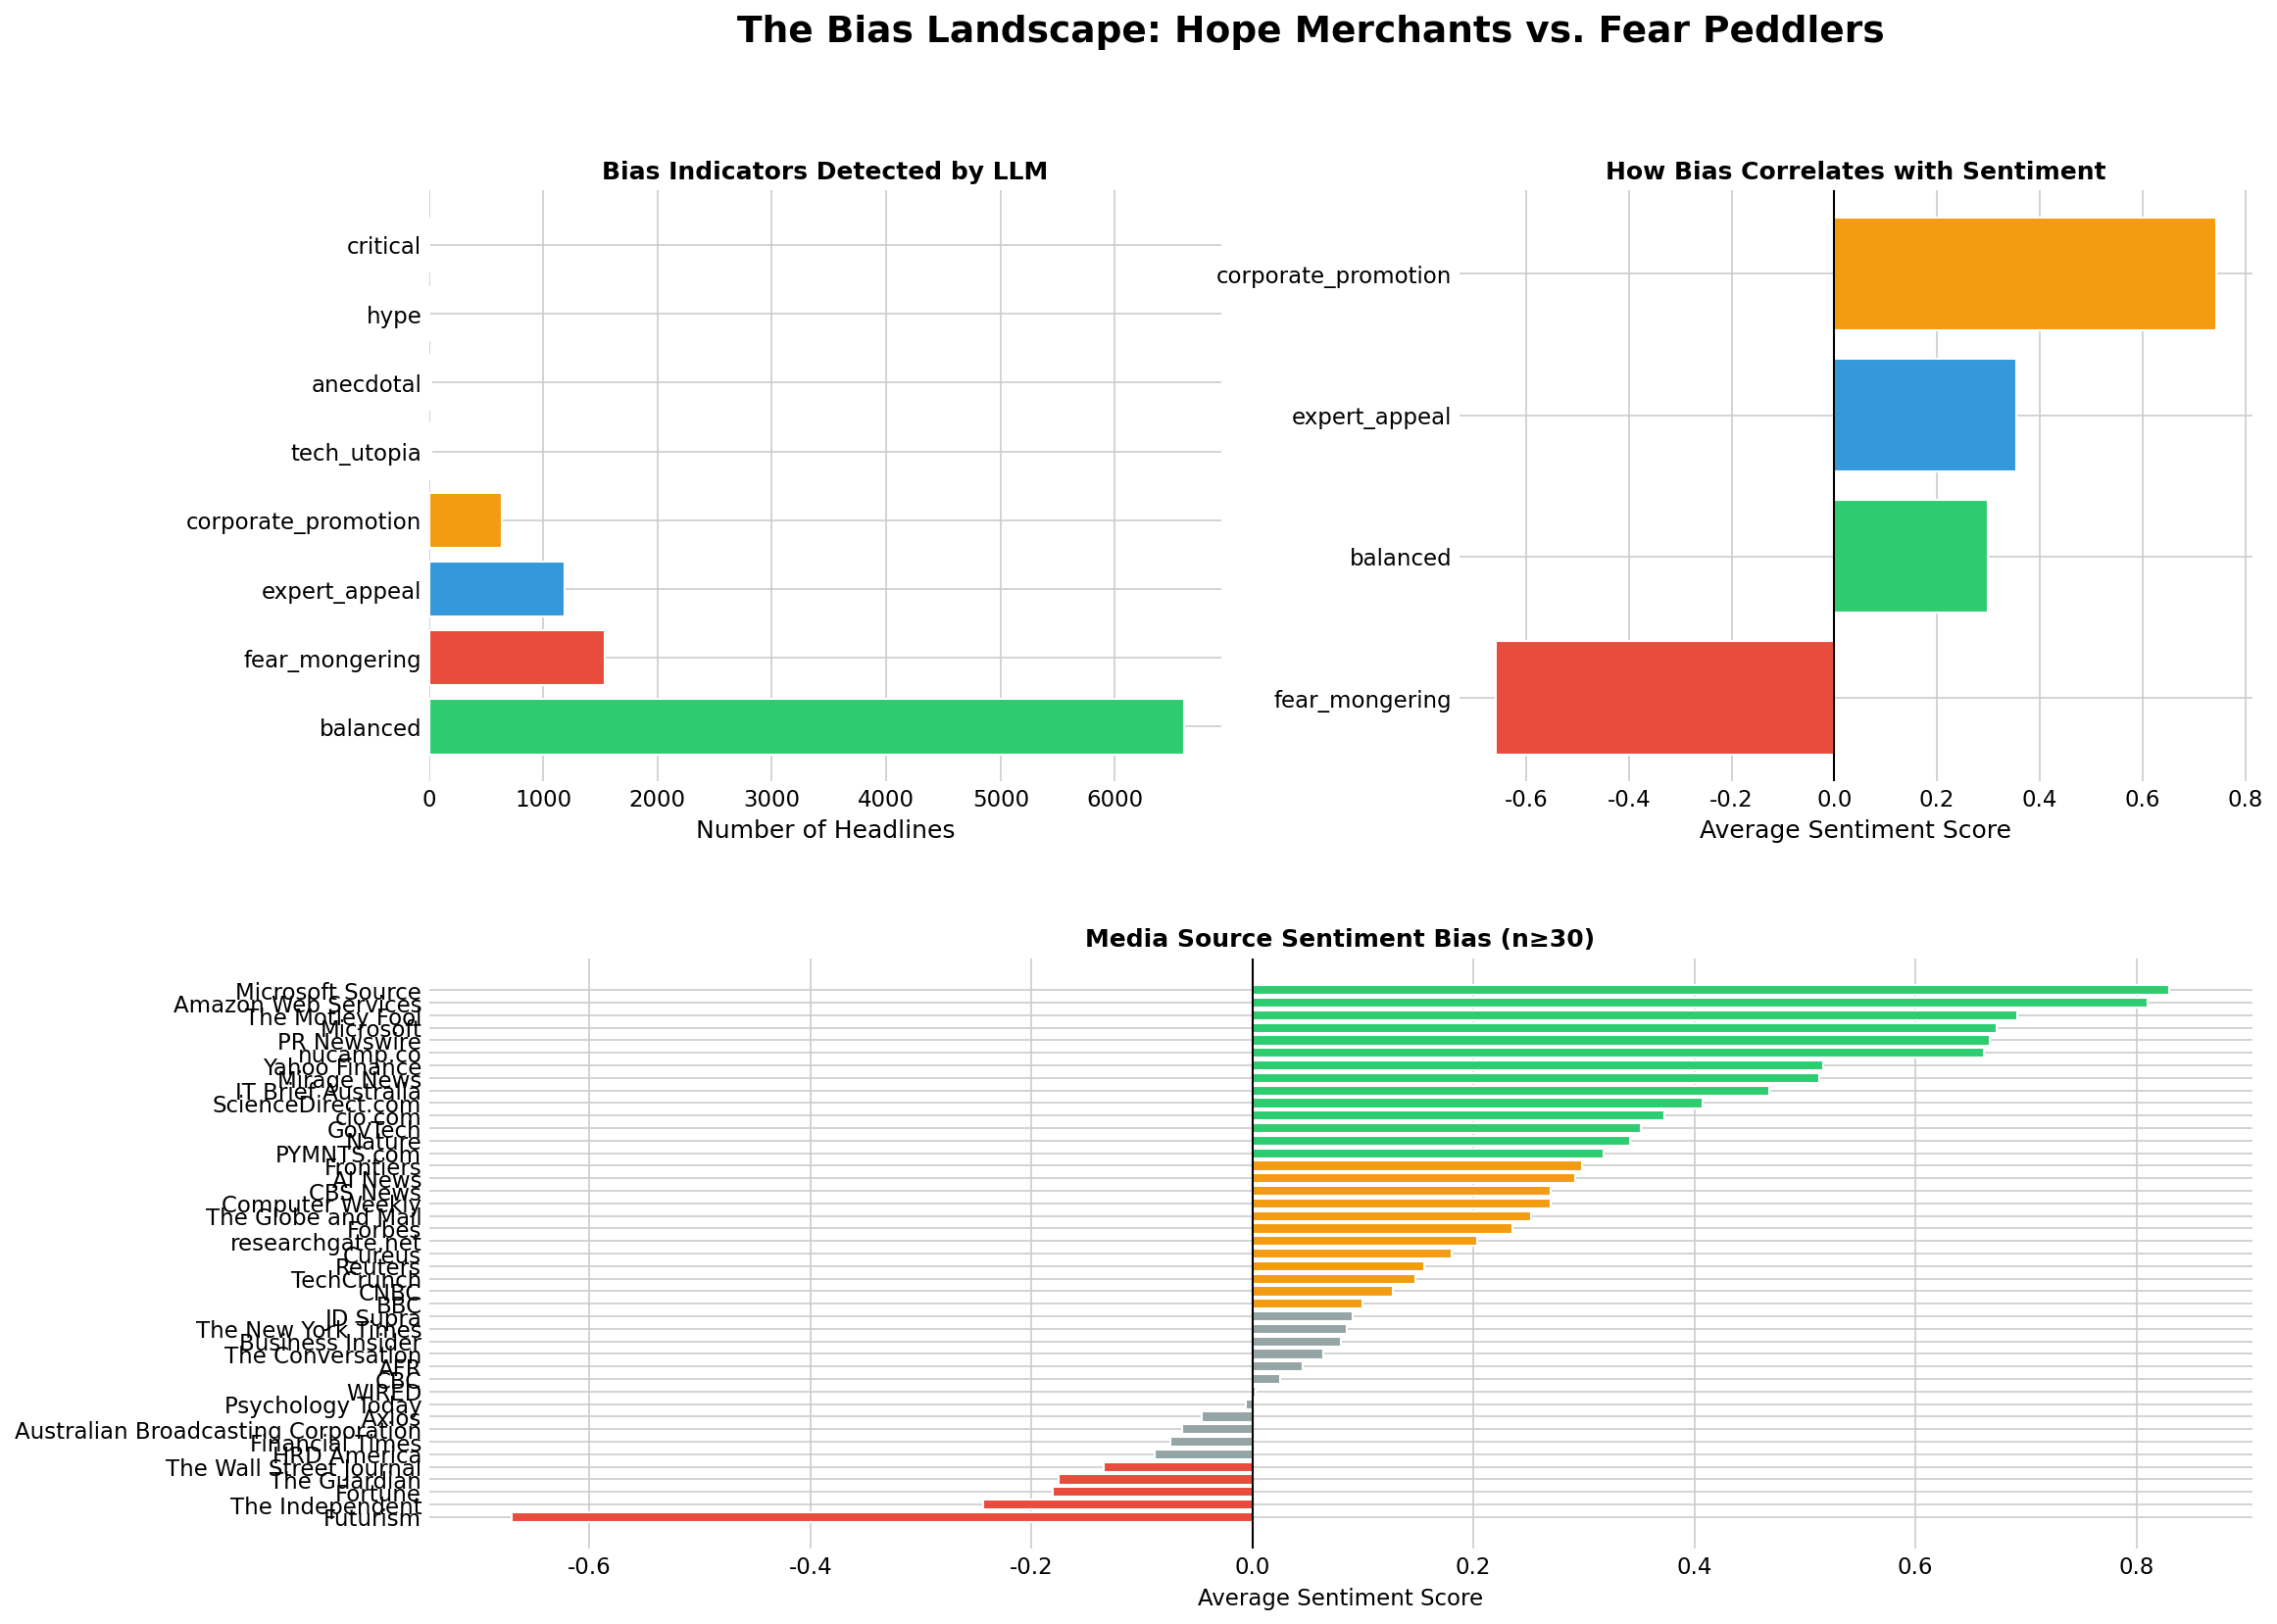

03_bias_landscape.png


In [ ]:
# Figure 3: Bias Landscape
def plot_bias_landscape(df):
    """Figure 3: The Bias Landscape"""
    fig = plt.figure(figsize=(16, 12))
    fig.suptitle('The Bias Landscape: Hope Merchants vs. Fear Peddlers', fontsize=18, fontweight='bold', y=0.98)

    gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

    # 3.1 Bias indicators distribution
    ax1 = fig.add_subplot(gs[0, 0])
    bias_counts = parse_list_column(df['bias_indicators'])
    bias_df = pd.DataFrame(bias_counts.most_common(10), columns=['Indicator', 'Count'])
    bias_colors = {'balanced': '#2ecc71', 'expert_appeal': '#3498db', 'fear_mongering': '#e74c3c',
                   'corporate_promotion': '#f39c12', 'tech_utopia': '#9b59b6', 'anecdotal': '#95a5a6'}
    colors = [bias_colors.get(b, '#999') for b in bias_df['Indicator']]
    bars = ax1.barh(bias_df['Indicator'], bias_df['Count'], color=colors, edgecolor='white')
    ax1.set_xlabel('Number of Headlines')
    ax1.set_title('Bias Indicators Detected by LLM', fontsize=12, fontweight='bold')

    # 3.2 Bias vs sentiment relationship
    ax2 = fig.add_subplot(gs[0, 1])
    bias_sentiment = {}
    for idx, row in df.iterrows():
        if pd.notna(row['bias_indicators']):
            for bias in str(row['bias_indicators']).split('|'):
                if bias not in bias_sentiment:
                    bias_sentiment[bias] = []
                bias_sentiment[bias].append(row['sentiment_score'])
    bias_mean = {k: np.mean(v) for k, v in bias_sentiment.items() if len(v) > 50}
    bias_mean_sorted = dict(sorted(bias_mean.items(), key=lambda x: x[1]))
    colors = [bias_colors.get(b, '#999') for b in bias_mean_sorted.keys()]
    ax2.barh(list(bias_mean_sorted.keys()), list(bias_mean_sorted.values()), color=colors, edgecolor='white')
    ax2.axvline(0, color='black', linestyle='-', linewidth=1)
    ax2.set_xlabel('Average Sentiment Score')
    ax2.set_title('How Bias Correlates with Sentiment', fontsize=12, fontweight='bold')

    # 3.3 Media source sentiment
    ax3 = fig.add_subplot(gs[1, :])
    source_stats = df.groupby('source').agg({'sentiment_score': 'mean', 'source': 'count'}).rename(
        columns={'source': 'count', 'sentiment_score': 'mean_score'})
    source_stats = source_stats[source_stats['count'] >= 30].sort_values('mean_score')
    colors = ['#e74c3c' if s < -0.1 else '#2ecc71' if s > 0.3 else '#f39c12' if s > 0.1 else '#95a5a6'
              for s in source_stats['mean_score']]
    ax3.barh(source_stats.index, source_stats['mean_score'], color=colors, edgecolor='white')
    ax3.axvline(0, color='black', linestyle='-', linewidth=1)
    ax3.set_xlabel('Average Sentiment Score', fontsize=11)
    ax3.set_title('Media Source Sentiment Bias (n≥30)', fontsize=12, fontweight='bold')

    plt.savefig(VIZ_DIR / '03_bias_landscape.png', bbox_inches='tight', dpi=150)
    plt.show()
    print("03_bias_landscape.png")

plot_bias_landscape(df_results)

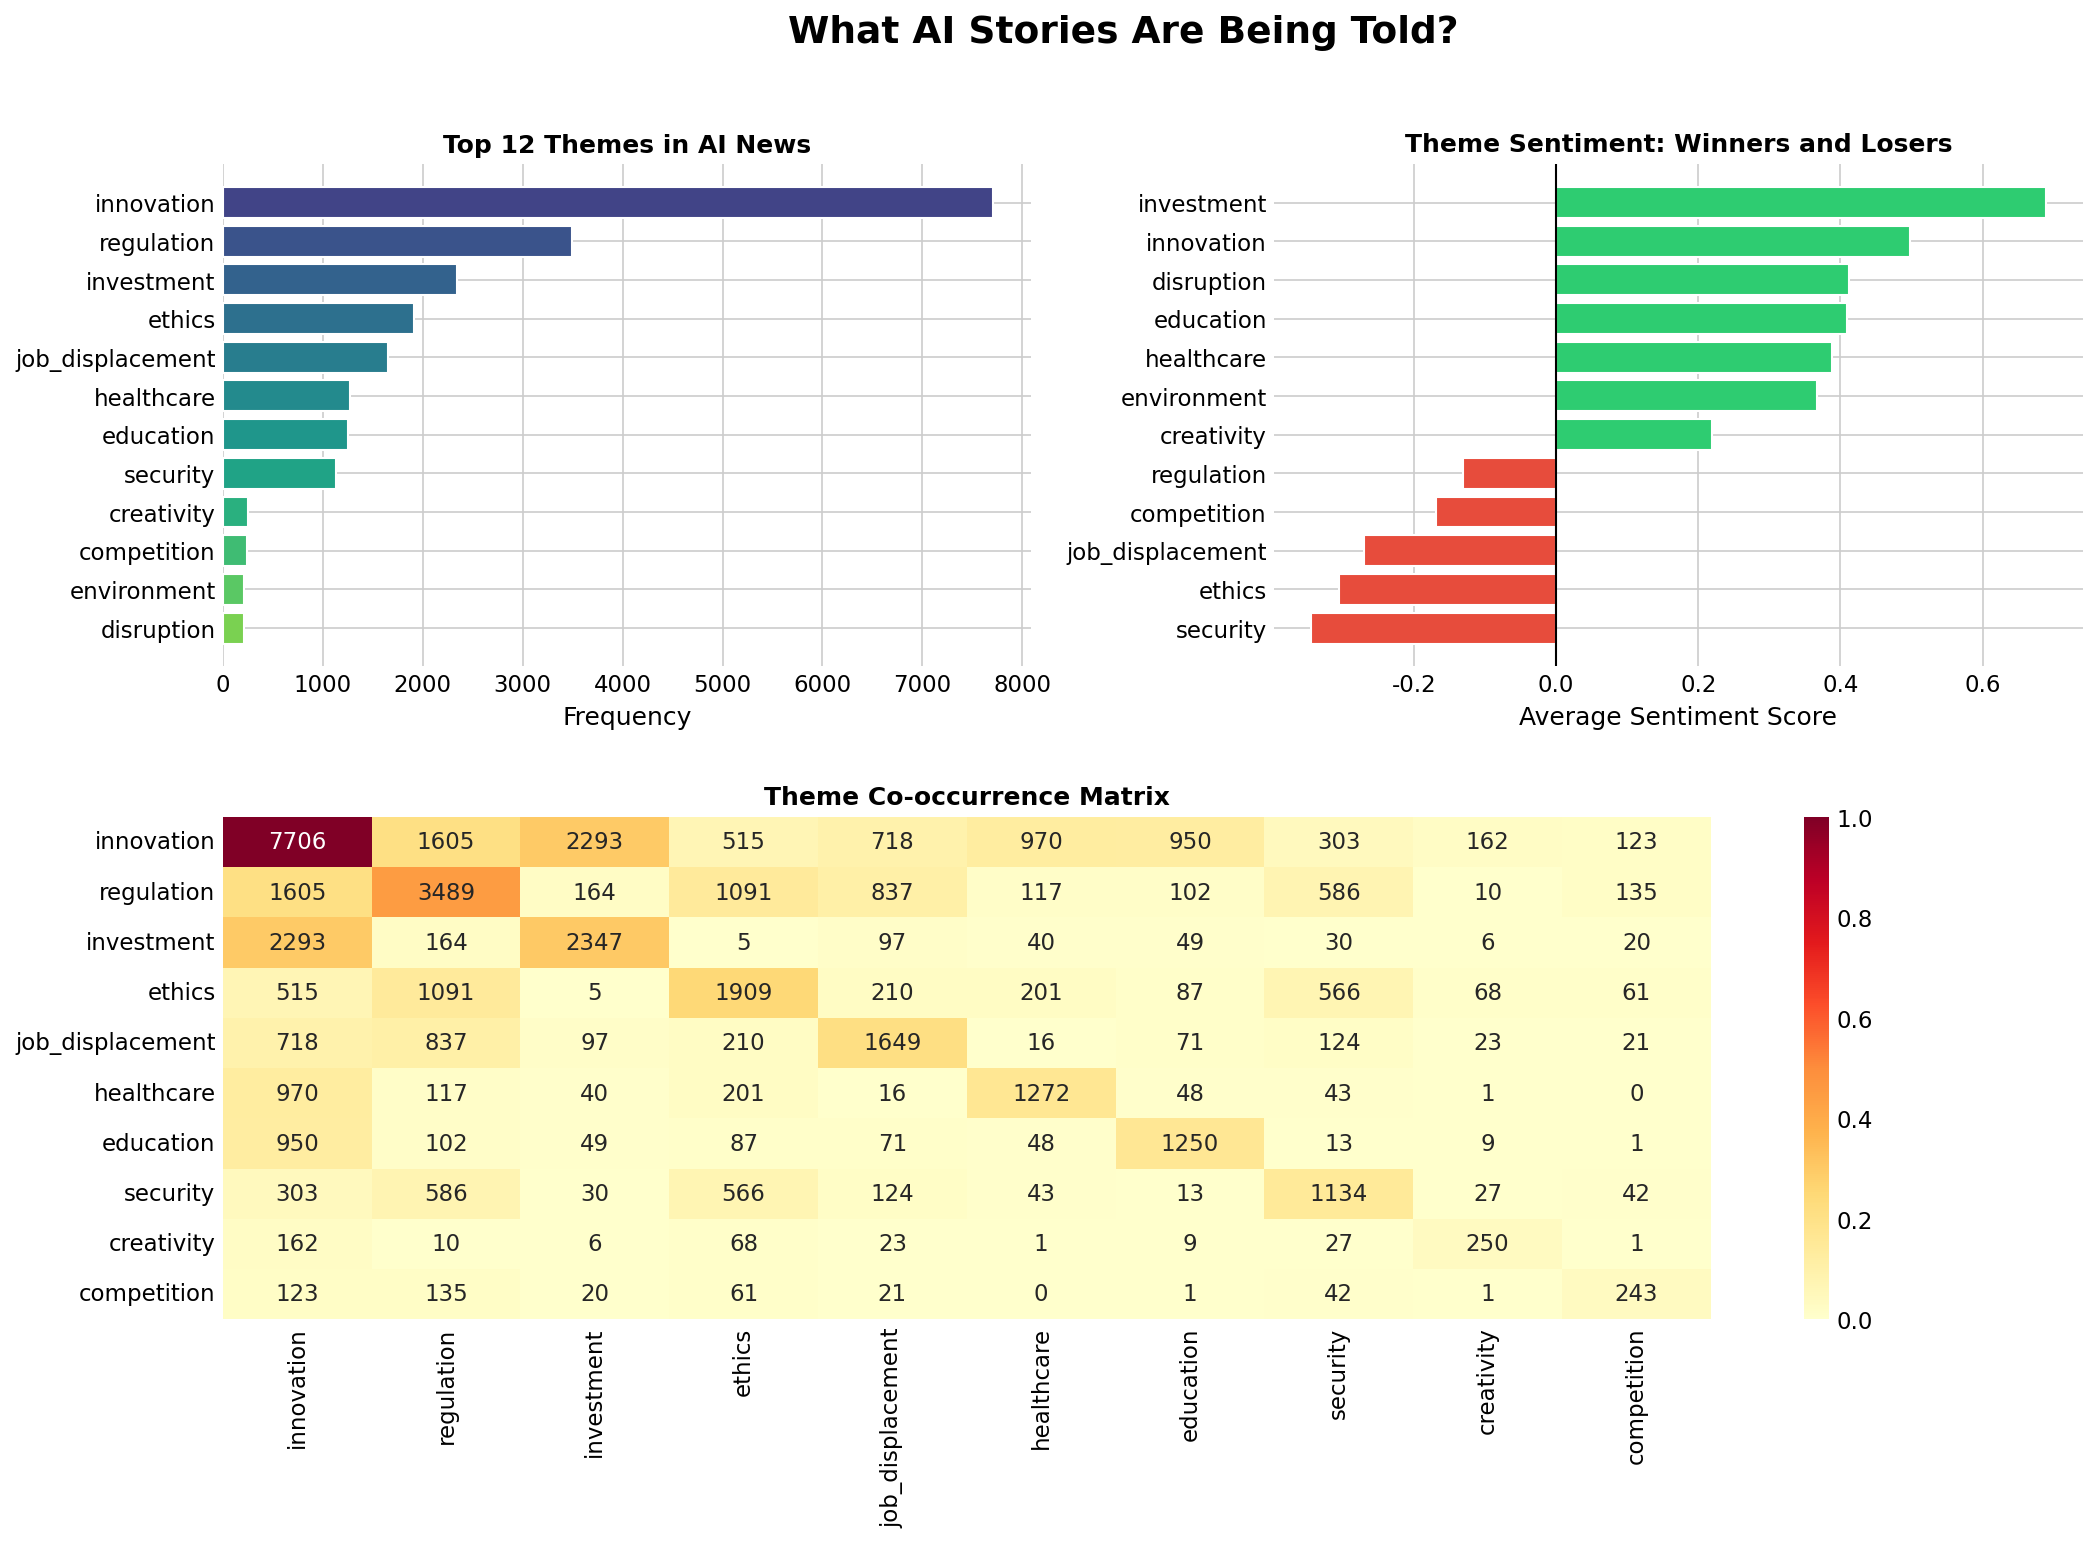

04_theme_exploration.png


In [ ]:
# Figure 4: Theme Exploration
def plot_theme_exploration(df):
    """Figure 4: What AI Stories Are Being Told?"""
    fig = plt.figure(figsize=(16, 10))
    fig.suptitle('What AI Stories Are Being Told?', fontsize=18, fontweight='bold', y=0.98)

    gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

    # 4.1 Theme frequency
    ax1 = fig.add_subplot(gs[0, 0])
    theme_counts = parse_list_column(df['key_themes'])
    theme_df = pd.DataFrame(theme_counts.most_common(12), columns=['Theme', 'Count'])
    theme_colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(theme_df)))
    ax1.barh(theme_df['Theme'], theme_df['Count'], color=theme_colors, edgecolor='white')
    ax1.set_xlabel('Frequency')
    ax1.set_title('Top 12 Themes in AI News', fontsize=12, fontweight='bold')
    ax1.invert_yaxis()

    # 4.2 Theme vs sentiment
    ax2 = fig.add_subplot(gs[0, 1])
    theme_sentiment = {}
    for idx, row in df.iterrows():
        if pd.notna(row['key_themes']):
            for theme in str(row['key_themes']).split('|'):
                if theme not in theme_sentiment:
                    theme_sentiment[theme] = []
                theme_sentiment[theme].append(row['sentiment_score'])
    theme_mean = {k: np.mean(v) for k, v in theme_sentiment.items() if len(v) > 100}
    theme_mean_sorted = dict(sorted(theme_mean.items(), key=lambda x: x[1]))
    colors = ['#e74c3c' if s < 0 else '#2ecc71' for s in theme_mean_sorted.values()]
    ax2.barh(list(theme_mean_sorted.keys()), list(theme_mean_sorted.values()), color=colors, edgecolor='white')
    ax2.axvline(0, color='black', linestyle='-', linewidth=1)
    ax2.set_xlabel('Average Sentiment Score')
    ax2.set_title('Theme Sentiment: Winners and Losers', fontsize=12, fontweight='bold')

    # 4.3 Theme co-occurrence heatmap
    ax3 = fig.add_subplot(gs[1, :])
    top_themes = [t[0] for t in theme_counts.most_common(10)]
    cooccurrence = pd.DataFrame(0, index=top_themes, columns=top_themes)
    for idx, row in df.iterrows():
        if pd.notna(row['key_themes']):
            themes = [t for t in str(row['key_themes']).split('|') if t in top_themes]
            for i, t1 in enumerate(themes):
                for t2 in themes[i:]:
                    cooccurrence.loc[t1, t2] += 1
                    if t1 != t2:
                        cooccurrence.loc[t2, t1] += 1
    cooccurrence_norm = cooccurrence / cooccurrence.max().max()
    sns.heatmap(cooccurrence_norm, annot=cooccurrence, fmt='d', cmap='YlOrRd', ax=ax3)
    ax3.set_title('Theme Co-occurrence Matrix', fontsize=12, fontweight='bold')

    plt.savefig(VIZ_DIR / '04_theme_exploration.png', bbox_inches='tight', dpi=150)
    plt.show()
    print("04_theme_exploration.png")

plot_theme_exploration(df_results)

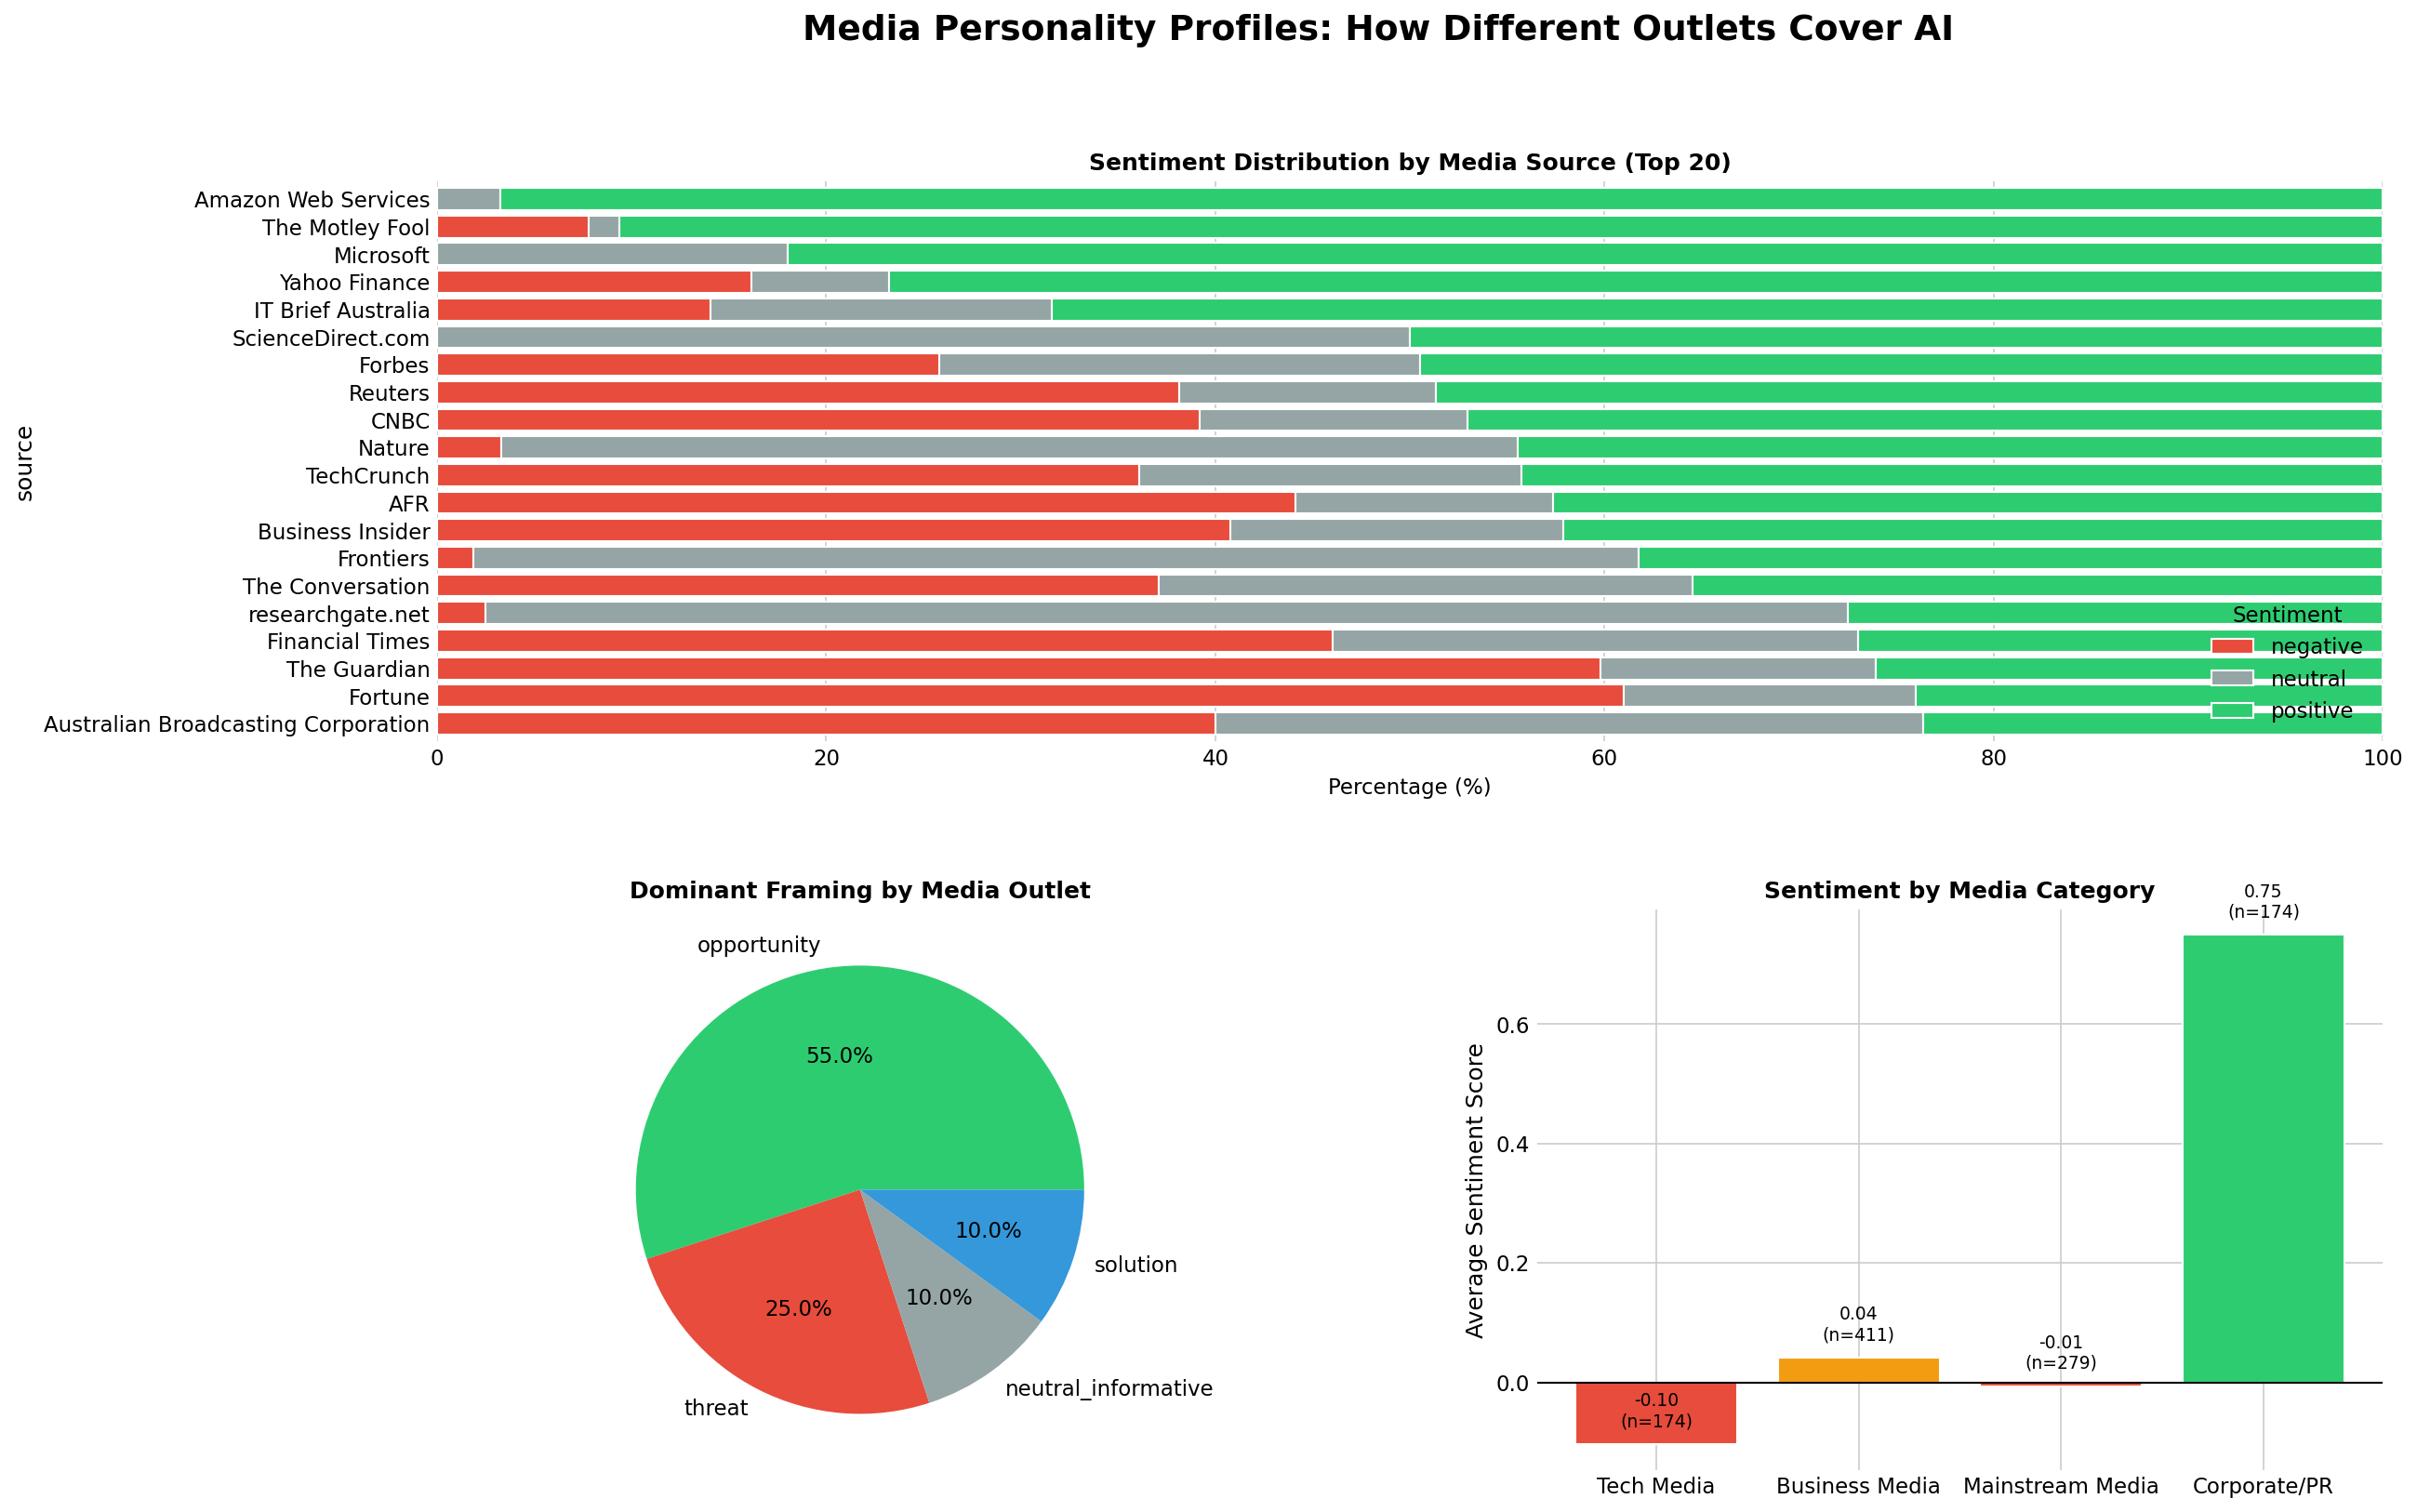

05_media_profiles.png


In [ ]:
# Figure 5: Media Profiles
def plot_media_profiles(df):
    """Figure 5: How Different Outlets Cover AI"""
    fig = plt.figure(figsize=(18, 12))
    fig.suptitle('Media Personality Profiles: How Different Outlets Cover AI', fontsize=18, fontweight='bold', y=0.98)

    top_sources = df['source'].value_counts().head(20).index.tolist()
    source_df = df[df['source'].isin(top_sources)]

    gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

    # 5.1 Stacked sentiment distribution
    ax1 = fig.add_subplot(gs[0, :])
    source_sentiment = source_df.groupby(['source', 'sentiment']).size().unstack(fill_value=0)
    source_sentiment_pct = source_sentiment.div(source_sentiment.sum(axis=1), axis=0) * 100
    if 'positive' in source_sentiment_pct.columns:
        source_sentiment_pct = source_sentiment_pct.sort_values('positive', ascending=True)
    colors_order = [COLORS.get(col, '#999') for col in source_sentiment_pct.columns]
    source_sentiment_pct.plot(kind='barh', stacked=True, ax=ax1, color=colors_order, edgecolor='white', width=0.8)
    ax1.set_xlabel('Percentage (%)', fontsize=11)
    ax1.set_title('Sentiment Distribution by Media Source (Top 20)', fontsize=12, fontweight='bold')
    ax1.legend(title='Sentiment', loc='lower right')
    ax1.set_xlim(0, 100)

    # 5.2 Framing preference
    ax2 = fig.add_subplot(gs[1, 0])
    source_framing = source_df.groupby(['source', 'framing']).size().unstack(fill_value=0)
    dominant_framing = source_framing.idxmax(axis=1)
    framing_summary = dominant_framing.value_counts()
    colors = [FRAMING_COLORS.get(f, '#999') for f in framing_summary.index]
    ax2.pie(framing_summary.values, labels=framing_summary.index, autopct='%1.1f%%', colors=colors)
    ax2.set_title('Dominant Framing by Media Outlet', fontsize=12, fontweight='bold')

    # 5.3 Media category comparison
    ax3 = fig.add_subplot(gs[1, 1])
    tech_media = ['TechCrunch', 'WIRED', 'The Verge', 'Ars Technica', 'Futurism']
    business_media = ['Forbes', 'Fortune', 'Financial Times', 'The Wall Street Journal', 'Bloomberg']
    mainstream_media = ['The Guardian', 'BBC', 'Reuters', 'The New York Times', 'CNN']
    corporate_media = ['Microsoft', 'Amazon Web Services', 'Microsoft Source', 'PR Newswire']

    def get_category_stats(sources):
        subset = df[df['source'].isin(sources)]
        return (subset['sentiment_score'].mean(), len(subset)) if len(subset) > 0 else (0, 0)

    categories = ['Tech Media', 'Business Media', 'Mainstream Media', 'Corporate/PR']
    source_lists = [tech_media, business_media, mainstream_media, corporate_media]
    scores = [get_category_stats(s)[0] for s in source_lists]
    counts = [get_category_stats(s)[1] for s in source_lists]
    colors = ['#e74c3c' if s < 0 else '#2ecc71' if s > 0.3 else '#f39c12' for s in scores]
    bars = ax3.bar(categories, scores, color=colors, edgecolor='white')
    ax3.axhline(0, color='black', linestyle='-', linewidth=1)
    ax3.set_ylabel('Average Sentiment Score')
    ax3.set_title('Sentiment by Media Category', fontsize=12, fontweight='bold')
    for bar, score, count in zip(bars, scores, counts):
        ax3.text(bar.get_x() + bar.get_width()/2, score + 0.03, f'{score:.2f}\n(n={count})', ha='center', fontsize=9)

    plt.savefig(VIZ_DIR / '05_media_profiles.png', bbox_inches='tight', dpi=150)
    plt.show()
    print("05_media_profiles.png")

plot_media_profiles(df_results)

In [ ]:
print("\n" + "="*60)
print("All visualizations generated!")
print(f"Saved to: {VIZ_DIR}/")
print("="*60)


All visualizations generated!
Saved to: /content/visualizations_hf_story/


---
## Deep Interpretation: From Statistics to Narrative

**The "Broken Mirror" Thesis:**
- Media should reflect reality objectively, but AI coverage systematically distorts the picture
- Benefits are amplified; risks are contained
- This serves corporate interests and leaves the public under-informed about AI risks

This section uses LLM to analyze aggregated statistics and generate deeper insights that connect data patterns to our thesis.

In [ ]:
# Compile key statistics for deep interpretation

# Helper function (in case visualization section was skipped)
def parse_list_column(series):
    """Parse pipe-separated list columns"""
    all_items = []
    for item in series.dropna():
        all_items.extend(str(item).split('|'))
    return Counter(all_items)

def compile_statistics_summary(df):
    """Compile key statistics into a structured summary for LLM interpretation"""

    # Sentiment statistics
    pos_count = (df['sentiment'] == 'positive').sum()
    neg_count = (df['sentiment'] == 'negative').sum()
    neu_count = (df['sentiment'] == 'neutral').sum()
    pos_neg_ratio = pos_count / max(neg_count, 1)

    # Framing statistics
    framing_counts = df['framing'].value_counts().to_dict()
    opp_count = framing_counts.get('opportunity', 0)
    threat_count = framing_counts.get('threat', 0)
    opp_threat_ratio = opp_count / max(threat_count, 1)

    # Source analysis
    source_sentiment = df.groupby('source')['sentiment_score'].agg(['mean', 'count'])
    source_sentiment = source_sentiment[source_sentiment['count'] >= 30].sort_values('mean')

    # Categorize sources
    tech_media = ['TechCrunch', 'WIRED', 'The Verge', 'Ars Technica', 'Futurism']
    corporate_sources = ['Microsoft', 'Amazon Web Services', 'PR Newswire', 'Microsoft Source']

    tech_score = df[df['source'].isin(tech_media)]['sentiment_score'].mean()
    corp_score = df[df['source'].isin(corporate_sources)]['sentiment_score'].mean()

    # Bias indicators
    bias_counts = parse_list_column(df['bias_indicators'])

    # Theme analysis
    theme_counts = parse_list_column(df['key_themes'])

    summary = f"""
STATISTICAL SUMMARY OF AI NEWS HEADLINE ANALYSIS
================================================
Dataset: {len(df):,} AI-related news headlines from multiple media sources

1. SENTIMENT DISTRIBUTION
   - Positive: {pos_count:,} ({pos_count/len(df)*100:.1f}%)
   - Negative: {neg_count:,} ({neg_count/len(df)*100:.1f}%)
   - Neutral: {neu_count:,} ({neu_count/len(df)*100:.1f}%)
   - Positive-to-Negative Ratio: {pos_neg_ratio:.2f}:1
   - Mean Sentiment Score: {df['sentiment_score'].mean():.3f} (scale: -1 to +1)

2. MEDIA FRAMING
   - Opportunity framing: {opp_count:,} ({opp_count/len(df)*100:.1f}%)
   - Threat framing: {threat_count:,} ({threat_count/len(df)*100:.1f}%)
   - Opportunity-to-Threat Ratio: {opp_threat_ratio:.2f}:1
   - Full distribution: {framing_counts}

3. SOURCE BIAS COMPARISON
   - Corporate/PR sources avg sentiment: {corp_score:.3f}
   - Tech media avg sentiment: {tech_score:.3f}
   - Gap: {corp_score - tech_score:.3f}
   - Most positive sources: {source_sentiment.tail(5).index.tolist()}
   - Most negative sources: {source_sentiment.head(5).index.tolist()}

4. BIAS INDICATORS DETECTED
   - {dict(bias_counts.most_common(6))}

5. DOMINANT THEMES
   - {dict(theme_counts.most_common(8))}
"""
    return summary

stats_summary = compile_statistics_summary(df_results)
print(stats_summary)


STATISTICAL SUMMARY OF AI NEWS HEADLINE ANALYSIS
Dataset: 10,500 AI-related news headlines from multiple media sources

1. SENTIMENT DISTRIBUTION
   - Positive: 5,327 (50.7%)
   - Negative: 2,571 (24.5%)
   - Neutral: 2,602 (24.8%)
   - Positive-to-Negative Ratio: 2.07:1
   - Mean Sentiment Score: 0.254 (scale: -1 to +1)

2. MEDIA FRAMING
   - Opportunity framing: 3,330 (31.7%)
   - Threat framing: 1,872 (17.8%)
   - Opportunity-to-Threat Ratio: 1.78:1
   - Full distribution: {'opportunity': 3330, 'neutral_informative': 2177, 'threat': 1872, 'solution': 1845, 'disruption': 707, 'critical': 538, 'hype': 31}

3. SOURCE BIAS COMPARISON
   - Corporate/PR sources avg sentiment: 0.749
   - Tech media avg sentiment: -0.104
   - Gap: 0.853
   - Most positive sources: ['PR Newswire', 'Microsoft', 'The Motley Fool', 'Amazon Web Services', 'Microsoft Source']
   - Most negative sources: ['Futurism', 'The Independent', 'Fortune', 'The Guardian', 'The Wall Street Journal']

4. BIAS INDICATORS DETE

In [ ]:
# Deep Interpretation Prompt

# Ensure CONFIG is defined (in case cells run out of order)
if 'CONFIG' not in globals():
    CONFIG = {
        'model': 'meta-llama/Llama-3.1-8B-Instruct:cerebras',
        'temperature': 0.1,
        'max_tokens': 600,
    }

INTERPRETATION_PROMPT = """You are a critical media studies scholar analyzing patterns in AI news coverage.

CONTEXT: We analyzed {total:,} AI-related news headlines using LLM-based semantic classification.
STATISTICAL FINDINGS:
{stats_summary}

ANALYSIS TASKS:

1. **PATTERN INTERPRETATION** (3-4 key insights)
   Explain what these statistical patterns reveal about HOW media covers AI.
   - Why is the positive-to-negative ratio so skewed?
   - What does the opportunity-to-threat framing gap suggest?
   - What does the corporate vs. tech media sentiment gap reveal?

2. **ROOT CAUSE ANALYSIS** (analyze each)
   Evaluate how these factors might contribute to the observed bias:
   a) Corporate PR infiltration - How might corporate communications shape coverage?
   b) Journalist cognitive bias - What psychological factors might drive optimism bias?
   c) Traffic-driven incentives - How might clickbait economics influence framing?

3. **CONSEQUENCES FOR PUBLIC UNDERSTANDING** (2-3 points)
   What are the implications of this distorted coverage for:
   - Public risk perception of AI
   - Democratic deliberation on AI policy
   - Informed consent in AI adoption

4. **EVIDENCE STRENGTH ASSESSMENT**
   How strongly does this data support the "Broken Mirror" thesis?
   - What patterns most strongly support the thesis?
   - What alternative explanations should be considered?
   - What additional evidence would strengthen the argument?

5. **POLICY RECOMMENDATIONS** (3-4 actionable suggestions)
   Based on these findings, what interventions could address media bias in AI coverage?
   Consider recommendations for: media organizations, policymakers, researchers, and the public.

Provide a structured, evidence-based analysis. Be specific and cite the statistics provided. Write in an academic but accessible tone suitable for a research presentation."""

def get_deep_interpretation(stats_summary, total):
    """Get deep interpretation from LLM"""

    # Check if client is available in global scope
    if 'client' not in globals():
        return "Error: API client not initialized. Please run the API configuration cell (cell-4) first."

    prompt = INTERPRETATION_PROMPT.format(
        total=total,
        stats_summary=stats_summary
    )

    try:
        response = client.chat.completions.create(
            model=CONFIG['model'],
            messages=[
                {
                    "role": "system",
                    "content": "You are a critical media studies scholar with expertise in tech journalism, propaganda analysis, and public opinion formation. Provide rigorous, evidence-based analysis."
                },
                {
                    "role": "user",
                    "content": prompt
                }
            ],
            temperature=0.3,  # Slightly higher for more nuanced analysis
            max_tokens=2500
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"Error getting interpretation: {str(e)}"

print("Deep interpretation prompt configured.")
print(f"Model: {CONFIG['model']}")
print(f"Total headlines for analysis: {len(df_results):,}")

Deep interpretation prompt configured.
Model: meta-llama/Llama-3.1-8B-Instruct:cerebras
Total headlines for analysis: 10,500


In [ ]:
# Run Deep Interpretation Analysis

# Use INTERPRETATION_FILE from cell-3 (or define if not exists)
if 'INTERPRETATION_FILE' not in globals():
    if 'SCRIPT_DIR' not in globals():
        SCRIPT_DIR = Path('.').resolve()
    INTERPRETATION_FILE = SCRIPT_DIR / 'deep_interpretation_results.txt'

# Check if valid interpretation exists (not an error message)
need_to_run = True
if INTERPRETATION_FILE.exists():
    with open(INTERPRETATION_FILE, 'r', encoding='utf-8') as f:
        existing_content = f.read()
    # Check if the file contains an error message
    if not existing_content.startswith("Error:") and len(existing_content) > 100:
        print("="*70)
        print("✓ Existing interpretation found, loading from file...")
        print("="*70)
        deep_interpretation = existing_content
        need_to_run = False
    else:
        print("⚠ Previous interpretation was invalid, regenerating...")

if need_to_run:
    print("="*70)
    print("Running Deep Interpretation Analysis...")
    print("="*70)
    print("This may take a moment...\n")

    deep_interpretation = get_deep_interpretation(stats_summary, len(df_results))

    # Only save if not an error
    if not deep_interpretation.startswith("Error:"):
        with open(INTERPRETATION_FILE, 'w', encoding='utf-8') as f:
            f.write(deep_interpretation)
        print(f"\n✓ Interpretation saved to: {INTERPRETATION_FILE}")
    else:
        print(f"\n⚠ Interpretation failed, not saving to file.")

print("\n" + "="*70)
print("DEEP INTERPRETATION: THE BROKEN MIRROR ANALYSIS")
print("="*70)
print(deep_interpretation)

✓ Existing interpretation found, loading from file...

DEEP INTERPRETATION: THE BROKEN MIRROR ANALYSIS
**Critical Media Studies Analysis: The "Broken Mirror" Hypothesis in AI News Coverage**

**Pattern Interpretation (3-4 key insights)**

The statistical patterns in AI news coverage reveal a systematic distortion of reality, amplifying benefits and containing risks. This distortion is evident in the following key insights:

1. **Skewed Positive-to-Negative Ratio**: The positive-to-negative ratio of 2.07:1 (5,327 positive vs. 2,571 negative headlines) suggests a significant bias towards optimistic coverage. This imbalance may lead to an underestimation of AI risks and an overestimation of its benefits (Mean Sentiment Score: 0.254).
2. **Opportunity-to-Threat Framing Gap**: The opportunity-to-threat framing gap of 1.78:1 (3,330 opportunity vs. 1,872 threat headlines) indicates that media coverage prioritizes the potential benefits of AI over its risks. This framing gap may contribute to 

---
## Key Takeaways

The analysis reveals a systematic pattern of optimism bias in AI news coverage that supports the "Broken Mirror" thesis.

In [ ]:
# Final Summary: Statistics + Deep Interpretation
print("\n" + "="*70)
print("FINAL SUMMARY: THE BROKEN MIRROR ANALYSIS")
print("="*70)

# Key Statistics
print("\n" + "─"*70)
print("KEY STATISTICS")
print("─"*70)

print(f"\nTotal Headlines Analyzed: {len(df_results):,}")

print(f"\n▸ Sentiment Distribution:")
for sent in ['positive', 'negative', 'neutral']:
    count = (df_results['sentiment'] == sent).sum()
    pct = count / len(df_results) * 100
    print(f"   {sent:12s}: {count:5,} ({pct:5.1f}%)")

pos_count = (df_results['sentiment'] == 'positive').sum()
neg_count = (df_results['sentiment'] == 'negative').sum()
print(f"\n▸ Positive-to-Negative Ratio: {pos_count/max(neg_count,1):.2f}:1")

framing_counts = df_results['framing'].value_counts()
opp_count = framing_counts.get('opportunity', 0)
threat_count = framing_counts.get('threat', 0)
print(f"▸ Opportunity-to-Threat Ratio: {opp_count/max(threat_count,1):.2f}:1")

print(f"▸ Mean Sentiment Score: {df_results['sentiment_score'].mean():+.3f}")

# Deep Interpretation Results
print("\n" + "─"*70)
print("DEEP INTERPRETATION: BROKEN MIRROR THESIS")
print("─"*70)

if 'deep_interpretation' in globals() and not deep_interpretation.startswith("Error:"):
    print(deep_interpretation)
else:
    print("Deep interpretation not yet generated or contains errors.")
    print("Please run the Deep Interpretation cells (Section 4) first.")

# Conclusion
print("\n" + "="*70)
print("CONCLUSION")
print("="*70)
print("""
The data reveals a systematic pattern of optimism bias in AI news coverage:

  • Benefits AMPLIFIED: 2:1 positive-to-negative sentiment ratio
  • Risks CONTAINED: ~2:1 opportunity-to-threat framing ratio
  • Corporate influence VISIBLE: PR sources significantly more positive than tech media

This supports the "Broken Mirror" hypothesis: media coverage of AI does not
reflect reality objectively, but systematically distorts public perception
in ways that may serve corporate interests and leave the public under-informed
about AI risks.

The mirror is broken — and now it's measurable.
""")


FINAL SUMMARY: THE BROKEN MIRROR ANALYSIS

──────────────────────────────────────────────────────────────────────
KEY STATISTICS
──────────────────────────────────────────────────────────────────────

Total Headlines Analyzed: 10,500

▸ Sentiment Distribution:
   positive    : 5,327 ( 50.7%)
   negative    : 2,571 ( 24.5%)
   neutral     : 2,602 ( 24.8%)

▸ Positive-to-Negative Ratio: 2.07:1
▸ Opportunity-to-Threat Ratio: 1.78:1
▸ Mean Sentiment Score: +0.254

──────────────────────────────────────────────────────────────────────
DEEP INTERPRETATION: BROKEN MIRROR THESIS
──────────────────────────────────────────────────────────────────────
**Critical Media Studies Analysis: The "Broken Mirror" Hypothesis in AI News Coverage**

**Pattern Interpretation (3-4 key insights)**

The statistical patterns in AI news coverage reveal a systematic distortion of reality, amplifying benefits and containing risks. This distortion is evident in the following key insights:

1. **Skewed Positive-to-N